# Oakland business corridors: visitation, recovery and catchments, 2019–2025

An exploration of recorded mobile-device activity in the 11 Oakland BID corridors, from the exports in `data/activity/east_bay_essential_results` (relative to `analysis/activity/`). Everything runs locally and writes nothing to disk. The extraction workflow in `east_bay_corridor_activity_full.ipynb` is used only as a reference for definitions and query logic; it is neither run nor modified.

**Questions**
1. Which corridors recovered, gained activity, remained stable or weakened?
2. Did changes reflect more visits, a broader visitor base, or both?
3. Where did visits and visitors come from, and how did catchments change?
4. How did timing and repeat visitation change alongside those trajectories?

**Scope.** This is exploratory analysis of how corridor places are *used*. Mobile visits are not business revenue, shopping, establishment survival or economic resilience. "Visitors" means observed devices, not identified people.

| Section | Content |
|---|---|
| 0 | Inventory of the exports, definitions and plain-language validity checks |
| 1 | Measurement context: sample size, HOME coverage, the two sample adjustments |
| 2 | Corridor overview, 2024 → 2025 |
| 3 | Trajectories: recovery within LIMA, change within PAPA, visits vs breadth |
| 4–5 | Origins and distance; catchment change; selective use of `corridor_homes_monthly` |
| 6 | Timing, seasonality, repeat use |
| 7 | Focused robustness checks and what remains unverified |
| 8 | Synthesis |

In [1]:
import json
import re
import warnings
warnings.filterwarnings('ignore')    # before the plotting imports, which emit environment warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from tqdm import tqdm

In [2]:
# ---- paths and tables --------------------------------------------------------------
DATA_DIR = Path('../../data/activity/east_bay_essential_results')
EXTRACTION_NOTEBOOK = Path('east_bay_corridor_activity_full.ipynb')       # read as text only, never executed
LOAD_TABLES = ['corridor_stops', 'corridor_repeat_visitors', 'corridor_origin_categories_monthly', 'corridor_home_distance_monthly',
               'corridor_homes', 'home_geography', 'corridor_geography', 'provider_schedule', 'bay_month_denoms', 'home_month_qa', 'run_config']
TABLE_PURPOSE = {   # grain / use / research question answered (1 recovery, 2 visits vs breadth, 3 origins, 4 timing and repeat)
    'corridor_stops': ('corridor × month × period', 'visits, devices, matched and adjusted activity', 'Q1, Q2, Q4'),
    'corridor_origin_categories_monthly': ('corridor × month × period × origin category', 'adjusted visits and devices by origin', 'Q2, Q3'),
    'corridor_home_distance_monthly': ('corridor × month × period × distance band', 'adjusted visits and devices by distance', 'Q3'),
    'corridor_repeat_visitors': ('corridor × half-year × period', 'repeat devices and multi-month devices', 'Q4'),
    'corridor_homes': ('corridor × half-year × period × CBG', 'half-year unique devices by home CBG', 'Q3 (reference)'),
    'corridor_homes_monthly': ('corridor × month × period × CBG', 'CBG-level adjusted activity and weights', 'Q3, weights (loaded selectively)'),
    'home_geography': ('CBG', 'category, county and coordinates of home CBGs', 'Q3'),
    'corridor_geography': ('corridor', 'corridor centroid coordinates', 'Q3'),
    'provider_schedule': ('month', 'provider and weight-reference segment', 'context'),
    'bay_month_denoms': ('month', 'Bay HOME sample used for weights', 'context, common scale'),
    'home_month_qa': ('month', 'HOME-match coverage summary', 'context'),
    'run_config': ('run', 'extraction settings', 'context')}
EXTRACTION_TABLES_NOT_EXPORTED = ['provider_coverage_screen', 'home_sample_index', 'provider_activity_daily',
                                  'provider_home_sample', 'extraction_coverage', 'corridors_geohash9_diagnostics']

# ---- providers and measurement ----------------------------------------------------
EXPECTED_SCHEDULE = {'LIMA': (201901, 202212), 'SIERRA': (202301, 202306), 'PAPA': (202307, 202512)}
PROVIDER_ORDER = ['LIMA', 'SIERRA', 'PAPA']
EXPECTED_MONTHS, EXPECTED_CORRIDORS = 84, 11
COMMON_SCALE_YEAR = 2019            # common_scale_factor = mean 2019 Bay HOME sample ÷ current month's Bay HOME sample
MIN_TREND_DEVICES = 100             # monthly matched devices below which a corridor-month is "thin"

# ---- time periods ------------------------------------------------------------------
TIME_PERIODS = ['all', 'weekdays', 'weekends', 'nine-five', 'evening']
PERIOD_LABEL = {'all': 'All visits', 'weekdays': 'Weekdays', 'weekends': 'Weekends', 'nine-five': 'Weekday daytime (09:00–16:59)',
                'evening': 'Evening, every day (17:00–22:59)'}

# ---- origins, geography, distance ---------------------------------------------------
ORIGIN_ORDER = ['Oakland', 'San Francisco', 'Rest East Bay', 'Rest Bay Area']
UNMATCHED, UNKNOWN_DISTANCE = 'No matched Bay Area HOME', 'Unknown distance'
BAY_COUNTIES = {'001': 'Alameda', '013': 'Contra Costa', '041': 'Marin', '055': 'Napa', '075': 'San Francisco',
                '081': 'San Mateo', '085': 'Santa Clara', '095': 'Solano', '097': 'Sonoma'}
EAST_BAY_COUNTIES = ['001', '013']
DIST_BANDS = ['00: 0–2 km', '01: 2–5 km', '02: 5–10 km', '03: 10–25 km', '04: 25–50 km', '05: 50–100 km', '06: 100+ km']
WITHIN_5, WITHIN_10, BEYOND_25 = DIST_BANDS[:2], DIST_BANDS[:3], DIST_BANDS[4:]

# ---- comparison windows and rules ------------------------------------------------------
BASE_YEAR, COMPARISON_YEAR, FOCUS_YEAR = 2019, 2024, 2025
LIMA_YEARS = [2019, 2020, 2021, 2022]
JAN_NOV = list(range(1, 12))
RECOVERY_THRESHOLD = 0.90            # trailing 3-month mean vs the same calendar months of 2019
RECOVERED, PARTIAL = 0.95, 0.75      # descriptive cut-offs on the adjusted 2022 ÷ 2019 annual ratio
GROWTH_PCT, STABLE_PCT = 8.0, 4.0    # descriptive cut-offs on the 2025 vs 2024 adjusted change
SPIKE_RATIO = 1.40                   # diagnostic: month vs median of its four nearest in-segment months
EXTREME_WEIGHT_HIGH, EXTREME_WEIGHT_LOW = 5.0, 0.2    # thresholds used by the extraction to flag weights

# ---- colours (validated categorical order) and plotting defaults ----------------------------
INK, INK_2, GRID, C_GRAY = '#1f1f1e', '#52514e', '#e4e3df', '#9a9992'
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, C_VIOLET, C_RED = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7', '#e34948'
ORIGIN_COLORS = {'Oakland': C_BLUE, 'San Francisco': C_ORANGE, 'Rest East Bay': C_AQUA, 'Rest Bay Area': C_YELLOW, UNMATCHED: '#c9c8c2'}
PROVIDER_TINT = {'LIMA': '#eef3fb', 'SIERRA': '#e6e6e1', 'PAPA': '#fdf1ea'}
BAND_COLORS = ['#0d366b', '#104281', '#1c5cab', '#2a78d6', '#5598e7', '#86b6ef', '#cde2fb']
# ---- table columns, labels and palettes used by later sections ---------------------------------
MEASURE_COL = {'visits': 'normalized_visit_count', 'devices': 'normalized_unique_devices'}      # adjusted fields in the origin/distance tables
HM_COLS = ['corridor_name', 'year_month', 'time_period', 'block_group_id', 'home_geography', 'visit_count', 'applied_sample_ratio',
           'normalization_method', 'normalized_visit_count', 'normalized_unique_devices']        # corridor_homes_monthly usecols
SUM_COLS = ['visit_count', 'normalized_visit_count', 'normalized_unique_devices', 'adj_capped', 'adj_dropped', 'adj_extreme', 'adj_fallback', 'matched_extreme']
COUNTY_NAME = {c: n + ' Co.' for c, n in BAY_COUNTIES.items()}
PLACE_ORDER = ['Oakland (city)', 'Alameda Co., outside Oakland', 'Contra Costa Co.', 'San Francisco Co.', 'Other Bay counties']
PLACE_COLORS = [C_BLUE, C_AQUA, C_VIOLET, C_ORANGE, C_YELLOW]
WIN = ['weekdays', 'weekends', 'nine-five', 'evening']
WIN_STYLE = {'weekdays': (INK_2, 'o'), 'weekends': (C_ORANGE, 'D'), 'nine-five': (C_AQUA, 's'), 'evening': (C_VIOLET, '^')}
YEAR_COLOR = {2019: C_BLUE, 2022: C_VIOLET, 2024: C_ORANGE, 2025: C_AQUA}
DIVERGING = LinearSegmentedColormap.from_list('div', [C_RED, '#f0efec', C_BLUE])
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': INK_2,
                     'axes.labelcolor': INK_2, 'axes.titlesize': 10, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.grid': True,
                     'grid.color': GRID, 'grid.linewidth': 0.6, 'xtick.color': INK_2, 'ytick.color': INK_2, 'font.size': 9,
                     'legend.frameon': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.axisbelow': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

## 0. Inventory, definitions and validity checks
Each partitioned export (monthly or half-yearly `.csv.gz`) is read from a *sorted* file list and sorted by its own keys, so nothing depends on filesystem order. Every table is read once and cached. `corridor_homes_monthly` is present but large (corridor × month × home CBG × time period, ~120 MB compressed); it is read selectively in section 5.

In [3]:
FILES = {name: sorted((DATA_DIR / name).glob('*.csv.gz')) for name in LOAD_TABLES}
parts = {name: [] for name in LOAD_TABLES}
for name, path in tqdm([(n, f) for n, fs in FILES.items() for f in fs], desc='partitions', mininterval=2):
    parts[name].append(pd.read_csv(path))
T = {name: pd.concat(frames, ignore_index=True) for name, frames in parts.items()}
run_config_json = json.load(open(DATA_DIR / 'run_config.json'))

rows = []
for folder in sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()):
    files = sorted((DATA_DIR / folder).glob('*.csv.gz')); df = T.get(folder)
    cov = ''
    if df is not None and 'year_month' in df: cov = f'{df.year_month.min()}–{df.year_month.max()}'
    elif df is not None and 'half_year' in df: cov = f'{df.half_year.min()}–{df.half_year.max()}'
    grain, use, q = TABLE_PURPOSE[folder]
    rows.append({'table': folder, 'grain': grain, 'partitions': len(files), 'rows': f'{len(df):,}' if df is not None else 'not loaded', 'coverage': cov, 'use': use, 'answers': q})
display(pd.DataFrame(rows))
print('Not exported in this folder (defined in the extraction notebook):', ', '.join(EXTRACTION_TABLES_NOT_EXPORTED))
print('Run:', {k: run_config_json[k] for k in ['run_label', 'start', 'end', 'providers', 'snapshot_days', 'dwell', 'confidence', 'baseline_min', 'baseline', 'provider_identity', 'geography']})

partitions:   0%|          | 0/286 [00:00<?, ?it/s]

partitions:  97%|█████████▋| 276/286 [00:02<00:00, 124.96it/s]

partitions: 100%|██████████| 286/286 [00:03<00:00, 89.04it/s] 

,table,grain,partitions,rows,coverage,use,answers
0,bay_month_denoms,month,1,84,201901–202512,Bay HOME sample used for weights,"context, common scale"
1,corridor_geography,corridor,1,11,,corridor centroid coordinates,Q3
2,corridor_home_distance_monthly,corridor × month × period × distance band,84,"35,028",201901–202512,adjusted visits and devices by distance,Q3
3,corridor_homes,corridor × half-year × period × CBG,14,"1,416,575",2019H1–2025H2,half-year unique devices by home CBG,Q3 (reference)
4,corridor_homes_monthly,corridor × month × period × CBG,84,not loaded,,CBG-level adjusted activity and weights,"Q3, weights (loaded selectively)"
5,corridor_origin_categories_monthly,corridor × month × period × origin category,84,"23,029",201901–202512,adjusted visits and devices by origin,"Q2, Q3"
6,corridor_repeat_visitors,corridor × half-year × period,14,770,2019H1–2025H2,repeat devices and multi-month devices,Q4
7,corridor_stops,corridor × month × period,84,"4,620",201901–202512,"visits, devices, matched and adjusted activity","Q1, Q2, Q4"
8,home_geography,CBG,1,"4,751",,"category, county and coordinates of home CBGs",Q3
9,home_month_qa,month,1,84,201901–202512,HOME-match coverage summary,context


Not exported in this folder (defined in the extraction notebook): provider_coverage_screen, home_sample_index, provider_activity_daily, provider_home_sample, extraction_coverage, corridors_geohash9_diagnostics
Run: {'run_label': 'bay_monthly_v3', 'start': 20190101, 'end': 20251231, 'providers': ['PAPA', 'LIMA', 'SIERRA'], 'snapshot_days': [10], 'dwell': 480, 'confidence': 0.6, 'baseline_min': 30, 'baseline': 'segment_first_up_to_12_months', 'provider_identity': 'single_per_half_year', 'geography': 'TIGER2019'}


In [4]:
sched = T['provider_schedule'].sort_values('year_month').reset_index(drop=True)
stops = T['corridor_stops'].sort_values(['corridor_id', 'year_month', 'time_period']).reset_index(drop=True)
origin, dist, repeat, homes_half = T['corridor_origin_categories_monthly'], T['corridor_home_distance_monthly'], T['corridor_repeat_visitors'], T['corridor_homes']
denoms = T['bay_month_denoms'].sort_values('year_month').reset_index(drop=True)
home_qa = T['home_month_qa'].sort_values('year_month').reset_index(drop=True)
geo_cor, geo_home = T['corridor_geography'], T['home_geography']
for df in (stops, origin, dist, denoms, home_qa, sched):
    df['year'], df['month'] = df.year_month // 100, df.year_month % 100
    df['date'] = pd.to_datetime(df.year_month.astype(str) + '01', format='%Y%m%d')
for df in (stops, origin, dist):
    df.drop(columns=['panel_comparability'], inplace=True, errors='ignore')

SEGMENTS = (sched.groupby(['provider_segment', 'provider_id'], sort=False).agg(first=('date', 'min'), last=('date', 'max'), months=('year_month', 'size'),
            reference_months=('reference_months', 'first')).reset_index())
SEGMENTS['end'] = SEGMENTS['last'] + pd.offsets.MonthEnd(0) + pd.Timedelta(days=1)
SEG_OF, PROV_OF = dict(zip(sched.year_month, sched.provider_segment)), dict(zip(sched.year_month, sched.provider_id))

# Measure A: the exported CBG-adjusted fields.  Measure B: common 2019 Bay-wide scale applied to UNWEIGHTED matched-HOME counts.
mean_2019_sample = denoms.loc[denoms.year == COMMON_SCALE_YEAR, 'bay_home_sample'].mean()
denoms['common_scale_factor'] = mean_2019_sample / denoms.bay_home_sample
act = stops[stops.time_period == 'all'].merge(denoms[['year_month', 'bay_home_sample', 'common_scale_factor']], on='year_month')
act['adj_visits'], act['adj_devices'] = act.adjusted_known_home_visits, act.adjusted_known_home_unique_devices
act['common_visits'], act['common_devices'] = act.home_matched_visits * act.common_scale_factor, act.home_matched_devices * act.common_scale_factor
act['adj_visits_per_device'] = act.adj_visits / act.adj_devices
act['unmatched_visits'] = act.visit_count - act.home_matched_visits
act = act.sort_values(['corridor_name', 'year_month']).reset_index(drop=True)
CORRIDORS = sorted(act.corridor_name.unique(), key=lambda c: -act.loc[(act.corridor_name == c) & (act.year == FOCUS_YEAR), 'adj_visits'].sum())
print('Corridors ordered by 2025 adjusted visits:', CORRIDORS)

Corridors ordered by 2025 adjusted visits: ['Lake Merritt', 'Fruitvale', 'Downtown', 'Chinatown', 'Temescal/Telegraph', 'Jack London', 'Koreatown/Northgate', 'Rockridge', 'Laurel', 'Lakeshore', 'Montclair']


In [5]:
checks = []
def check(name, tests, ok, detail, limits):
    checks.append({'check': name, 'what it tests': tests, 'result': 'PASS' if ok else 'FAIL', 'detail': detail, 'what passing does not establish': limits})

grid = stops.groupby(['corridor_id', 'year_month', 'time_period']).size()
check('Coverage and duplicate keys', 'one row per corridor × month × period, with all 11 × 84 × 5 combinations present',
      grid.max() == 1 and len(grid) == EXPECTED_CORRIDORS * EXPECTED_MONTHS * 5, f'{len(grid):,} rows, no duplicate keys; minimum monthly devices in any corridor = {int(act.unique_devices.min())}',
      'Non-zero activity in every corridor-month does not show that every source day was complete (see section 7).')
o_miss = origin.normalized_visit_count.isna().eq(origin.home_geography.eq(UNMATCHED)).all()
d_miss = dist.normalized_visit_count.isna().eq(dist.distance_band.eq(UNKNOWN_DISTANCE)).all()
h_miss = homes_half.normalized_visit_count.isna().eq(homes_half.block_group_id.eq('UNKNOWN')).all()
check('Structural vs unexpected missing values', 'missing adjusted fields occur only where no weight can exist (unmatched HOME / unknown distance / UNKNOWN CBG)',
      o_miss and d_miss and h_miss, 'all other columns and rows are complete; absent category rows are legitimate zeros (totals reconcile exactly)', 'Does not show that unmatched devices resemble matched ones.')
check('Count relationships', 'devices ≤ visits ≤ stop assignments; matched devices ≤ devices; adjusted devices ≤ adjusted visits',
      int(((stops.unique_devices > stops.visit_count) | (stops.visit_count > stops.raw_stop_count) | (stops.home_matched_devices > stops.unique_devices) |
           (stops.adjusted_known_home_unique_devices > stops.adjusted_known_home_visits + 1e-9)).sum()) == 0, 'no violations in 4,620 rows', 'Internal consistency only.')
wide = stops.pivot_table(index=['corridor_id', 'year_month'], columns='time_period', values=['visit_count', 'adjusted_known_home_visits', 'unique_devices'])
vis_ok = ((wide['visit_count'].weekdays + wide['visit_count'].weekends) == wide['visit_count']['all']).all()
adj_ok = ((wide['adjusted_known_home_visits'].weekdays + wide['adjusted_known_home_visits'].weekends - wide['adjusted_known_home_visits']['all']).abs() < 1e-6).all()
sub_ok = ((wide['visit_count']['nine-five'] <= wide['visit_count'].weekdays) & (wide['visit_count'].evening <= wide['visit_count']['all'])).all()
dev_add = ((wide['unique_devices'].weekdays + wide['unique_devices'].weekends) > wide['unique_devices']['all']).mean()
check('Time-period reconciliation', 'weekday + weekend visits = all visits (raw and adjusted); daytime ⊆ weekdays; evening ⊆ all',
      bool(vis_ok and adj_ok and sub_ok), f'holds in every corridor-month; devices are NOT additive: weekday + weekend devices exceed all devices in {dev_add:.0%} of rows',
      'Periods overlap (daytime and evening cover different hours); device counts cannot be stacked.')

def recon(df, label):
    k = ['corridor_id', 'year_month', 'time_period']
    s = df.groupby(k)[['raw_stop_count', 'visit_count', 'unique_devices']].sum()
    m = stops.set_index(k)[['raw_stop_count', 'visit_count', 'unique_devices']].join(s, rsuffix='_x')
    diff = sum(int((m[c] != m[c + '_x']).sum()) for c in ['raw_stop_count', 'visit_count', 'unique_devices'])
    check(f'{label} reconcile to corridor totals', 'raw stops, visits and devices summed over categories (incl. unmatched/unknown) equal corridor_stops', diff == 0,
          f'{len(m):,} keys compared, {diff} differences', 'Reconciliation to the same extraction output; not an independent source check.')
recon(origin, 'Origin categories'); recon(dist, 'Distance bands')
ix = stops.set_index(['corridor_id', 'year_month', 'time_period'])
def adj_sum(df, col, excl_col, excl_val):
    return df[df[excl_col] != excl_val].groupby(['corridor_id', 'year_month', 'time_period'])[col].sum().reindex(ix.index)
dv = max(float((ix.adjusted_known_home_visits - adj_sum(origin, 'normalized_visit_count', 'home_geography', UNMATCHED)).abs().max()), float((ix.adjusted_known_home_visits - adj_sum(dist, 'normalized_visit_count', 'distance_band', UNKNOWN_DISTANCE)).abs().max()))
dd = max(float((ix.adjusted_known_home_unique_devices - adj_sum(origin, 'normalized_unique_devices', 'home_geography', UNMATCHED)).abs().max()), float((ix.adjusted_known_home_unique_devices - adj_sum(dist, 'normalized_unique_devices', 'distance_band', UNKNOWN_DISTANCE)).abs().max()))
check('Adjusted totals agree across tables', 'adjusted visits and adjusted unique devices in corridor_stops equal the sums over origin categories and over distance bands',
      dv < 1e-6 and dd < 1e-6, f'max difference {dv:.1e} visits, {dd:.1e} devices', 'Shows the tables are mutually consistent, not that the weights are right.')
unm_v = origin[origin.home_geography == UNMATCHED].groupby(['corridor_id', 'year_month', 'time_period']).visit_count.sum().reindex(ix.index).fillna(0)
unk_v = dist[dist.distance_band == UNKNOWN_DISTANCE].groupby(['corridor_id', 'year_month', 'time_period']).visit_count.sum().reindex(ix.index).fillna(0)
unm_d = origin[origin.home_geography == UNMATCHED].groupby(['corridor_id', 'year_month', 'time_period']).unique_devices.sum().reindex(ix.index).fillna(0)
check('Unmatched HOME = unknown distance', 'visits and devices with no matched Bay HOME equal visits and devices with unknown distance, and equal total minus matched',
      bool((unm_v == unk_v).all() and (unm_v == ix.visit_count - ix.home_matched_visits).all() and (unm_d == ix.unique_devices - ix.home_matched_devices).all()),
      'identical in every row', '"Unmatched" means no confident Bay HOME at the 10th-of-month snapshot, not residence outside the Bay.')
half = stops.assign(half_year=stops.year.astype(str) + 'H' + np.where(stops.month <= 6, '1', '2')).groupby(['corridor_id', 'half_year', 'time_period']).agg(v=('visit_count', 'sum'), md=('unique_devices', 'max')).reset_index()
rm = repeat.merge(half, on=['corridor_id', 'half_year', 'time_period'])
check('Repeat-count bounds and half-year coverage', 'repeat and multi-month devices ≤ half-year devices; half-year visits = sum of monthly visits; half-year devices ≥ busiest month; 11 × 14 × 5 rows',
      bool(len(repeat) == 11 * 14 * 5 and (repeat.repeat_devices <= repeat.unique_devices).all() and (repeat.devices_active_multiple_months <= repeat.unique_devices).all()
           and (rm.visit_count == rm.v).all() and (rm.unique_devices >= rm.md).all()), '770 rows, all bounds hold; half-year visits reconcile to the monthly table',
      'Identifiers reset every half-year, so repeat shares cannot be linked across halves.')
cbg_ids = set(homes_half.block_group_id) - {'UNKNOWN'}
check('Geography coverage', 'every home CBG in the activity tables has a category, county and coordinates (TIGER2019)',
      cbg_ids <= set(geo_home.block_group_id) and geo_home.block_group_id.is_unique and bool((geo_home.coordinate_status == 'matched').all()),
      f'{len(cbg_ids):,} CBGs used; {len(geo_home):,} in home_geography; category rules verified in section 4', 'CBG assignment of boundary-straddling areas follows a point rule.')
check('Provider schedule', 'one provider per half-year; segments equal LIMA 2019–22, SIERRA Jan–Jun 2023, PAPA Jul 2023–Dec 2025',
      sched.groupby('half_year').provider_id.nunique().max() == 1 and all(
          (sched[sched.provider_id == p].year_month.min(), sched[sched.provider_id == p].year_month.max()) == EXPECTED_SCHEDULE[p] for p in PROVIDER_ORDER),
      '48 + 6 + 30 months as expected', 'Does not show the providers are comparable (they are not; section 1).')
check('Denominators for the common 2019 scale', 'Bay HOME sample = confident Bay HOME devices only (no unclassified), one snapshot per month, and the 2019 mean equals the LIMA weight baseline',
      bool((denoms.bay_home_sample == denoms.bay_confident_home_sample).all() and (denoms.snapshots == 1).all() and denoms.unclassified_home_sample.sum() == 0 and
           abs(mean_2019_sample - denoms.loc[denoms.provider_segment == 'S1_LIMA', 'baseline_bay_home_sample'].iloc[0]) < 1e-6 and
           (act[act.provider_id == 'LIMA'].common_scale_factor - act[act.provider_id == 'LIMA'].year_month.map(denoms.set_index('year_month').bay_sample_ratio)).abs().max() < 1e-9),
      f'2019 mean Bay HOME sample = {mean_2019_sample:,.0f}; in LIMA the common factor equals the exported Bay-wide ratio',
      'Numerator (matched corridor devices) and denominator (Bay HOME sample) use the same HOME definition and provider; the factor cannot correct provider composition, HOME matching or recording frequency.')
display(pd.DataFrame(checks))

,check,what it tests,result,detail,what passing does not establish
0,Coverage and duplicate keys,"one row per corridor × month × period, with all 11 × 84 × 5 combinations present",PASS,"4,620 rows, no duplicate keys; minimum monthly devices in any corridor = 32",Non-zero activity in every corridor-month does not show that every source day was complete (see section 7).
1,Structural vs unexpected missing values,missing adjusted fields occur only where no weight can exist (unmatched HOME / unknown distance / UNKNOWN CBG),PASS,all other columns and rows are complete; absent category rows are legitimate zeros (totals reconcile exactly),Does not show that unmatched devices resemble matched ones.
2,Count relationships,devices ≤ visits ≤ stop assignments; matched devices ≤ devices; adjusted devices ≤ adjusted visits,PASS,"no violations in 4,620 rows",Internal consistency only.
3,Time-period reconciliation,weekday + weekend visits = all visits (raw and adjusted); daytime ⊆ weekdays; evening ⊆ all,PASS,holds in every corridor-month; devices are NOT additive: weekday + weekend devices exceed all devices in 100% of rows,Periods overlap (daytime and evening cover different hours); device counts cannot be stacked.
4,Origin categories reconcile to corridor totals,"raw stops, visits and devices summed over categories (incl. unmatched/unknown) equal corridor_stops",PASS,"4,620 keys compared, 0 differences",Reconciliation to the same extraction output; not an independent source check.
5,Distance bands reconcile to corridor totals,"raw stops, visits and devices summed over categories (incl. unmatched/unknown) equal corridor_stops",PASS,"4,620 keys compared, 0 differences",Reconciliation to the same extraction output; not an independent source check.
6,Adjusted totals agree across tables,adjusted visits and adjusted unique devices in corridor_stops equal the sums over origin categories and over distance bands,PASS,"max difference 3.6e-12 visits, 1.8e-12 devices","Shows the tables are mutually consistent, not that the weights are right."
7,Unmatched HOME = unknown distance,"visits and devices with no matched Bay HOME equal visits and devices with unknown distance, and equal total minus matched",PASS,identical in every row,"""Unmatched"" means no confident Bay HOME at the 10th-of-month snapshot, not residence outside the Bay."
8,Repeat-count bounds and half-year coverage,repeat and multi-month devices ≤ half-year devices; half-year visits = sum of monthly visits; half-year devices ≥ busiest month; 11 × 14 × 5 rows,PASS,"770 rows, all bounds hold; half-year visits reconcile to the monthly table","Identifiers reset every half-year, so repeat shares cannot be linked across halves."
9,Geography coverage,"every home CBG in the activity tables has a category, county and coordinates (TIGER2019)",PASS,"4,751 CBGs used; 4,751 in home_geography; category rules verified in section 4",CBG assignment of boundary-straddling areas follows a point rule.


**What the checks establish.** The exports are *internally consistent*: complete grain, no duplicates, structural-only missing values, exact reconciliation of origin and distance summaries (including the adjusted visits and adjusted unique devices) to corridor totals, additive visit periods, valid repeat bounds, and a provider schedule exactly as expected. They do **not** establish source completeness (nonzero activity in a corridor-month says nothing about every source day) or provider comparability; the extraction's own QA only shows that some corridor recorded activity on each of the 2,557 requested dates, and six extraction diagnostics, including all day-level ones, are not in this folder. Section 7 returns to both.

## 1. Measurement context
- A **visit** is one device × corridor × local date (a device-day). **Monthly unique devices** count distinct devices active in a corridor-month; they are not people and **cannot be summed into annual visitors** (summed across months they are device-months). **Repeat devices** have at least two distinct visit dates in a half-year; identifiers reset every half-year.
- **HOME matching.** A device is *matched* if the selected provider has a confident (≥ 0.60) Bay Area HOME block group for it in that month's single snapshot (the 10th). Everything adjusted below covers matched devices only; about 80% of device-months in LIMA and 43% in PAPA.
- **Sample weights.** Each matched device is weighted by *reference sample ÷ current sample* of its home CBG (Bay-wide ratio where a CBG sample is under 30), within a continuous provider segment, so activity is scaled as if each segment's panel had stayed the size of its reference period.
- **Provider boundaries.** LIMA (2019–22), SIERRA (Jan–Jun 2023), PAPA (Jul 2023–Dec 2025) are different panels. Weights are computed *within* a segment and never calibrate one provider to another, so main comparisons stay within LIMA and within PAPA, and every long-term chart separates the segments.

### Two sample adjustments
- **A. CBG-adjusted activity (primary measure).** The exported `adjusted_known_home_visits` and `adjusted_known_home_unique_devices` (`normalized_*` in the origin and distance tables). All statistics and conclusions use A. It is *sample-adjusted activity among devices with matched Bay Area homes*: not a population estimate and not adjusted activity for all visitors.
- **B. Common 2019 Bay-wide scale (visualization).** `common_scale_factor = mean 2019 Bay HOME sample ÷ current month's Bay HOME sample`, applied to **unweighted matched-HOME** visits and devices (never to A, and never to all visitors). Labelled "standardized to the 2019 average Bay HOME sample". It removes overall panel size but not provider composition, HOME matching or recording frequency; it is used to display the full 2019–2025 timeline with the segments kept apart.

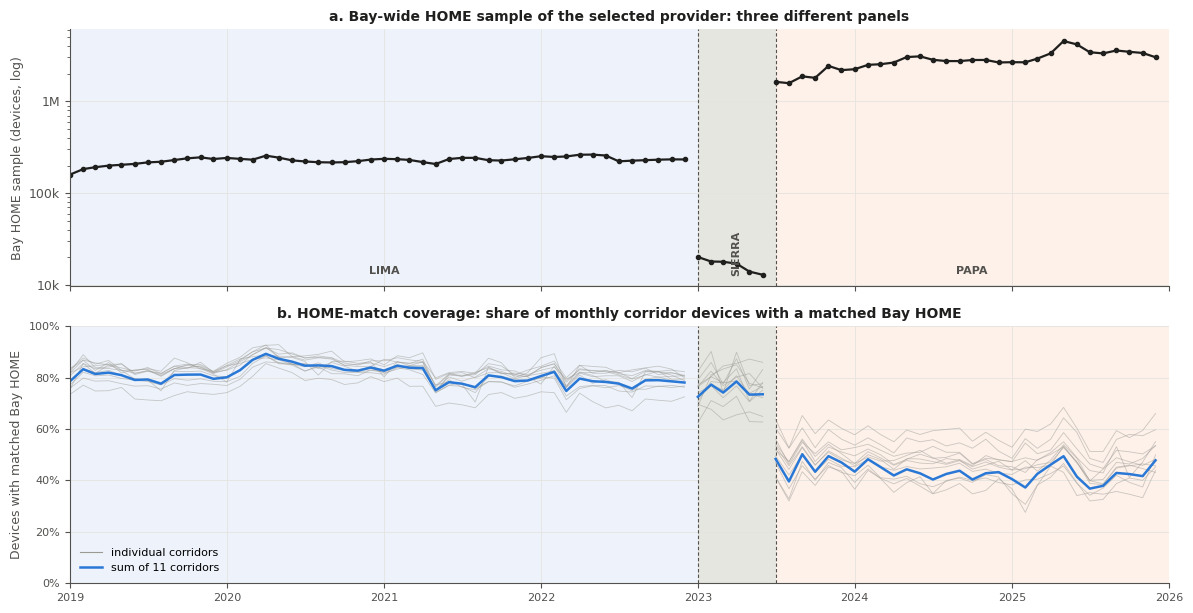

,months,median_bay_home_sample,median_monthly_devices,median_match_rate,min_match_rate,max_match_rate,median_common_scale_factor
provider_id,,,,,,,
LIMA,48,"231,486.50","35,914.50",0.81,0.75,0.89,0.91
SIERRA,6,"17,527.50","1,782.50",0.74,0.73,0.78,12.04
PAPA,30,"2,777,092.00","133,484.00",0.43,0.37,0.50,0.08


In [6]:
def shade_segments(ax, xlim=None):
    """Tint each provider segment and mark the breaks; segments are never joined by a line."""
    for _, s in SEGMENTS.iterrows():
        ax.axvspan(s['first'], s['end'], color=PROVIDER_TINT[s.provider_id], lw=0, zorder=0)
        if s['first'] > SEGMENTS['first'].min():
            ax.axvline(s['first'], color=INK_2, lw=0.8, ls=(0, (3, 2)), zorder=1)
    ax.set_xlim(xlim or (pd.Timestamp('2019-01-01'), pd.Timestamp('2026-01-01')))

def segment_lines(ax, df, y, x='date', **kw):
    """Plot y against date one provider segment at a time (no line across a provider break)."""
    label = kw.pop('label', None)
    for i, (_, g) in enumerate(df.groupby('provider_segment', sort=False)):
        ax.plot(g[x], g[y], label=label if i == 0 else None, **kw)

def year_axis(ax, step=1):
    ax.xaxis.set_major_locator(mdates.YearLocator(step)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')); ax.tick_params(labelsize=8)

def kfmt(ax, axis='y'):
    f = mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k' if abs(v) >= 1e4 else f'{v/1e3:.1f}k' if abs(v) >= 1e3 else f'{v:.0f}')
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)

def pct_change(a, b): return 100 * (b / a - 1)

city = act.groupby(['year_month', 'date', 'year', 'month', 'provider_id', 'provider_segment']).agg(
    visits=('visit_count', 'sum'), devices=('unique_devices', 'sum'), matched_devices=('home_matched_devices', 'sum'), matched_visits=('home_matched_visits', 'sum'),
    adj_visits=('adj_visits', 'sum'), adj_devices=('adj_devices', 'sum'), common_visits=('common_visits', 'sum')).reset_index().merge(
    denoms[['year_month', 'bay_home_sample', 'common_scale_factor', 'bay_sample_ratio']], on='year_month')
city['match_rate'] = city.matched_devices / city.devices
city['effective_weight'] = city.adj_visits / city.matched_visits

fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True)
for ax in axes: shade_segments(ax)
ax = axes[0]
segment_lines(ax, city, 'bay_home_sample', color=INK, lw=1.6, marker='o', ms=3)
ax.set_yscale('log'); ax.set_ylabel('Bay HOME sample (devices, log)'); ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M' if v >= 1e6 else f'{v/1e3:.0f}k'))
ax.set_title('a. Bay-wide HOME sample of the selected provider: three different panels')
for _, s in SEGMENTS.iterrows():
    mid = s['first'] + (s['end'] - s['first']) / 2
    ax.text(mid, 0.05, s.provider_id, transform=ax.get_xaxis_transform(), ha='center', fontsize=8, fontweight='bold', color=INK_2, rotation=90 if s.provider_id == 'SIERRA' else 0)
ax = axes[1]
for c in CORRIDORS: segment_lines(ax, act[act.corridor_name == c], 'home_match_rate', color=C_GRAY, lw=0.6, alpha=0.5)
segment_lines(ax, city, 'match_rate', color=C_BLUE, lw=1.8)
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1)); ax.set_ylabel('Devices with matched Bay HOME')
ax.plot([], [], color=C_GRAY, lw=0.8, label='individual corridors'); ax.plot([], [], color=C_BLUE, lw=1.8, label='sum of 11 corridors'); ax.legend(loc='lower left', fontsize=8)
ax.set_title('b. HOME-match coverage: share of monthly corridor devices with a matched Bay HOME'); year_axis(ax)
plt.tight_layout(); plt.show()

seg_tbl = city.groupby('provider_id').agg(months=('year_month', 'size'), median_bay_home_sample=('bay_home_sample', 'median'), median_monthly_devices=('devices', 'median'),
          median_match_rate=('match_rate', 'median'), min_match_rate=('match_rate', 'min'), max_match_rate=('match_rate', 'max'), median_common_scale_factor=('common_scale_factor', 'median')).reindex(PROVIDER_ORDER)
display(seg_tbl)

In [7]:
# A small numerical example of the two adjustments (one corridor-month in each of LIMA and PAPA)
ex = []
for corridor, ym in [('Lake Merritt', 201901), ('Lake Merritt', 202501)]:
    r = act[(act.corridor_name == corridor) & (act.year_month == ym)].iloc[0]
    ex.append({'corridor-month': f'{corridor} {ym}', 'provider': r.provider_id, 'all visits': r.visit_count, 'matched-HOME visits (unweighted)': r.home_matched_visits,
               'A: CBG-adjusted visits': r.adj_visits, 'average CBG weight (A ÷ matched)': r.adj_visits / r.home_matched_visits,
               'Bay HOME sample': r.bay_home_sample, 'common factor (2019 mean ÷ sample)': r.common_scale_factor, 'B: standardized visits (matched × factor)': r.common_visits})
display(pd.DataFrame(ex).set_index('corridor-month').T)
print(f'2019 mean Bay HOME sample = {mean_2019_sample:,.0f}. In LIMA, B ≈ A because the reference year is 2019 itself. In PAPA the Bay HOME panel is ~{city[city.provider_id=="PAPA"].bay_home_sample.median()/mean_2019_sample:.0f}× larger than the 2019 panel, '
      f'so B scales matched visits down by ~{1/city[city.provider_id=="PAPA"].common_scale_factor.median():.0f}×. A and B levels are on different scales and neither is comparable across providers.')

corridor-month,Lake Merritt 201901,Lake Merritt 202501
provider,LIMA,PAPA
all visits,14096,36637
matched-HOME visits (unweighted),11809,14986
A: CBG-adjusted visits,"15,429.08","13,253.58"
average CBG weight (A ÷ matched),1.31,0.88
Bay HOME sample,"159,257.00","2,664,045.00"
common factor (2019 mean ÷ sample),1.32,0.08
B: standardized visits (matched × factor),"15,645.79","1,186.94"


2019 mean Bay HOME sample = 211,000. In LIMA, B ≈ A because the reference year is 2019 itself. In PAPA the Bay HOME panel is ~13× larger than the 2019 panel, so B scales matched visits down by ~13×. A and B levels are on different scales and neither is comparable across providers.


**Takeaways: measurement context**
- **Three different panels.** The Bay HOME sample is ~0.23 M devices (LIMA, median), ~18 k (SIERRA) and ~2.8 M (PAPA, rising from 1.6 M to 4.5 M). Matched-HOME coverage of corridor device-months is ~81% in LIMA (75–89%), ~74% in SIERRA and ~43% in PAPA (37–50%). These are properties of the panels, not of corridor activity.
- **How the two adjustments differ (worked example, Lake Merritt).** In Jan 2019 (LIMA) 11,809 matched-HOME visits become 15,429 under A (average CBG weight 1.31) and 15,646 under B (factor 1.32): in LIMA the two nearly coincide because 2019 is the reference year. In Jan 2025 (PAPA) 14,986 matched visits become 13,254 under A (weight 0.88) but only 1,187 under B (factor 0.079), because the 2025 Bay HOME panel (2.66 M) is ~13× the 2019 panel while matched corridor devices rose only ~1.3× between Dec 2022 and Jul 2023 (33.9 k → 45.6 k, summed over corridors). **B therefore falls ~90% at the LIMA → PAPA boundary, and rises ~10× at the LIMA → SIERRA boundary: panel size and composition, not activity.** B is shown on a log axis to keep both segments legible and is used only to look at the shape of each segment; A drives every statistic.
- **What is and is not corrected.** Both adjustments remove overall panel *size* (A also corrects CBG composition within a provider). Neither corrects provider composition, HOME matching or recording frequency, which is why every statistic compares within LIMA or within PAPA, and why SIERRA, with ~1.8 k corridor devices a month in total, is shown but never interpreted.

**Takeaways: measurement context**
- **Three different panels.** The Bay HOME sample is ~0.23 M devices (LIMA, median), ~18 k (SIERRA) and ~2.8 M (PAPA, rising from 1.6 M to 4.5 M). Matched-HOME coverage of corridor device-months is ~81% in LIMA (75–89%), ~74% in SIERRA and ~43% in PAPA (37–50%). These are properties of the panels, not of corridor activity.
- **How the two adjustments differ (worked example, Lake Merritt).** In Jan 2019 (LIMA) 11,809 matched-HOME visits become 15,429 under A (average CBG weight 1.31) and 15,646 under B (factor 1.32): in LIMA the two nearly coincide because 2019 is the reference year. In Jan 2025 (PAPA) 14,986 matched visits become 13,254 under A (weight 0.88) but only 1,187 under B (factor 0.079), because the 2025 Bay HOME panel (2.66 M) is ~13× the 2019 panel while matched corridor devices rose only ~1.3× between Dec 2022 and Jul 2023 (33.9 k → 45.6 k, summed over corridors). **B therefore falls ~90% at the LIMA → PAPA boundary, and rises ~10× at the LIMA → SIERRA boundary: panel size and composition, not activity.** B is shown on a log axis to keep both segments legible and is used only to look at the shape of each segment; A drives every statistic.
- **What is and is not corrected.** Both adjustments remove overall panel *size* (A also corrects CBG composition within a provider). Neither corrects provider composition, HOME matching or recording frequency, which is why every statistic compares within LIMA or within PAPA, and why SIERRA, with ~1.8 k corridor devices a month in total, is shown but never interpreted.

## 2. Corridor overview, 2024 → 2025
All statistics from here on use **measure A** (CBG-adjusted activity among devices with a matched Bay HOME) unless stated. Levels are *average monthly* adjusted visits and *average monthly* adjusted unique devices (device-months ÷ 12), which keeps annual totals distinct from per-day intensity (section 6) and never sums devices into annual visitors. *Visits per device* is adjusted visits ÷ adjusted monthly devices. 2024 and 2025 are both fully inside PAPA, so the change is within one provider. Corridors differ in size, boundaries and land use: levels are not performance rankings, and no per-area or per-business measure is possible.

,adj visits / month 2024,adj visits / month 2025,visits Δ%,adj devices / month 2024,adj devices / month 2025,devices Δ%,visits per device 2024,visits per device 2025,visits per device Δ%,what changed
corridor_name,,,,,,,,,,
Lake Merritt,"11,905.00","13,281.00",11.60,"7,306.00","7,331.00",0.30,1.63,1.81,11.20,mostly more visits per device
Fruitvale,"12,711.00","13,236.00",4.10,"8,130.00","7,730.00",-4.90,1.56,1.71,9.50,mostly more visits per device
Downtown,"10,308.00","10,200.00",-1.10,"6,458.00","5,919.00",-8.40,1.60,1.72,8.00,visits flat: fewer devices offset by more visits per device
Chinatown,"8,407.00","9,491.00",12.90,"5,127.00","5,363.00",4.60,1.64,1.77,7.90,both: base and frequency move together
Temescal/Telegraph,"7,960.00","8,504.00",6.80,"5,221.00","5,054.00",-3.20,1.52,1.68,10.40,mostly more visits per device
Jack London,"7,141.00","7,338.00",2.80,"4,700.00","4,424.00",-5.90,1.52,1.66,9.20,visits flat: fewer devices offset by more visits per device
Koreatown/Northgate,"4,662.00","5,378.00",15.40,"3,134.00","3,260.00",4.00,1.49,1.65,10.90,mostly more visits per device
Rockridge,"2,706.00","2,784.00",2.90,"1,953.00","1,931.00",-1.10,1.39,1.44,4.00,little change in either
Laurel,"2,045.00","2,099.00",2.60,"1,444.00","1,414.00",-2.10,1.42,1.48,4.80,little change in either


Sum of the 11 corridors (overlaps not removed): adjusted visits/month 70,884 → 75,368 (+6.3%); adjusted devices/month 45,666 → 44,572 (-2.4%)


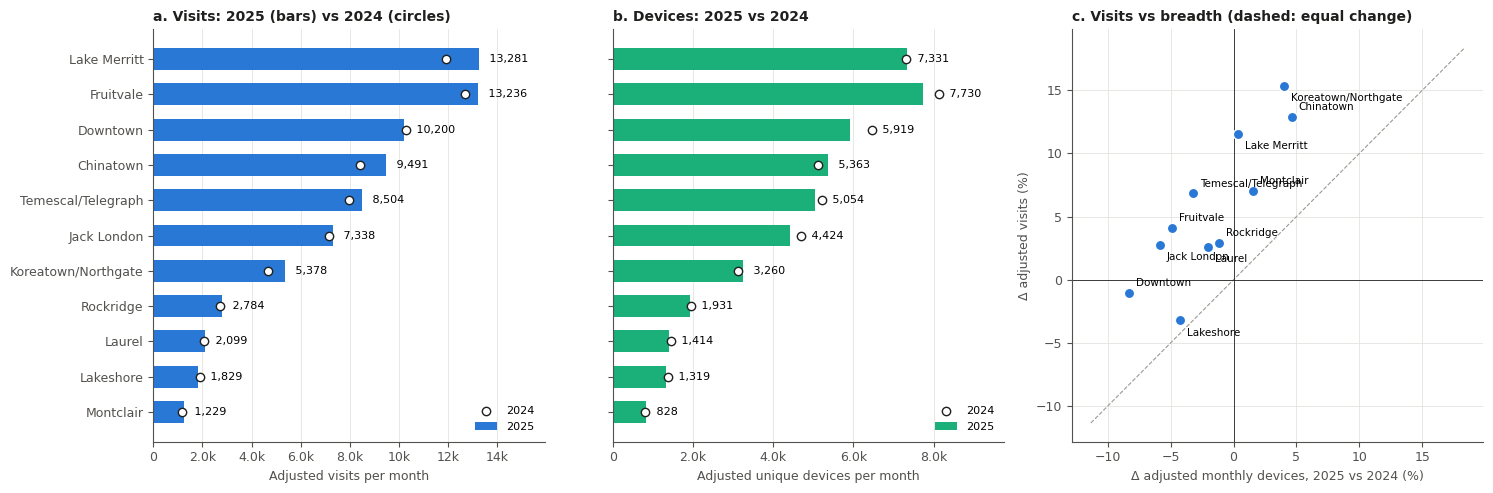

In [8]:
def window_mean(col, year, months=range(1, 13), df=None):
    """Average monthly value of a corridor measure over the given months of a year."""
    d = (act if df is None else df)
    d = d[(d.year == year) & d.month.isin(list(months))]
    return d.groupby('corridor_name')[col].sum().reindex(CORRIDORS) / len(list(months))

def breadth_label(v0, v1, d0, d1):
    """Decompose the visits change into change in devices and in visits per device (exact in logs)."""
    lv, ld = np.log(v1 / v0), np.log(d1 / d0)
    if abs(lv) < 0.04 and abs(ld) < 0.04: return 'little change in either'
    if abs(lv) < 0.04: return 'visits flat: fewer devices offset by more visits per device' if ld < 0 else 'visits flat: more devices offset by fewer visits per device'
    s = ld / lv; up = lv > 0
    if s >= 0.67: return 'mostly a broader base' if up else 'mostly a narrower base'
    if s <= 0.33: return 'mostly more visits per device' if up else 'mostly fewer visits per device'
    return 'both: base and frequency move together'

v24, v25 = window_mean('adj_visits', 2024), window_mean('adj_visits', 2025)
d24, d25 = window_mean('adj_devices', 2024), window_mean('adj_devices', 2025)
ov = pd.DataFrame({'adj visits / month 2024': v24, 'adj visits / month 2025': v25, 'visits Δ%': pct_change(v24, v25),
                   'adj devices / month 2024': d24, 'adj devices / month 2025': d25, 'devices Δ%': pct_change(d24, d25),
                   'visits per device 2024': v24 / d24, 'visits per device 2025': v25 / d25, 'visits per device Δ%': pct_change(v24 / d24, v25 / d25)})
ov['what changed'] = [breadth_label(v24[c], v25[c], d24[c], d25[c]) for c in CORRIDORS]
display(ov.round({'adj visits / month 2024': 0, 'adj visits / month 2025': 0, 'adj devices / month 2024': 0, 'adj devices / month 2025': 0, 'visits Δ%': 1, 'devices Δ%': 1,
                  'visits per device 2024': 2, 'visits per device 2025': 2, 'visits per device Δ%': 1}))
tot24, tot25 = v24.sum(), v25.sum(); td24, td25 = d24.sum(), d25.sum()
print(f'Sum of the 11 corridors (overlaps not removed): adjusted visits/month {tot24:,.0f} → {tot25:,.0f} ({pct_change(tot24, tot25):+.1f}%); adjusted devices/month {td24:,.0f} → {td25:,.0f} ({pct_change(td24, td25):+.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1.05]})
y = np.arange(len(CORRIDORS))[::-1]
for ax, a25, a24, lab, color in [(axes[0], v25, v24, 'Adjusted visits per month', C_BLUE), (axes[1], d25, d24, 'Adjusted unique devices per month', C_AQUA)]:
    ax.barh(y, a25, color=color, height=0.62, label='2025'); ax.scatter(a24, y, s=36, facecolor='white', edgecolor=INK, zorder=3, label='2024')
    for yi, v, w in zip(y, a25, a24): ax.text(max(v, w), yi, f'   {v:,.0f}', va='center', fontsize=8)
    ax.set_xlim(0, max(a25.max(), a24.max()) * 1.2); kfmt(ax, 'x'); ax.grid(axis='y', visible=False); ax.set_xlabel(lab); ax.legend(loc='lower right', fontsize=8)
axes[0].set_yticks(y); axes[0].set_yticklabels(CORRIDORS); axes[1].set_yticks(y); axes[1].set_yticklabels([])
axes[0].set_title('a. Visits: 2025 (bars) vs 2024 (circles)', loc='left'); axes[1].set_title('b. Devices: 2025 vs 2024', loc='left')
ax = axes[2]
ax.scatter(ov['devices Δ%'], ov['visits Δ%'], s=55, color=C_BLUE, edgecolor='white', zorder=3)
for k, c in enumerate(sorted(CORRIDORS, key=lambda c: ov.loc[c, 'devices Δ%'])):
    ax.annotate(c, (ov.loc[c, 'devices Δ%'], ov.loc[c, 'visits Δ%']), xytext=(5, 5 if k % 2 == 0 else -11), textcoords='offset points', fontsize=7.5)
lim = [min(ov[['visits Δ%', 'devices Δ%']].min()) - 3, max(ov[['visits Δ%', 'devices Δ%']].max()) + 3]
ax.plot(lim, lim, color=C_GRAY, lw=0.8, ls='--'); ax.axhline(0, color=INK, lw=0.6); ax.axvline(0, color=INK, lw=0.6)
ax.set_xlabel('Δ adjusted monthly devices, 2025 vs 2024 (%)'); ax.set_ylabel('Δ adjusted visits (%)'); ax.set_title('c. Visits vs breadth (dashed: equal change)', loc='left')
plt.tight_layout(); plt.show()

**Takeaways: corridor overview (adjusted, PAPA, 2024 → 2025)**
- **Levels.** Lake Merritt (13.3 k adjusted visits a month in 2025), Fruitvale (13.2 k) and Downtown (10.2 k) are the largest, followed by Chinatown (9.5 k), Temescal/Telegraph (8.5 k), Jack London (7.3 k) and Koreatown/Northgate (5.4 k); Rockridge, Laurel, Lakeshore and Montclair are 1.2–2.8 k. Lake Merritt and Fruitvale are effectively tied.
- **Visits changed more than the visitor base.** Summed over the 11 corridors, adjusted visits rose 6.3% (70.9 k → 75.4 k a month) while adjusted monthly devices **fell** 2.4% (45.7 k → 44.6 k). Visits rose in 9 corridors, from +2.6% (Laurel) to +15.4% (Koreatown/Northgate), and fell in Downtown (−1.1%) and Lakeshore (−3.2%). Devices fell in 7 corridors (−1.1% Rockridge to −8.4% Downtown) and rose only in Chinatown (+4.6%), Koreatown/Northgate (+4.0%), Montclair (+1.6%) and Lake Merritt (+0.3%).
- **Frequency rose everywhere**: visits per adjusted device went up in all 11 corridors (+1.1% Lakeshore to +11.2% Lake Merritt; e.g. Lake Merritt 1.63 → 1.81). Lake Merritt, Fruitvale, Temescal/Telegraph, Koreatown/Northgate and Montclair gained mostly through more visits per device; Chinatown through both; Downtown, Jack London and Lakeshore had flat visits with fewer devices offset by higher frequency. Section 7.2 shows that the visits-per-device rise coincides with a panel-wide step from April 2025, so the frequency part of this result is provisional.
- Corridors differ in size, boundaries and land use, so these levels are not performance rankings.

## 3. Trajectories and recovery
Each corridor's monthly series is drawn **one provider segment at a time**, with segments tinted and no line crossing a break. Thin lines with dots are monthly observations; thick lines are trailing three-month means computed *within* a segment. SIERRA (Jan–Jun 2023) is shown but rests on a tiny panel (about 1.8 k corridor devices a month across all corridors) and is not interpreted. Boundary jumps are never read as recovery or decline.

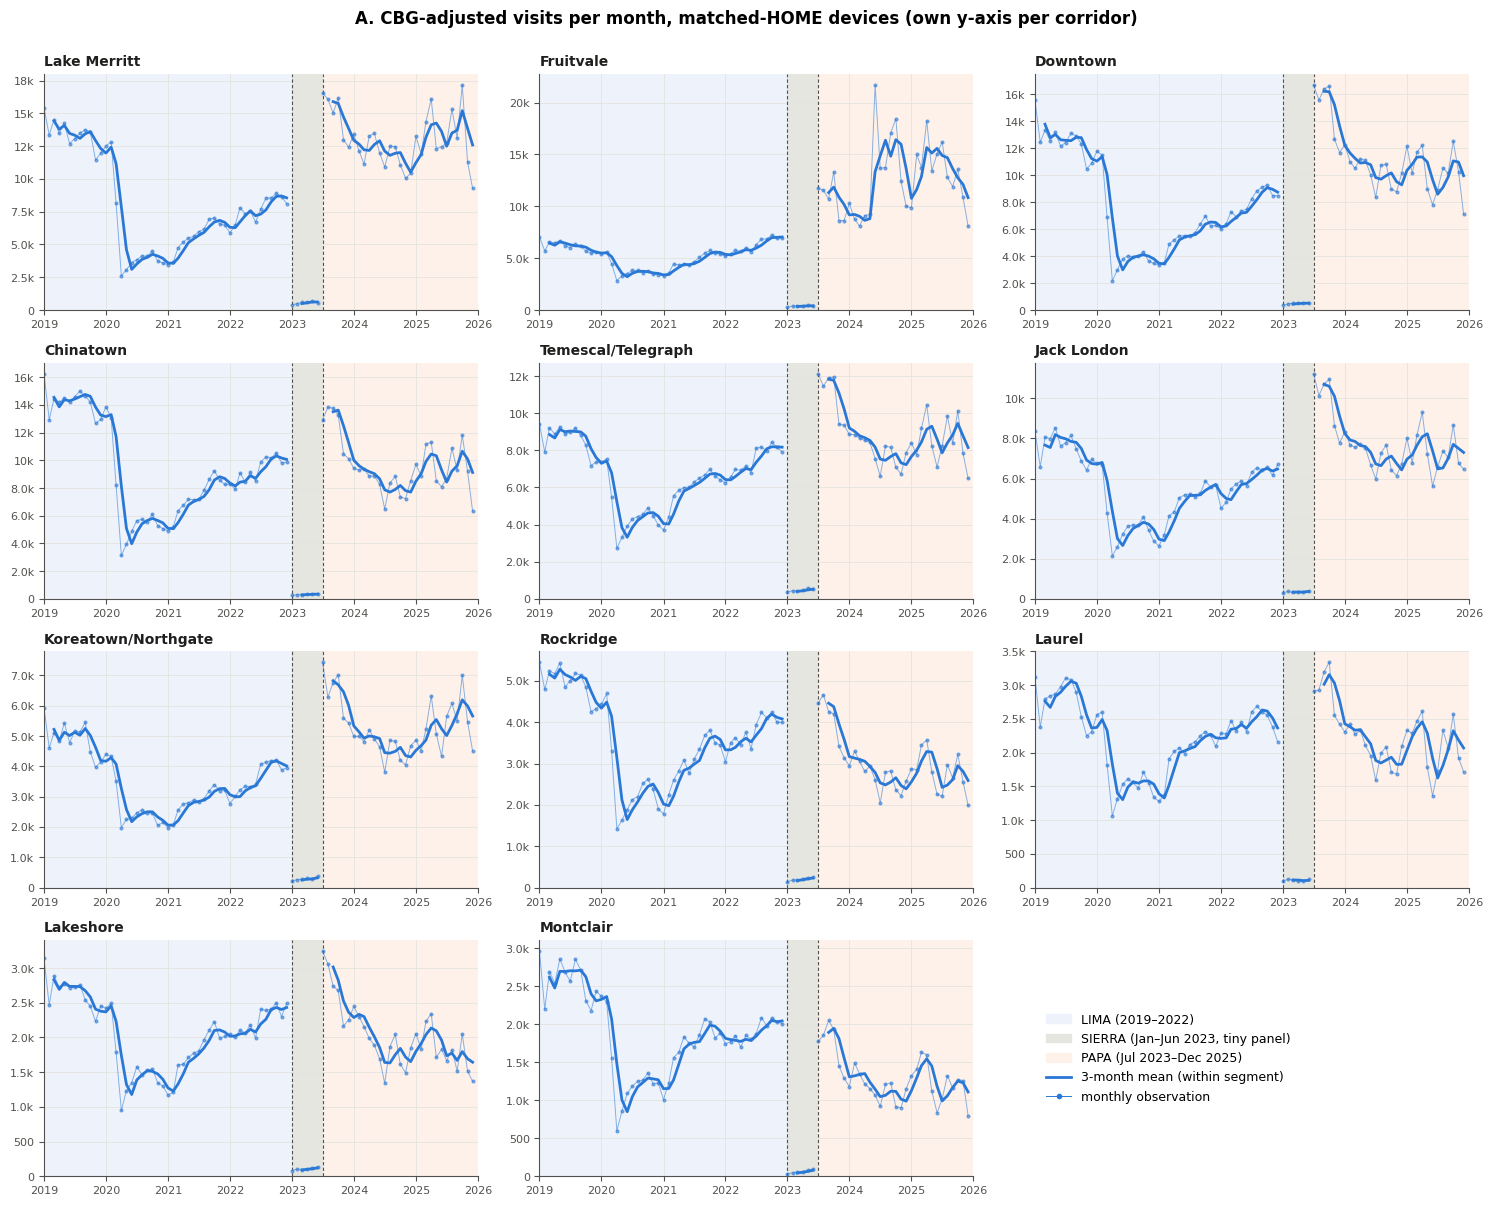

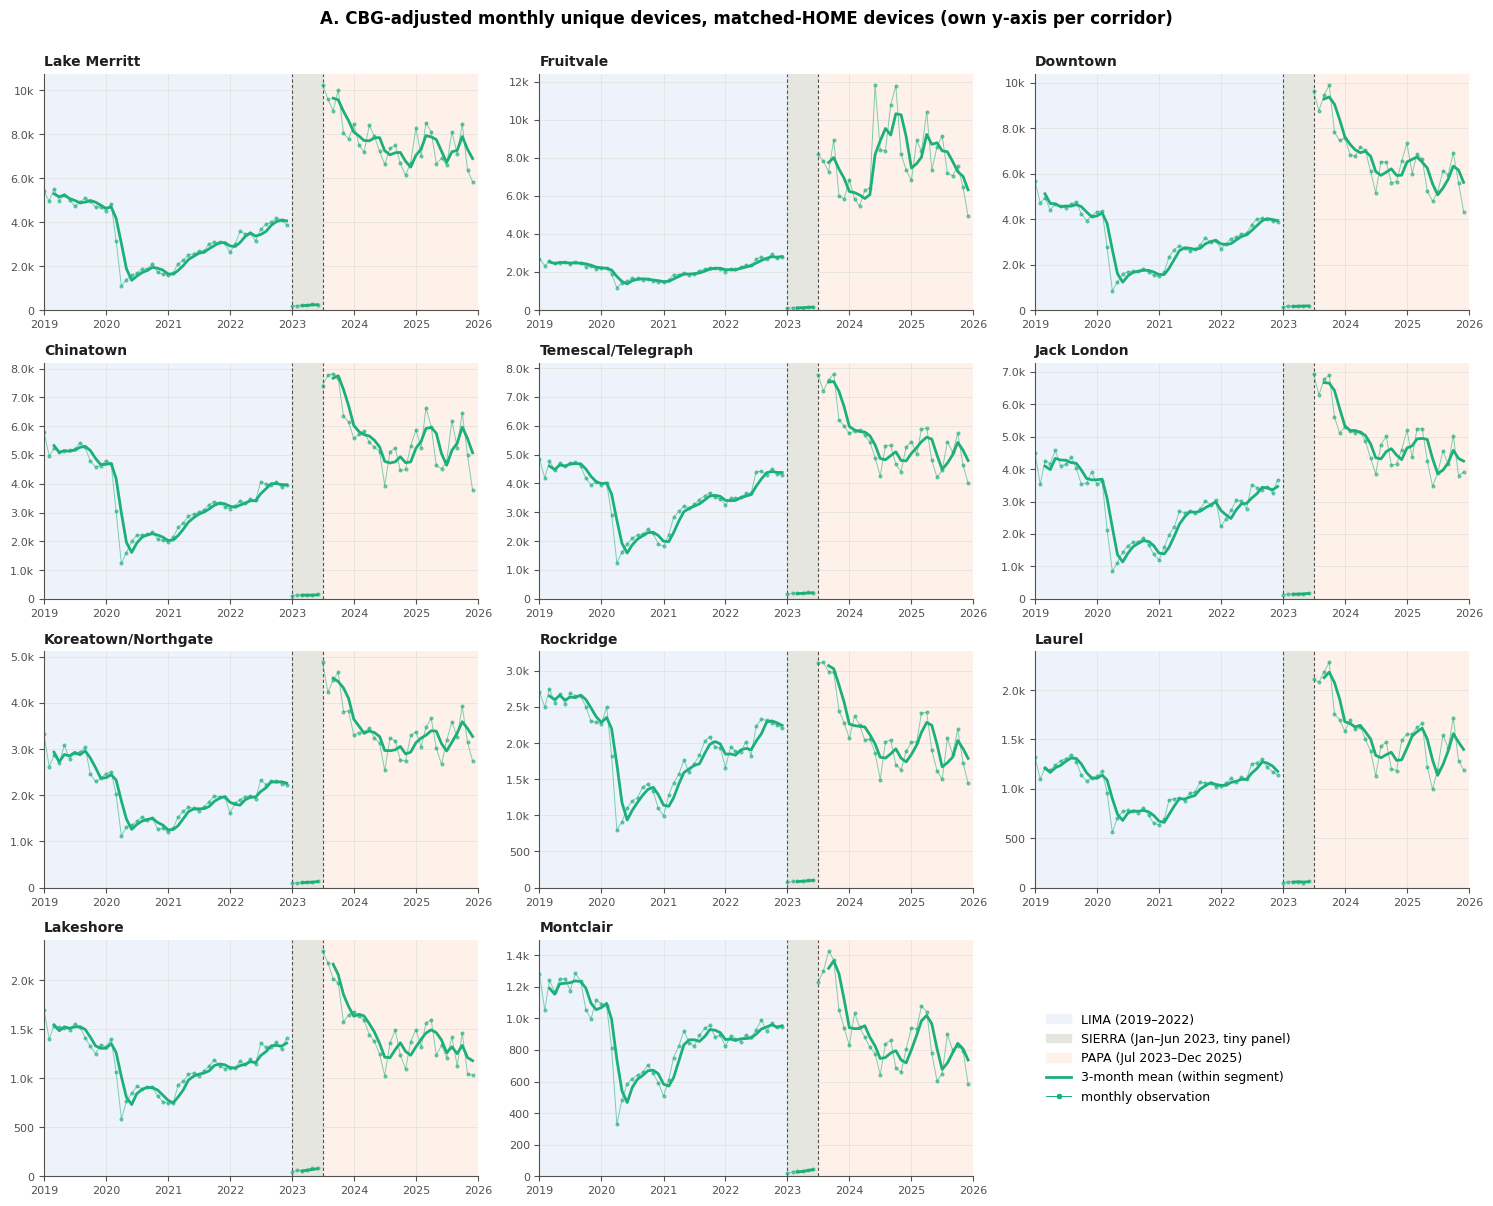

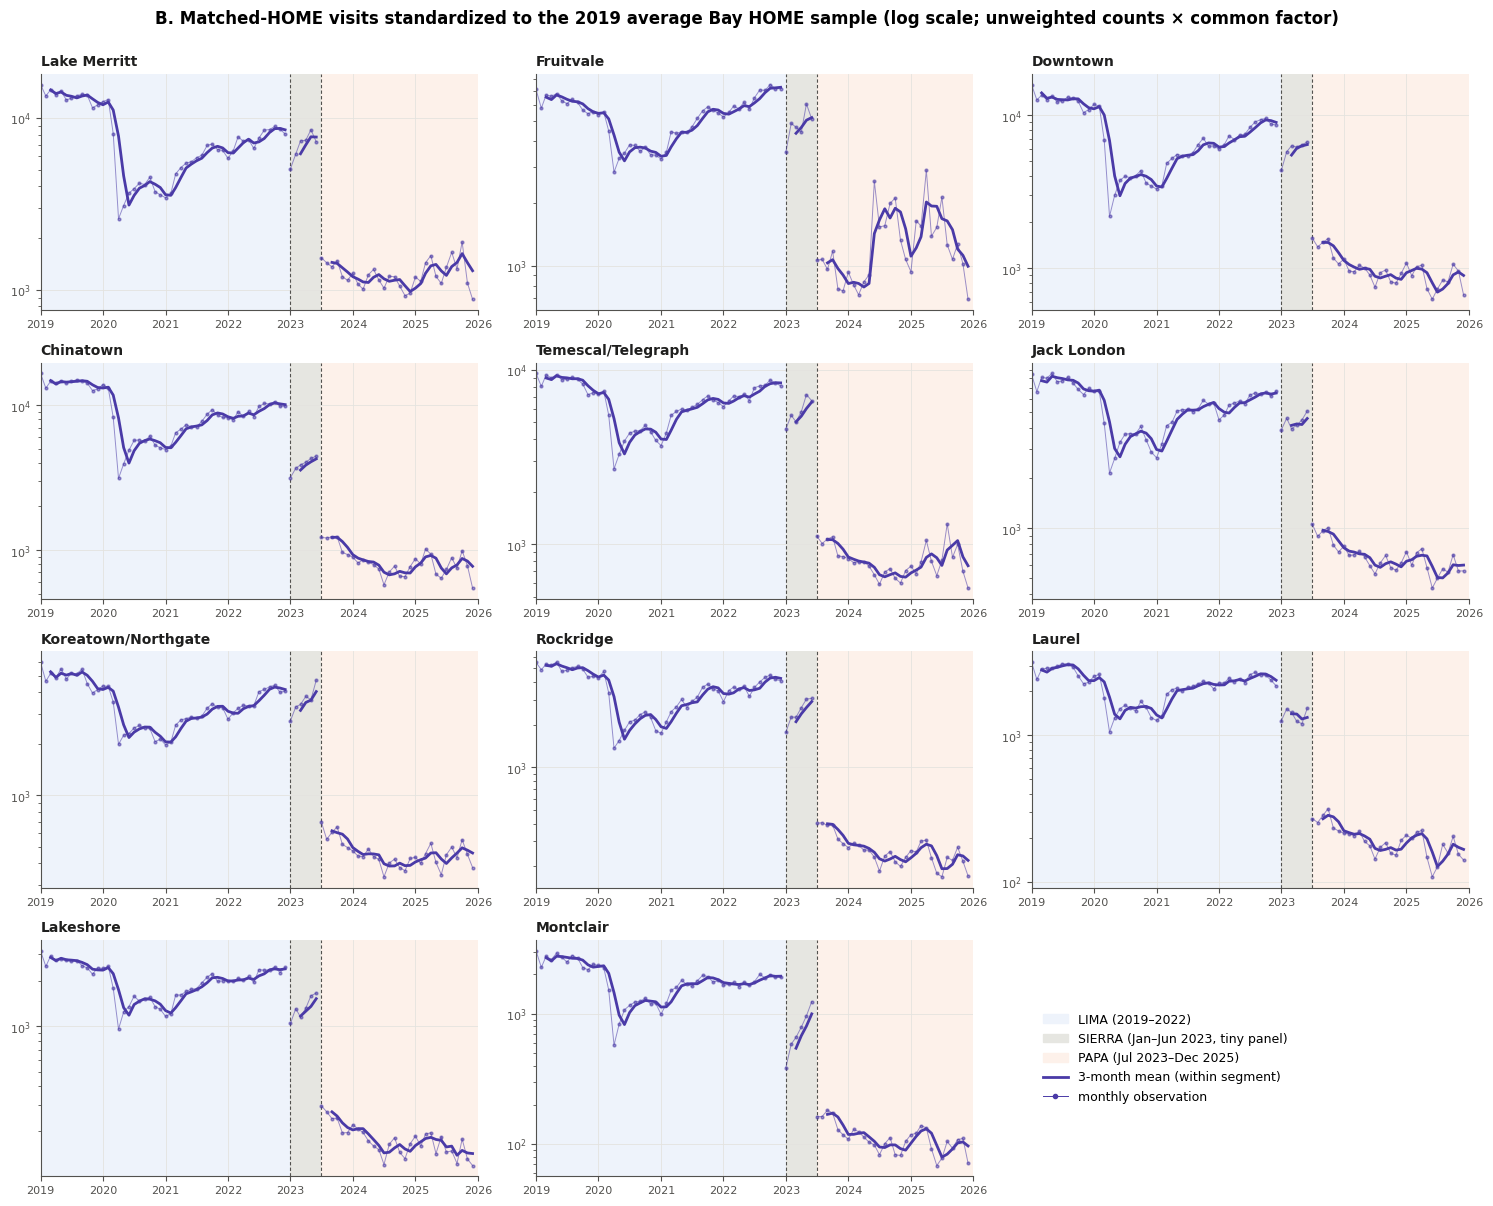

In [9]:
def ma3_within(df, col):
    """Trailing 3-month mean within corridor and provider segment (never across a break); needs 3 observations."""
    return df.sort_values('year_month').groupby(['corridor_name', 'provider_segment'])[col].transform(lambda s: s.rolling(3, min_periods=3).mean())
for col in ['adj_visits', 'adj_devices', 'common_visits']:
    act[col + '_ma3'] = ma3_within(act, col)

def small_multiples(draw, title, legend, figsize=(15, 12), sharey=False, xlim=None):
    fig, axes = plt.subplots(4, 3, figsize=figsize, sharey=sharey)
    for ax, c in zip(axes.flat, CORRIDORS):
        shade_segments(ax, xlim=xlim); draw(ax, c); ax.set_title(c, loc='left'); year_axis(ax)
    axes.flat[11].axis('off'); axes.flat[11].legend(handles=legend, loc='center left', fontsize=9)
    fig.suptitle(title, y=1.0, fontsize=12, fontweight='bold'); plt.tight_layout(); plt.show()

seg_legend = [Patch(color=PROVIDER_TINT['LIMA'], label='LIMA (2019–2022)'), Patch(color=PROVIDER_TINT['SIERRA'], label='SIERRA (Jan–Jun 2023, tiny panel)'), Patch(color=PROVIDER_TINT['PAPA'], label='PAPA (Jul 2023–Dec 2025)')]
def level_drawer(col, color, log=False):
    def draw(ax, c):
        g = act[act.corridor_name == c]
        segment_lines(ax, g, col, color=color, lw=0.7, alpha=0.55, marker='o', ms=2); segment_lines(ax, g, col + '_ma3', color=color, lw=2.0)
        if log: ax.set_yscale('log')
        else: ax.set_ylim(bottom=0); kfmt(ax)
    return draw
def line_legend(color, lab): return seg_legend + [Line2D([], [], color=color, lw=2, label='3-month mean (within segment)'), Line2D([], [], color=color, lw=0.7, marker='o', ms=3, label='monthly observation')]

small_multiples(level_drawer('adj_visits', C_BLUE), 'A. CBG-adjusted visits per month, matched-HOME devices (own y-axis per corridor)', line_legend(C_BLUE, ''))
small_multiples(level_drawer('adj_devices', C_AQUA), 'A. CBG-adjusted monthly unique devices, matched-HOME devices (own y-axis per corridor)', line_legend(C_AQUA, ''))
small_multiples(level_drawer('common_visits', C_VIOLET, log=True), 'B. Matched-HOME visits standardized to the 2019 average Bay HOME sample (log scale; unweighted counts × common factor)', line_legend(C_VIOLET, ''))

**Reading the monthly series.** (i) In both adjusted measures every corridor collapses in spring 2020 and then rebuilds steadily through 2022; only the depth and speed differ. (ii) PAPA adjusted levels start high (Jul–Oct 2023) and step down from November 2023 in every corridor: the weights are above 1.3 in those months because the PAPA reference window spans a near-doubling of the Bay HOME sample (section 7.5), so they are not read as activity. (iii) Measure B puts PAPA about ten times below LIMA and SIERRA about ten times above it, in every corridor at the same boundaries: these are the panel jumps described in section 1, and no trend is drawn across them. Within LIMA, A and B are almost identical in shape. (iv) Fruitvale's PAPA series carries large month-to-month swings in B (the unweighted matched visits), muted in A.

### 3.1 Indexed view of the full timeline
For orientation, each corridor's adjusted visits and adjusted monthly devices are indexed **within** each provider: **LIMA = 2019 monthly mean = 100; PAPA = 2024 monthly mean = 100**; SIERRA is not indexed. The two index bases are different panels, so the vertical position of the two segments cannot be compared; only the shape within each can.

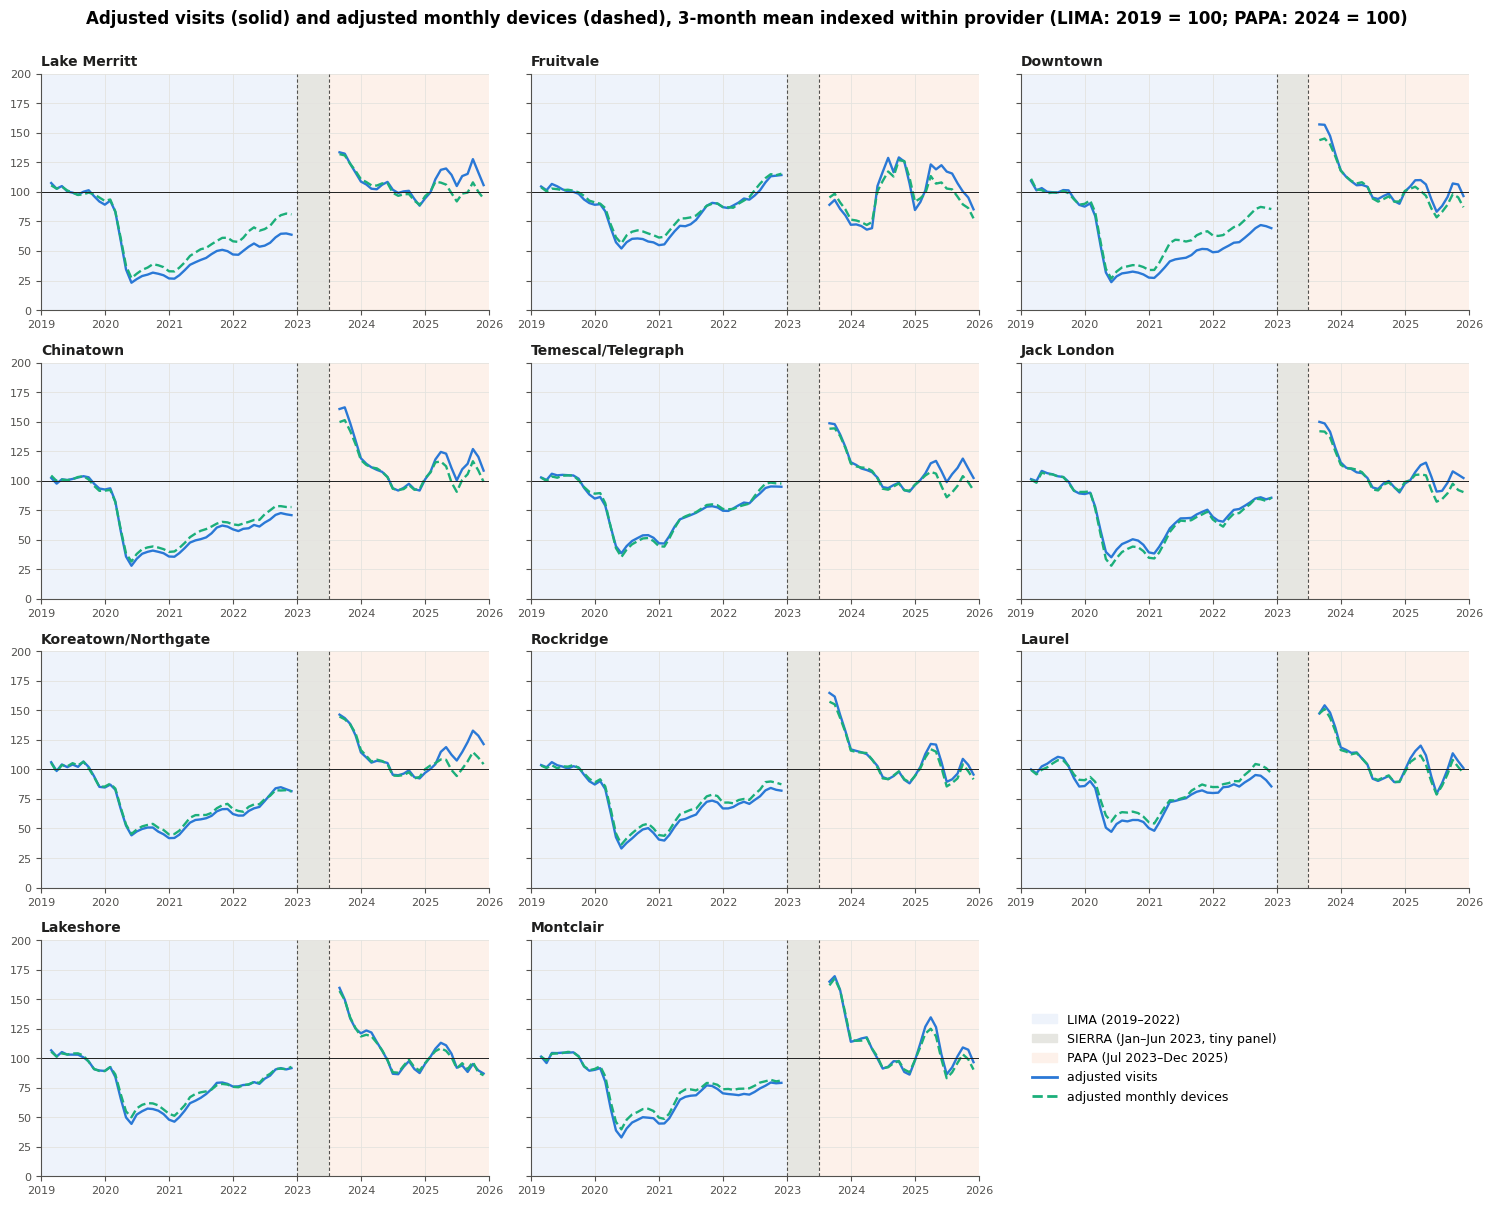

In [10]:
def index_within(prov, base_year, col):
    d = act[act.provider_id == prov].copy()
    base = d[d.year == base_year].groupby('corridor_name')[col].mean()
    d['idx'] = 100 * d[col] / d.corridor_name.map(base)
    d['idx_ma3'] = d.sort_values('year_month').groupby('corridor_name').idx.transform(lambda s: s.rolling(3, min_periods=3).mean())
    return d
idx = {(prov, col): index_within(prov, by, col) for prov, by in [('LIMA', BASE_YEAR), ('PAPA', COMPARISON_YEAR)] for col in ['adj_visits', 'adj_devices']}
def index_drawer(ax, c):
    for (prov, col), color, ls in [(('LIMA', 'adj_visits'), C_BLUE, '-'), (('PAPA', 'adj_visits'), C_BLUE, '-'), (('LIMA', 'adj_devices'), C_AQUA, '--'), (('PAPA', 'adj_devices'), C_AQUA, '--')]:
        g = idx[(prov, col)]; g = g[g.corridor_name == c]; ax.plot(g.date, g.idx_ma3, color=color, lw=1.7, ls=ls)
    ax.axhline(100, color=INK, lw=0.7); ax.set_ylim(0, 200)
small_multiples(index_drawer, 'Adjusted visits (solid) and adjusted monthly devices (dashed), 3-month mean indexed within provider (LIMA: 2019 = 100; PAPA: 2024 = 100)',
                seg_legend + [Line2D([], [], color=C_BLUE, lw=2, label='adjusted visits'), Line2D([], [], color=C_AQUA, lw=2, ls='--', label='adjusted monthly devices')], sharey=True)

**Indexed view.** In LIMA the visits and devices indices follow the same collapse and recovery, but in the slow corridors **devices recover better than visits**: by 2022, Lake Merritt sits at 0.72 of 2019 devices against 0.57 of visits, and Downtown at 0.77 against 0.62 (section 3.4 quantifies this). In PAPA the first months sit 35–70% above the 2024 mean in most corridors (the weight artefact above) and then settle near 100; in 2025 visits (solid) rise above devices (dashed) in most corridors, peaking near 110–135.

### 3.2 LIMA (2019–2022): the 2020 decline and the recovery
Comparisons use the **same calendar month of 2019** (so seasonality cancels) and annual monthly means. *Recovery* is the first month after the 2020 trough in which the trailing three-month mean of the ratio reaches **90%** of the matching 2019 months, computed separately for **visits** and for **monthly unique devices** so that recovery in how often people came is distinguished from recovery in how many came. A single strong month does not count: the three-month mean must reach the threshold. All within LIMA, on adjusted measures.

adjusted visits, annual ÷ 2019           adjusted devices, annual ÷ 2019                 visits                       devices                  Q4 2022 ÷ Q4 2019        
year                                          2020 2021 2022                            2020 2021 2022 trough ratio   recovery month trough ratio   recovery month            visits devices
corridor_name                                                                                                                                                                               
Fruitvale                                     0.63 0.76 1.01                            0.68 0.80 1.02         0.44         Oct 2021         0.48         Nov 2021              1.26    1.25
Laurel                                        0.61 0.72 0.88                            0.67 0.76 0.95         0.37         Dec 2021         0.47         Nov 2021              1.00    1.06
Temescal/Telegraph                            0.55 0.69 0.86                            0.53 0.69 0.88         0.31         Oct 2022         0.28         Sep 2022              1.08    1.08
Lakeshore                                     0.60 0.67 0.84                            0.64 0.69 0.85         0.35         Oct 2022         0.38         Oct 2022              1.02    1.04
Jack London                                   0.52 0.63 0.78                            0.47 0.60 0.76         0.27         Nov 2022         0.20         Nov 2022              0.96    0.94
Rockridge                                     0.52 0.61 0.76                            0.55 0.66 0.81         0.27         Dec 2022         0.31         Nov 2022              0.91    0.95
Koreatown/Northgate                           0.56 0.57 0.74                            0.58 0.61 0.75         0.41         Dec 2022         0.42         Dec 2022              0.96    0.95
Montclair                                     0.52 0.66 0.74                            0.59 0.70 0.77         0.23  not by Dec 2022         0.28         Dec 2022              0.89    0.91
Chinatown                                     0.47 0.51 0.66                            0.50 0.56 0.72         0.22  not by Dec 2022         0.24  not by Dec 2022              0.76    0.85
Downtown                                      0.41 0.43 0.62                            0.46 0.56 0.77         0.17  not by Dec 2022         0.19         Nov 2022              0.78    0.96
Lake Merritt                                  0.41 0.42 0.57                            0.46 0.50 0.72         0.19  not by Dec 2022         0.22  not by Dec 2022              0.70    0.85

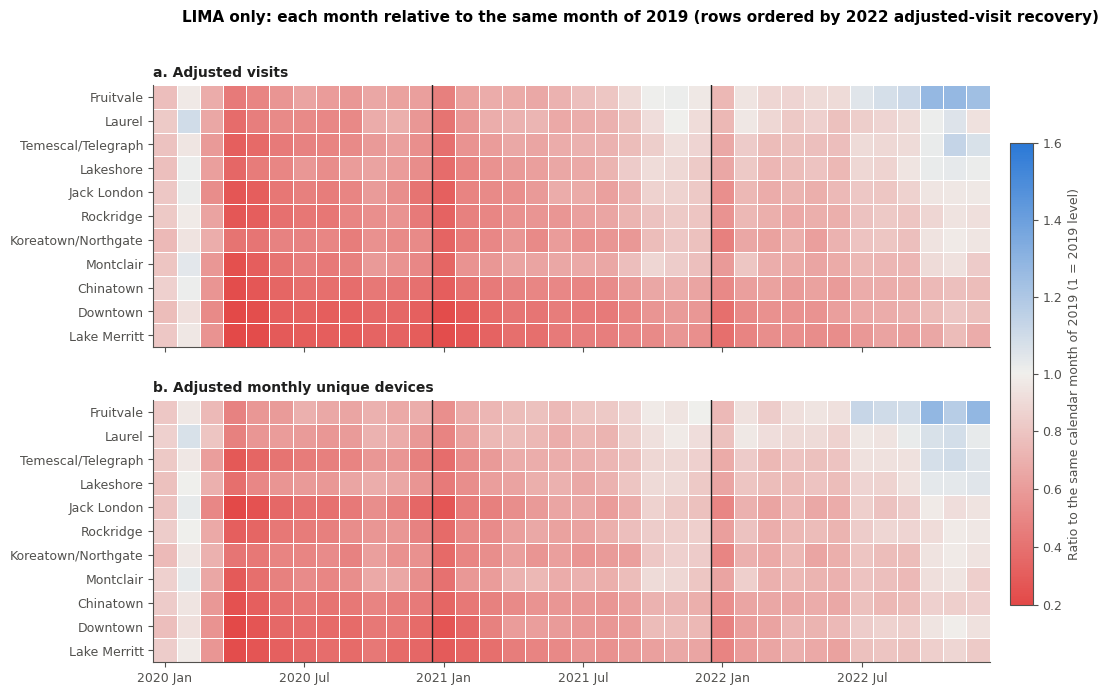

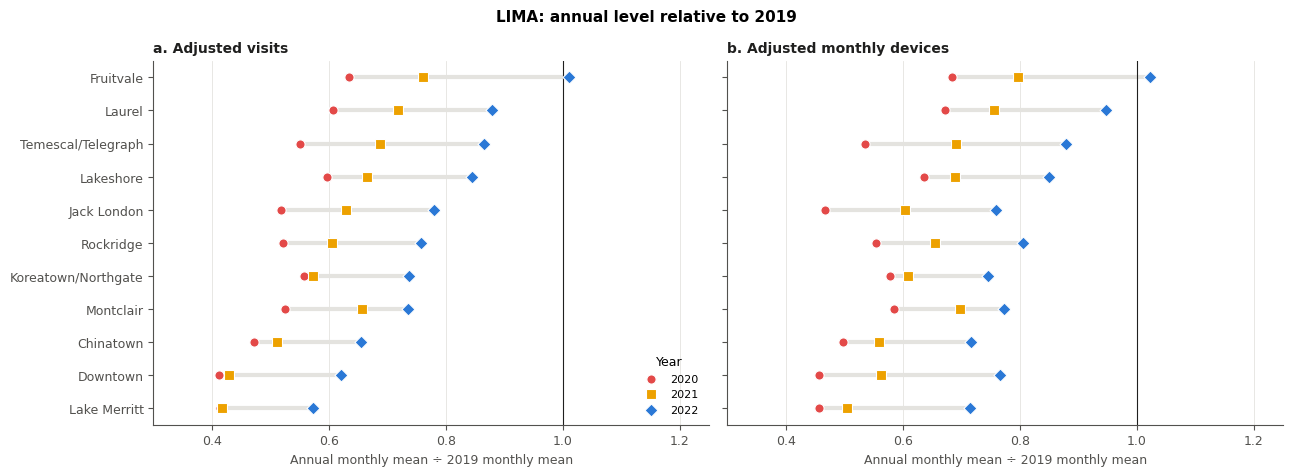

In [11]:
lima = act[act.provider_id == 'LIMA']
def lima_stats(col):
    p = lima.pivot_table(index=['corridor_name', 'month'], columns='year', values=col)
    sm = {y: (p[y] / p[BASE_YEAR]).unstack('month') for y in [2020, 2021, 2022]}
    long = pd.concat({y: sm[y].stack() for y in sm}, names=['year', 'corridor_name', 'month']).rename('ratio').reset_index()
    long['year_month'] = long.year * 100 + long.month
    long = long.sort_values(['corridor_name', 'year_month']); long['ratio3'] = long.groupby('corridor_name').ratio.transform(lambda s: s.rolling(3, min_periods=3).mean())
    ann = lima.groupby(['corridor_name', 'year'])[col].mean().unstack(); ann = ann[[2020, 2021, 2022]].div(ann[BASE_YEAR], axis=0)
    res = {}
    for c, g in long.groupby('corridor_name'):
        g20 = g[g.year == 2020]; tr = g20.loc[g20.ratio.idxmin()]
        hit = g[(g.year_month >= tr.year_month) & (g.ratio3 >= RECOVERY_THRESHOLD)]
        res[c] = {'trough ratio': tr.ratio, 'trough month': pd.to_datetime(str(int(tr.year_month)), format='%Y%m').strftime('%b %Y'),
                  'recovery month': pd.to_datetime(str(int(hit.year_month.iloc[0])), format='%Y%m').strftime('%b %Y') if len(hit) else 'not by Dec 2022',
                  'Q4 2022 ÷ Q4 2019': g[(g.year == 2022) & g.month.isin([10, 11, 12])].ratio.mean()}
    return sm, ann.reindex(CORRIDORS), pd.DataFrame(res).T.reindex(CORRIDORS)
L = {'visits': lima_stats('adj_visits'), 'devices': lima_stats('adj_devices')}
for k in L:
    L[k][2]['trough ratio'] = L[k][2]['trough ratio'].astype(float); L[k][2]['Q4 2022 ÷ Q4 2019'] = L[k][2]['Q4 2022 ÷ Q4 2019'].astype(float)
lima_tbl = pd.concat({'adjusted visits, annual ÷ 2019': L['visits'][1].rename(columns=str), 'adjusted devices, annual ÷ 2019': L['devices'][1].rename(columns=str)}, axis=1)
lima_tbl[('visits', 'trough ratio')] = L['visits'][2]['trough ratio']; lima_tbl[('visits', 'recovery month')] = L['visits'][2]['recovery month']
lima_tbl[('devices', 'trough ratio')] = L['devices'][2]['trough ratio']; lima_tbl[('devices', 'recovery month')] = L['devices'][2]['recovery month']
lima_tbl[('Q4 2022 ÷ Q4 2019', 'visits')] = L['visits'][2]['Q4 2022 ÷ Q4 2019']; lima_tbl[('Q4 2022 ÷ Q4 2019', 'devices')] = L['devices'][2]['Q4 2022 ÷ Q4 2019']
display(lima_tbl.round(2).sort_values(('adjusted visits, annual ÷ 2019', '2022'), ascending=False))

order_l = L['visits'][1].sort_values(2022, ascending=False).index.tolist()
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True); norm = TwoSlopeNorm(vcenter=1.0, vmin=0.2, vmax=1.6)
for ax, key, ttl in [(axes[0], 'visits', 'a. Adjusted visits'), (axes[1], 'devices', 'b. Adjusted monthly unique devices')]:
    sm = L[key][0]; mat = np.hstack([sm[y].reindex(order_l).to_numpy() for y in [2020, 2021, 2022]])
    mesh = ax.pcolormesh(np.arange(37), np.arange(len(order_l) + 1), mat, cmap=DIVERGING, norm=norm, edgecolors='white', linewidth=0.5)
    ax.set_yticks(np.arange(len(order_l)) + 0.5); ax.set_yticklabels(order_l); ax.invert_yaxis(); ax.grid(False); ax.set_title(ttl, loc='left')
    for x in (12, 24): ax.axvline(x, color=INK, lw=1)
axes[1].set_xticks(np.arange(0, 36, 6) + 0.5); axes[1].set_xticklabels([f'{y} {m}' for y in [2020, 2021, 2022] for m in ['Jan', 'Jul']])
cb = fig.colorbar(mesh, ax=axes, shrink=0.8, pad=0.02); cb.set_label('Ratio to the same calendar month of 2019 (1 = 2019 level)')
fig.suptitle('LIMA only: each month relative to the same month of 2019 (rows ordered by 2022 adjusted-visit recovery)', fontsize=11, fontweight='bold', y=0.98); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, key, ttl in [(axes[0], 'visits', 'a. Adjusted visits'), (axes[1], 'devices', 'b. Adjusted monthly devices')]:
    ratio = L[key][1]; y = np.arange(len(order_l))[::-1]
    ax.hlines(y, ratio.loc[order_l].min(axis=1), ratio.loc[order_l].max(axis=1), color=GRID, lw=3, zorder=1)
    for yr, col, mk in [(2020, C_RED, 'o'), (2021, C_YELLOW, 's'), (2022, C_BLUE, 'D')]:
        ax.scatter(ratio.loc[order_l, yr], y, s=44, color=col, marker=mk, zorder=3, label=str(yr), edgecolor='white', lw=0.8)
    ax.axvline(1, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order_l); ax.set_title(ttl, loc='left'); ax.set_xlabel('Annual monthly mean ÷ 2019 monthly mean'); ax.set_xlim(0.3, 1.25); ax.grid(axis='y', visible=False)
axes[0].legend(loc='lower right', title='Year', fontsize=8); fig.suptitle('LIMA: annual level relative to 2019', fontsize=11, fontweight='bold'); plt.tight_layout(); plt.show()

**Takeaways: LIMA decline and recovery (adjusted)**
- **The 2020 decline was severe everywhere.** The worst month stood at only 17% (Downtown) to 44% (Fruitvale) of the same month of 2019 for visits, and 19–48% for devices. The 2020 annual level was 41–63% of 2019 for visits and 46–68% for devices.
- **By 2022 only Fruitvale was back at its 2019 level** (visits 1.01, devices 1.02). Laurel (0.88 / 0.95), Temescal/Telegraph (0.86 / 0.88) and Lakeshore (0.84 / 0.85) were close; Jack London (0.78 / 0.76), Rockridge (0.76 / 0.81), Koreatown/Northgate (0.74 / 0.75) and Montclair (0.74 / 0.77) were roughly three-quarters recovered; **Chinatown (0.66 / 0.72), Downtown (0.62 / 0.77) and Lake Merritt (0.57 / 0.72) lagged most**.
- **Timing of recovery (trailing three-month mean ≥ 90% of the same months of 2019).** Visits: Fruitvale Oct 2021, Laurel Dec 2021, then Temescal/Telegraph and Lakeshore Oct 2022, Jack London Nov 2022, Rockridge and Koreatown/Northgate Dec 2022; **not reached by Dec 2022 in Montclair, Chinatown, Downtown and Lake Merritt**. Devices recover earlier or equally: Fruitvale and Laurel in Nov 2021, Temescal/Telegraph Sep 2022, Lakeshore Oct 2022, Jack London, Rockridge and Downtown in Nov 2022, Montclair and Koreatown/Northgate in Dec 2022; only Chinatown and Lake Merritt had not recovered devices by Dec 2022.
- **Visits and devices tell different stories in the central corridors.** Downtown's devices were back to 96% of Q4 2019 while its visits were at 78%; Lake Merritt 85% vs 70%. The visitor base came back faster than the frequency of visits (section 3.4).
- These are adjusted measures; section 7.5 shows that the LIMA ordering is identical under the common-scale measure B (ρ = 1.00), so the weights and the Bay-wide fallback do not drive this ranking.

### 3.3 PAPA (Jul 2023–Dec 2025): 2025 versus 2024
Both full years sit inside one provider. Each corridor is compared **full-year** and **January–November in both years** (December 2025 is unusually weak; section 7), with a **leave-one-month-out** range for adjusted visits so that no single month decides the result, and the count of same-month comparisons in which 2025 exceeds 2024. Jul–Oct 2023 is not used: the PAPA weight reference spans a near-doubling of the sample, which inflates weights in the first months (section 7).

,"visits Δ%, full year","visits Δ%, Jan–Nov",visits: leave-one-month-out range,visits: months up (of 12),"devices Δ%, full year","devices Δ%, Jan–Nov",devices: months up (of 12)
Lake Merritt,11.60,13.30,+7.9 to +13.7,8,0.30,1.40,4
Fruitvale,4.10,5.80,-2.0 to +9.9,5,-4.90,-2.60,5
Downtown,-1.10,1.50,-4.2 to +1.5,5,-8.40,-6.00,3
Chinatown,12.90,16.50,+9.1 to +16.5,8,4.60,7.80,8
Temescal/Telegraph,6.80,9.00,+3.9 to +9.0,7,-3.20,-1.30,6
Jack London,2.80,3.30,+0.1 to +4.3,6,-5.90,-5.10,4
Koreatown/Northgate,15.40,17.10,+11.2 to +17.8,8,4.00,6.00,8
Rockridge,2.90,5.10,+0.3 to +5.1,6,-1.10,0.80,6
Laurel,2.60,4.50,-0.9 to +5.5,7,-2.10,-0.40,6
Lakeshore,-3.20,-1.20,-5.5 to -1.0,6,-4.30,-2.40,5


visits: corridors with 2025 above same month of 2024, by month Jan–Dec: 3 1 11 11 2 2 11 8 4 10 10 0 | sum of corridors, % change by month: -2 +2 +21 +30 -1 -15 +19 +11 -7 +28 +12 -18
devices: corridors with 2025 above same month of 2024, by month Jan–Dec: 3 1 10 9 1 1 10 8 2 10 7 0 | sum of corridors, % change by month: -1 -3 +12 +11 -11 -17 +7 +2 -13 +12 -1 -24


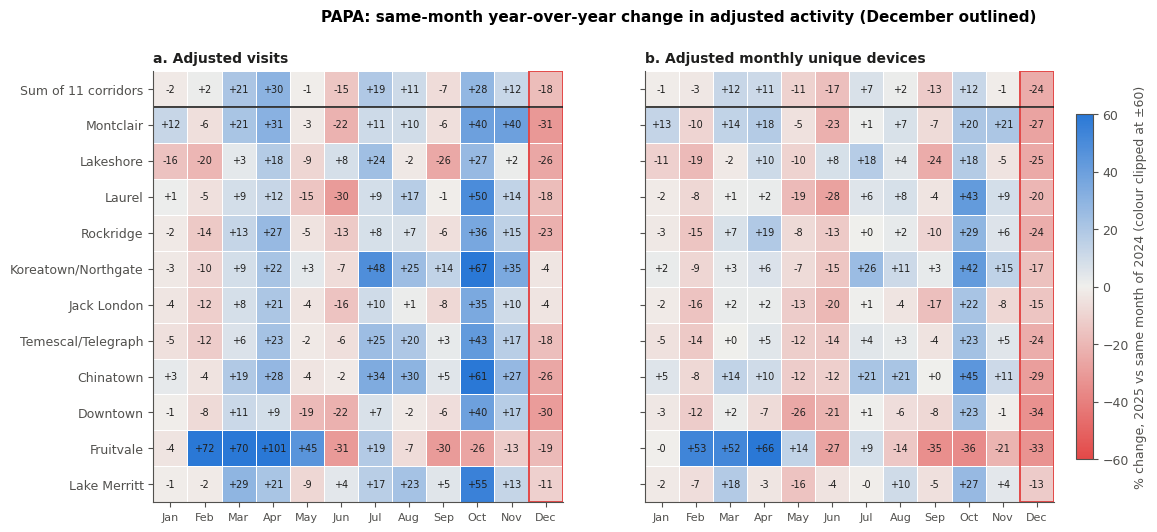

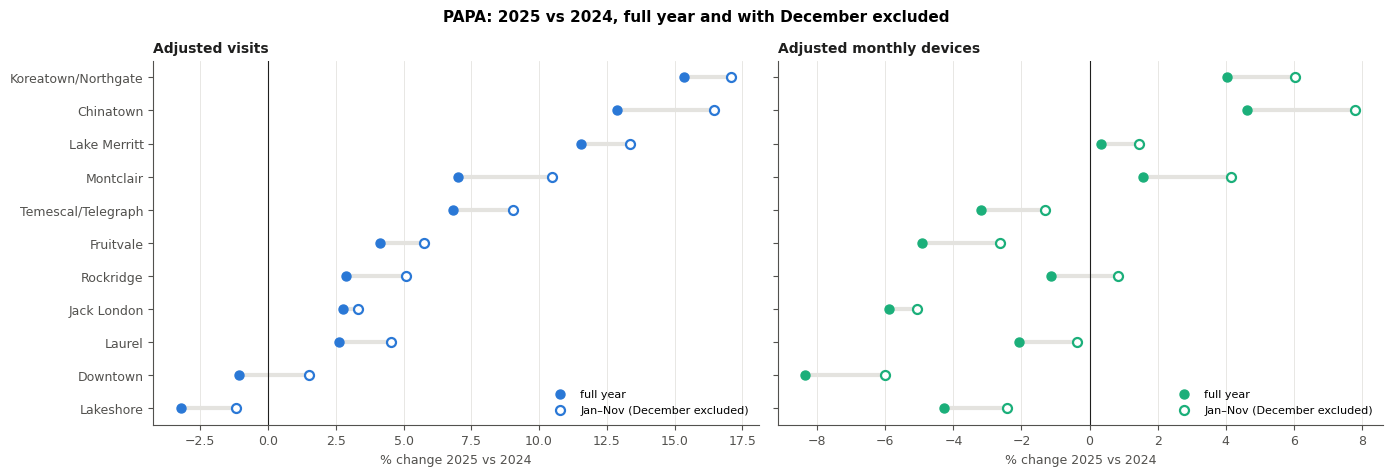

In [12]:
papa = act[act.provider_id == 'PAPA']
def yoy(col, months, y0=COMPARISON_YEAR, y1=FOCUS_YEAR, df=None):
    d = papa if df is None else df
    s = d[d.month.isin(months)].groupby(['corridor_name', 'year'])[col].sum().unstack()
    return pct_change(s[y0], s[y1]).reindex(CORRIDORS)
def monthly_yoy(col):
    p = papa[papa.year.isin([2024, 2025])].pivot_table(index='corridor_name', columns=['year', 'month'], values=col)
    out = pd.DataFrame({m: pct_change(p[(2024, m)], p[(2025, m)]) for m in range(1, 13)}).reindex(CORRIDORS)
    s = papa[papa.year.isin([2024, 2025])].groupby(['year', 'month'])[col].sum()
    out.loc['Sum of 11 corridors'] = [pct_change(s[(2024, m)], s[(2025, m)]) for m in range(1, 13)]
    return out
def leave_one_out(col):
    s = papa[papa.year.isin([2024, 2025])].pivot_table(index='corridor_name', columns=['year', 'month'], values=col); out = {}
    for c in CORRIDORS:
        v = [pct_change(s.loc[c, 2024].drop(m).sum(), s.loc[c, 2025].drop(m).sum()) for m in range(1, 13)]; out[c] = (min(v), max(v))
    return out
SM = {'visits': monthly_yoy('adj_visits'), 'devices': monthly_yoy('adj_devices')}
LOO = leave_one_out('adj_visits')
papa_tbl = pd.DataFrame({
    'visits Δ%, full year': yoy('adj_visits', range(1, 13)), 'visits Δ%, Jan–Nov': yoy('adj_visits', JAN_NOV),
    'visits: leave-one-month-out range': [f'{LOO[c][0]:+.1f} to {LOO[c][1]:+.1f}' for c in CORRIDORS], 'visits: months up (of 12)': (SM['visits'].loc[CORRIDORS] > 0).sum(axis=1),
    'devices Δ%, full year': yoy('adj_devices', range(1, 13)), 'devices Δ%, Jan–Nov': yoy('adj_devices', JAN_NOV), 'devices: months up (of 12)': (SM['devices'].loc[CORRIDORS] > 0).sum(axis=1)}, index=CORRIDORS)
display(papa_tbl.round(1))
for k in ('visits', 'devices'):
    s_ = SM[k]; print(f'{k}: corridors with 2025 above same month of 2024, by month Jan–Dec:', ' '.join(str(int(x)) for x in (s_.loc[CORRIDORS] > 0).sum()), '| sum of corridors, % change by month:', ' '.join(f'{x:+.0f}' for x in s_.loc['Sum of 11 corridors']))

order_p = papa_tbl['visits Δ%, full year'].sort_values(ascending=False).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True); norm = TwoSlopeNorm(vcenter=0, vmin=-60, vmax=60); rows_ = CORRIDORS + ['Sum of 11 corridors']
for ax, key, ttl in [(axes[0], 'visits', 'a. Adjusted visits'), (axes[1], 'devices', 'b. Adjusted monthly unique devices')]:
    mat = SM[key].loc[rows_].to_numpy(); mesh = ax.pcolormesh(np.arange(13), np.arange(len(rows_) + 1), mat, cmap=DIVERGING, norm=norm, edgecolors='white', linewidth=0.6)
    for i in range(mat.shape[0]):
        for j in range(12): ax.text(j + 0.5, i + 0.5, f'{mat[i, j]:+.0f}', ha='center', va='center', fontsize=7, color=INK)
    ax.set_xticks(np.arange(12) + 0.5); ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize=8)
    ax.set_yticks(np.arange(len(rows_)) + 0.5); ax.set_yticklabels(rows_); ax.invert_yaxis(); ax.grid(False); ax.set_title(ttl, loc='left')
    ax.axhline(len(CORRIDORS), color=INK, lw=1.2); ax.add_patch(plt.Rectangle((11, 0), 1, len(rows_), fill=False, ec=C_RED, lw=1.4))
cb = fig.colorbar(mesh, ax=axes, shrink=0.8, pad=0.02); cb.set_label('% change, 2025 vs same month of 2024 (colour clipped at ±60)')
fig.suptitle('PAPA: same-month year-over-year change in adjusted activity (December outlined)', fontsize=11, fontweight='bold', y=0.99); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True); y = np.arange(len(order_p))[::-1]
for ax, (col, ttl) in zip(axes, [('visits', 'Adjusted visits'), ('devices', 'Adjusted monthly devices')]):
    a, b = papa_tbl[f'{col} Δ%, full year'].loc[order_p], papa_tbl[f'{col} Δ%, Jan–Nov'].loc[order_p]
    ax.hlines(y, a, b, color=GRID, lw=3, zorder=1); ax.scatter(a, y, s=42, color=C_BLUE if col == 'visits' else C_AQUA, zorder=3, label='full year'); ax.scatter(b, y, s=42, facecolor='white', edgecolor=C_BLUE if col == 'visits' else C_AQUA, lw=1.6, zorder=3, label='Jan–Nov (December excluded)')
    ax.axvline(0, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order_p); ax.grid(axis='y', visible=False); ax.set_title(ttl, loc='left'); ax.set_xlabel('% change 2025 vs 2024'); ax.legend(loc='lower right', fontsize=8)
fig.suptitle('PAPA: 2025 vs 2024, full year and with December excluded', fontsize=11, fontweight='bold'); plt.tight_layout(); plt.show()

**Takeaways: PAPA 2025 vs 2024 (adjusted)**
- **Visits.** Koreatown/Northgate +15.4% (Jan–Nov +17.1%), Chinatown +12.9% (+16.5%) and Lake Merritt +11.6% (+13.3%) gained: positive in every leave-one-month-out test and in 8 of 12 same-month comparisons. Montclair (+7.0%) and Temescal/Telegraph (+6.8%) gained modestly (positive in every leave-one-out test). Jack London (+2.8%), Rockridge (+2.9%), Laurel (+2.6%) and Downtown (−1.1%) are roughly stable. Lakeshore (−3.2%) is slightly weaker, negative in every leave-one-out test. **Fruitvale (+4.1%) is unclear**: its leave-one-out range is −2.0% to +9.9% and only 5 of 12 months are up.
- **Devices (breadth).** Adjusted monthly devices rose only in Chinatown (+4.6%), Koreatown/Northgate (+4.0%), Montclair (+1.6%) and Lake Merritt (+0.3%), and fell in the other seven (−1.1% Rockridge to −8.4% Downtown).
- **The window does not change the picture.** Excluding December raises every visits change by 0.6–3.6 points and every devices change by 0.8–3.2; only Downtown's visits (−1.1% → +1.5%) and Rockridge's devices (−1.1% → +0.8%) change sign.
- **Gains arrive in bursts, not steadily.** Summed over corridors, visits are above the same month of 2024 in March (+21%), April (+30%), July (+19%), October (+28%) and November (+12%), with 10–11 of the 11 corridors up in those months, but below it in June (−15%), September (−7%) and December (−18%, all 11 corridors down); January, February and May are flat. A corridor's annual gain is therefore built from a few strong months, one reason for the leave-one-out and January–November checks.

### 3.4 More visits, a broader visitor base, or both?
Adjusted visits equal adjusted monthly devices times visits per device, so a change in visits splits exactly into a change in the **breadth of the visitor base** (devices) and a change in **frequency** (visits per device-month). "Breadth" here means more distinct observed devices in a month, not more distinct people.

LIMA, 2022 vs 2019 (ratios; 1.00 = 2019 level)


,visits 2022 ÷ 2019,devices 2022 ÷ 2019,visits per device 2022 ÷ 2019,what drove it
corridor_name,,,,
Lake Merritt,0.57,0.72,0.80,both: base and frequency move together
Downtown,0.62,0.77,0.81,both: base and frequency move together
Chinatown,0.66,0.72,0.92,mostly a narrower base
Koreatown/Northgate,0.74,0.75,0.99,mostly a narrower base
Montclair,0.74,0.77,0.95,mostly a narrower base
Rockridge,0.76,0.81,0.94,mostly a narrower base
Jack London,0.78,0.76,1.03,mostly a narrower base
Lakeshore,0.84,0.85,0.99,mostly a narrower base
Temescal/Telegraph,0.86,0.88,0.98,mostly a narrower base


PAPA, 2025 vs 2024 (% change)


,visits Δ%,devices Δ%,visits per device Δ%,what drove it
corridor_name,,,,
Lake Merritt,11.60,0.30,11.20,mostly more visits per device
Fruitvale,4.10,-4.90,9.50,mostly more visits per device
Downtown,-1.10,-8.40,8.00,visits flat: fewer devices offset by more visits per device
Chinatown,12.90,4.60,7.90,both: base and frequency move together
Temescal/Telegraph,6.80,-3.20,10.40,mostly more visits per device
Jack London,2.80,-5.90,9.20,visits flat: fewer devices offset by more visits per device
Koreatown/Northgate,15.40,4.00,10.90,mostly more visits per device
Rockridge,2.90,-1.10,4.00,little change in either
Laurel,2.60,-2.10,4.80,little change in either


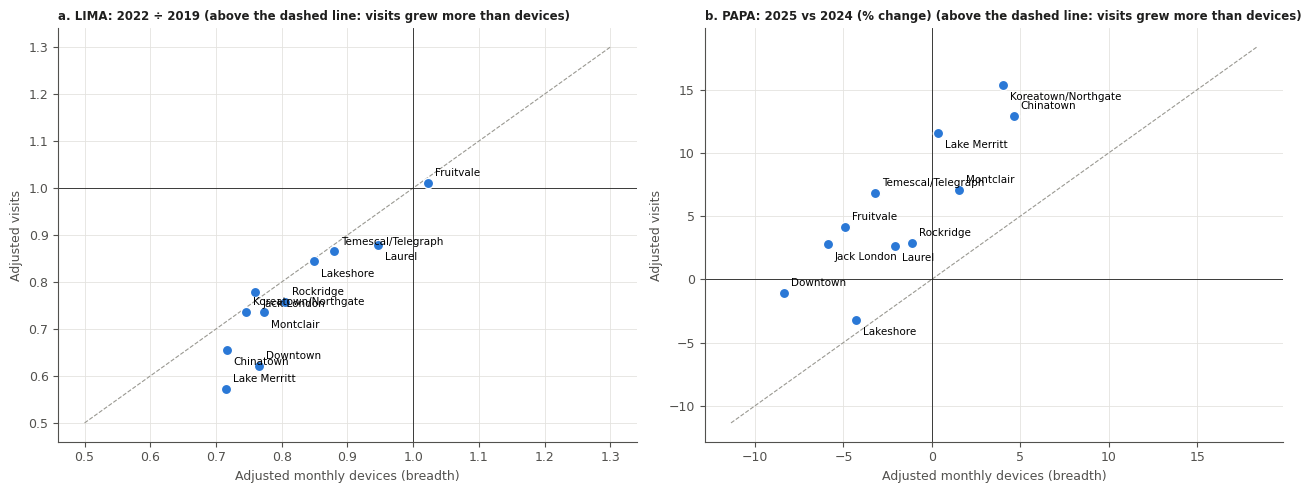

In [13]:
la = lima.groupby(['corridor_name', 'year'])[['adj_visits', 'adj_devices']].mean().unstack()
lima_b = pd.DataFrame({'visits 2022 ÷ 2019': la[('adj_visits', 2022)] / la[('adj_visits', 2019)], 'devices 2022 ÷ 2019': la[('adj_devices', 2022)] / la[('adj_devices', 2019)]}).reindex(CORRIDORS)
lima_b['visits per device 2022 ÷ 2019'] = lima_b.iloc[:, 0] / lima_b.iloc[:, 1]
lima_b['what drove it'] = [breadth_label(1, lima_b.iloc[i, 0], 1, lima_b.iloc[i, 1]) for i in range(len(lima_b))]
papa_b = ov[['visits Δ%', 'devices Δ%', 'visits per device Δ%', 'what changed']].rename(columns={'what changed': 'what drove it'})
print('LIMA, 2022 vs 2019 (ratios; 1.00 = 2019 level)'); display(lima_b.round(2).sort_values('visits 2022 ÷ 2019'))
print('PAPA, 2025 vs 2024 (% change)'); display(papa_b.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (xs, ys, ttl, lim) in zip(axes, [(lima_b['devices 2022 ÷ 2019'], lima_b['visits 2022 ÷ 2019'], 'a. LIMA: 2022 ÷ 2019', (0.5, 1.3)), (papa_b['devices Δ%'], papa_b['visits Δ%'], 'b. PAPA: 2025 vs 2024 (% change)', None)]):
    ax.scatter(xs, ys, s=55, color=C_BLUE, edgecolor='white', zorder=3)
    for k, c in enumerate(xs.sort_values().index): ax.annotate(c, (xs[c], ys[c]), xytext=(5, 5 if k % 2 == 0 else -11), textcoords='offset points', fontsize=7.5)
    lm = lim or [min(xs.min(), ys.min()) - 3, max(xs.max(), ys.max()) + 3]; ax.plot(lm, lm, color=C_GRAY, lw=0.8, ls='--')
    if lim is None: ax.axhline(0, color=INK, lw=0.6); ax.axvline(0, color=INK, lw=0.6)
    else: ax.axhline(1, color=INK, lw=0.6); ax.axvline(1, color=INK, lw=0.6)
    ax.set_xlabel('Adjusted monthly devices (breadth)'); ax.set_ylabel('Adjusted visits'); ax.set_title(ttl + ' (above the dashed line: visits grew more than devices)', loc='left', fontsize=8.5)
plt.tight_layout(); plt.show()

**Takeaways: more visits, a broader base, or both?**
- **LIMA decline and recovery.** In eight corridors visits and devices moved together (visits per device within 0.93–1.03 of 2019). The exceptions are the central corridors: **Lake Merritt (devices 0.72, visits per device 0.80) and Downtown (0.77, 0.81) lost both breadth and frequency**, and Chinatown mostly breadth (0.72 devices, frequency 0.92). Fruitvale recovered both (1.02, 0.99).
- **PAPA 2025.** The gains were mostly **more visits per device, not a broader visitor base**: in Lake Merritt visits rose 11.6% with devices +0.3% (frequency +11.2%); in Koreatown/Northgate visits +15.4% with devices +4.0%; in Temescal/Telegraph +6.8% with devices −3.2%. Only Chinatown (visits +12.9%, devices +4.6%) combined both. Downtown, Jack London and Lakeshore had flat visits with fewer devices.
- **Caution.** Frequency rose in all 11 corridors from April 2025 onwards in a way that looks panel-wide (section 7.2), so the *breadth* result (devices flat to down) is the more reliable half of this finding and the *frequency* gain the more provisional.

### 3.5 Trajectory summary
Descriptive labels from simple rules on adjusted measures (cut-offs are in the configuration cell); not clusters and not a composite score.

In [14]:
def lima_type(r):
    return 'recovered (≥ 95% of 2019)' if r >= RECOVERED else 'mostly recovered (75–95%)' if r >= PARTIAL else 'well below 2019 (< 75%)'
def papa_type(c):
    full, jn = papa_tbl.loc[c, 'visits Δ%, full year'], papa_tbl.loc[c, 'visits Δ%, Jan–Nov']; lo, hi = LOO[c]
    if full < 0 and jn < 0 and hi < 0: return 'weakened slightly'
    if lo < 0 < hi and abs(full) >= STABLE_PCT: return 'unclear (depends on one or two months)'
    if full >= GROWTH_PCT and jn >= GROWTH_PCT and lo > 0: return 'gained'
    if full >= STABLE_PCT and lo > 0: return 'modest gain'
    return 'stable'
traj = pd.DataFrame({'LIMA: visits 2022 ÷ 2019': L['visits'][1][2022], 'LIMA: devices 2022 ÷ 2019': L['devices'][1][2022],
                     'LIMA recovery month (visits / devices)': [f"{L['visits'][2].loc[c, 'recovery month']} / {L['devices'][2].loc[c, 'recovery month']}" for c in CORRIDORS],
                     'PAPA: visits Δ%': papa_tbl['visits Δ%, full year'], 'PAPA: devices Δ%': papa_tbl['devices Δ%, full year']}).reindex(CORRIDORS)
traj['LIMA type'] = [lima_type(traj.loc[c, 'LIMA: visits 2022 ÷ 2019']) for c in CORRIDORS]
traj['PAPA type (visits)'] = [papa_type(c) for c in CORRIDORS]
traj['PAPA: what drove the change'] = ov['what changed']
display(traj.round(2))
for col in ['LIMA type', 'PAPA type (visits)']: print(col + ':', traj.groupby(col).apply(lambda d: list(d.index)).to_dict())

,LIMA: visits 2022 ÷ 2019,LIMA: devices 2022 ÷ 2019,LIMA recovery month (visits / devices),PAPA: visits Δ%,PAPA: devices Δ%,LIMA type,PAPA type (visits),PAPA: what drove the change
Lake Merritt,0.57,0.72,not by Dec 2022 / not by Dec 2022,11.56,0.34,well below 2019 (< 75%),gained,mostly more visits per device
Fruitvale,1.01,1.02,Oct 2021 / Nov 2021,4.13,-4.92,recovered (≥ 95% of 2019),unclear (depends on one or two months),mostly more visits per device
Downtown,0.62,0.77,not by Dec 2022 / Nov 2022,-1.05,-8.36,well below 2019 (< 75%),stable,visits flat: fewer devices offset by more visits per device
Chinatown,0.66,0.72,not by Dec 2022 / not by Dec 2022,12.89,4.61,well below 2019 (< 75%),gained,both: base and frequency move together
Temescal/Telegraph,0.86,0.88,Oct 2022 / Sep 2022,6.83,-3.19,mostly recovered (75–95%),modest gain,mostly more visits per device
Jack London,0.78,0.76,Nov 2022 / Nov 2022,2.76,-5.88,mostly recovered (75–95%),stable,visits flat: fewer devices offset by more visits per device
Koreatown/Northgate,0.74,0.75,Dec 2022 / Dec 2022,15.35,4.03,well below 2019 (< 75%),gained,mostly more visits per device
Rockridge,0.76,0.81,Dec 2022 / Nov 2022,2.88,-1.12,mostly recovered (75–95%),stable,little change in either
Laurel,0.88,0.95,Dec 2021 / Nov 2021,2.62,-2.07,mostly recovered (75–95%),stable,little change in either
Lakeshore,0.84,0.85,Oct 2022 / Oct 2022,-3.22,-4.28,mostly recovered (75–95%),weakened slightly,visits flat: fewer devices offset by more visits per device


LIMA type: {'mostly recovered (75–95%)': ['Temescal/Telegraph', 'Jack London', 'Rockridge', 'Laurel', 'Lakeshore'], 'recovered (≥ 95% of 2019)': ['Fruitvale'], 'well below 2019 (< 75%)': ['Lake Merritt', 'Downtown', 'Chinatown', 'Koreatown/Northgate', 'Montclair']}
PAPA type (visits): {'gained': ['Lake Merritt', 'Chinatown', 'Koreatown/Northgate'], 'modest gain': ['Temescal/Telegraph', 'Montclair'], 'stable': ['Downtown', 'Jack London', 'Rockridge', 'Laurel'], 'unclear (depends on one or two months)': ['Fruitvale'], 'weakened slightly': ['Lakeshore']}


**Takeaways: trajectory types (descriptive).**
- **LIMA:** *recovered* (≥ 95%): Fruitvale; *mostly recovered* (75–95%): Temescal/Telegraph, Jack London, Rockridge, Laurel, Lakeshore; *well below 2019* (< 75%): Lake Merritt, Downtown, Chinatown, Koreatown/Northgate, Montclair (Koreatown/Northgate and Montclair sit at 0.74 and are borderline).
- **PAPA (adjusted visits):** *gained:* Koreatown/Northgate, Chinatown, Lake Merritt; *modest gain:* Temescal/Telegraph, Montclair; *stable:* Downtown, Jack London, Rockridge, Laurel; *weakened slightly:* Lakeshore; *unclear:* Fruitvale. In most corridors the 2025 change was frequency-led.
- **Across the two eras (without joining them):** Lake Merritt, Chinatown and Koreatown/Northgate sit among the lowest recoverers in LIMA and the strongest gainers in PAPA, whereas the fastest recoverers (Fruitvale, Laurel, Lakeshore) are unclear, stable or slightly weaker. This is a pattern to investigate, not a claim of catch-up, because levels cannot be linked across providers.

## 4. Origins and catchments
Origin categories are Oakland, San Francisco, Rest East Bay (Alameda and Contra Costa counties outside Oakland) and Rest Bay Area (the other six counties), taken from each device's matched HOME block group. Catchments here are those of **matched devices only**, measured with **adjusted visits** (how much of the activity comes from each origin) and **adjusted unique devices** (how many distinct devices, a measure of *breadth*; shares of device-months, never annual visitors). Shares use matched origins as the denominator; the unmatched population is shown separately and is never mixed in. A larger local share does not by itself mean more local visits, so changes are also shown as adjusted counts.

PASS: Every CBG is a California Bay county
PASS: Oakland CBGs all lie in Alameda County
PASS: San Francisco category = county 075 exactly
PASS: Rest East Bay lies only in Alameda or Contra Costa, and every non-Oakland Alameda CBG is Rest East Bay
PASS: All other Bay CBGs are Rest Bay Area
CBGs by category: {'Oakland': 336, 'San Francisco': 579, 'Rest East Bay': 1348, 'Rest Bay Area': 2488} (the Oakland rule is a point-in-city rule on CBGs; no municipality is inferred anywhere in this notebook)


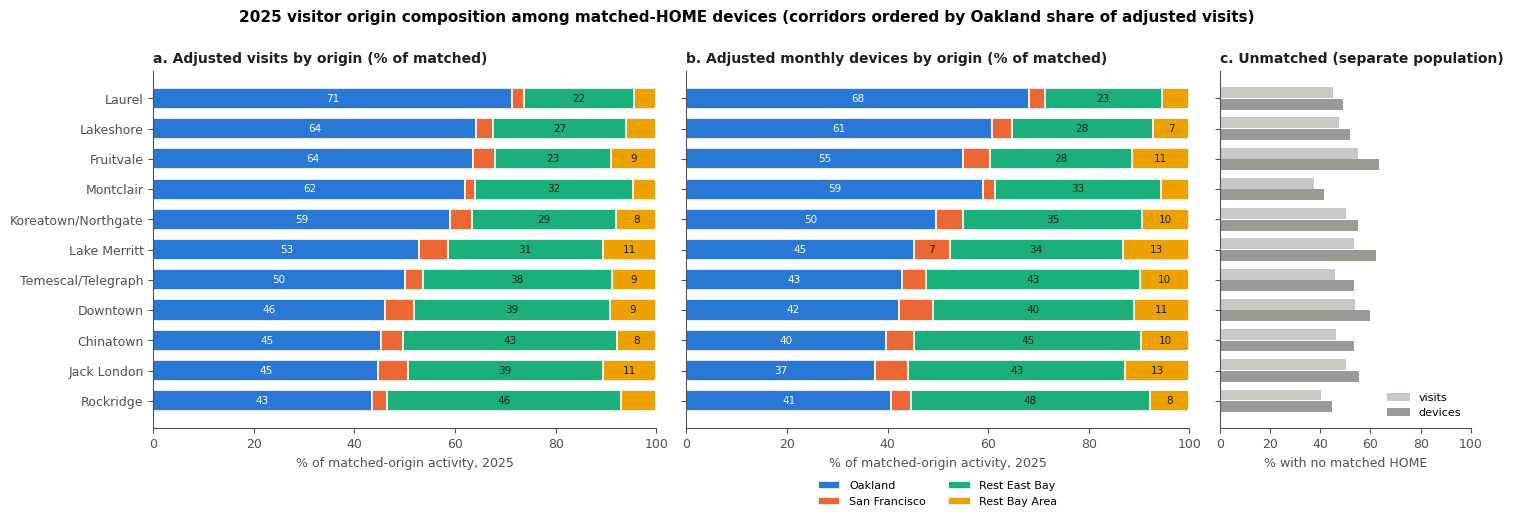

adjusted visits, % of matched                                           adjusted devices, % of matched                                            \
home_geography                            Oakland San Francisco Rest East Bay Rest Bay Area                        Oakland San Francisco Rest East Bay Rest Bay Area   
corridor_name                                                                                                                                                          
Laurel                                      71.30          2.50         21.80          4.40                          68.20          3.00         23.30          5.50   
Lakeshore                                   64.20          3.40         26.50          6.00                          60.80          3.90         28.10          7.20   
Fruitvale                                   63.50          4.30         23.20          9.00                          55.00          5.30         28.10         11.50   
Montclair                                   62.10          1.80         31.50          4.60                          59.00          2.40         33.00          5.70   
Koreatown/Northgate                         59.00          4.50         28.50          8.00                          49.60          5.50         35.50          9.50   
Lake Merritt                                52.90          5.60         30.80         10.60                          45.20          7.10         34.40         13.30   
Temescal/Telegraph                          50.00          3.50         37.60          8.80                          42.90          4.70         42.70          9.80   
Downtown                                    46.00          5.80         39.00          9.20                          42.30          6.70         39.90         11.00   
Chinatown                                   45.30          4.40         42.50          7.70                          39.60          5.70         45.10          9.60   
Jack London                                 44.70          5.90         38.70         10.70                          37.50          6.60         43.20         12.80   
Rockridge                                   43.40          3.10         46.50          7.00                          40.70          3.90         47.50          7.80   

                    Oakland share: visits − devices (pp) unmatched, % of all visits  
home_geography                                                                       
corridor_name                                                                        
Laurel                                              3.10                      45.00  
Lakeshore                                           3.40                      47.60  
Fruitvale                                           8.50                      55.20  
Montclair                                           3.10                      37.70  
Koreatown/Northgate                                 9.50                      50.20  
Lake Merritt                                        7.70                      53.60  
Temescal/Telegraph                                  7.10                      45.70  
Downtown                                            3.70                      53.70  
Chinatown                                           5.70                      46.50  
Jack London                                         7.20                      50.10  
Rockridge                                           2.70                      40.40

Average monthly adjusted visits by origin, 2025 (underlying counts):


home_geography,Oakland,San Francisco,Rest East Bay,Rest Bay Area,matched total
corridor_name,,,,,
Laurel,"1,496.00",53.00,457.00,93.00,"2,099.00"
Lakeshore,"1,174.00",61.00,485.00,109.00,"1,829.00"
Fruitvale,"8,410.00",570.00,"3,068.00","1,188.00","13,236.00"
Montclair,763.00,23.00,387.00,56.00,"1,229.00"
Koreatown/Northgate,"3,174.00",239.00,"1,535.00",430.00,"5,378.00"
Lake Merritt,"7,024.00",748.00,"4,096.00","1,412.00","13,280.00"
Temescal/Telegraph,"4,256.00",299.00,"3,199.00",750.00,"8,504.00"
Downtown,"4,694.00",591.00,"3,974.00",940.00,"10,199.00"
Chinatown,"4,298.00",422.00,"4,036.00",735.00,"9,491.00"


In [15]:
# Category definitions come from the extraction (Oakland by CBG representative point inside the TIGER2019 Oakland place polygon;
# East Bay = Alameda 001 + Contra Costa 013; San Francisco = county 075). Verify them against the exported geography.
geo_home['county'] = geo_home.block_group_id.str.split('.').str[2]
rules = {'Every CBG is a California Bay county': bool(geo_home.county.isin(BAY_COUNTIES).all()),
         'Oakland CBGs all lie in Alameda County': bool(geo_home[geo_home.home_geography == 'Oakland'].county.eq('001').all()),
         'San Francisco category = county 075 exactly': bool((geo_home.home_geography.eq('San Francisco') == geo_home.county.eq('075')).all()),
         'Rest East Bay lies only in Alameda or Contra Costa, and every non-Oakland Alameda CBG is Rest East Bay': bool(
             geo_home[geo_home.home_geography == 'Rest East Bay'].county.isin(EAST_BAY_COUNTIES).all() and geo_home[(geo_home.county == '001') & (geo_home.home_geography != 'Oakland')].home_geography.eq('Rest East Bay').all()),
         'All other Bay CBGs are Rest Bay Area': bool(geo_home[~geo_home.county.isin(EAST_BAY_COUNTIES + ['075'])].home_geography.eq('Rest Bay Area').all())}
print('\n'.join(f'{"PASS" if ok else "FAIL"}: {r}' for r, ok in rules.items()))
print('CBGs by category:', geo_home.home_geography.value_counts()[ORIGIN_ORDER].to_dict(), '(the Oakland rule is a point-in-city rule on CBGs; no municipality is inferred anywhere in this notebook)')

def origin_avg(year, months=range(1, 13), measure='visits', period='all'):
    """Average monthly adjusted activity by matched origin category (corridor × category)."""
    d = origin[(origin.year == year) & origin.month.isin(list(months)) & (origin.time_period == period) & (origin.home_geography != UNMATCHED)]
    return d.groupby(['corridor_name', 'home_geography'])[MEASURE_COL[measure]].sum().unstack().reindex(index=CORRIDORS, columns=ORIGIN_ORDER).fillna(0) / len(list(months))
def shares(w): return 100 * w.div(w.sum(axis=1), axis=0)
def unmatched_share(year, measure):
    s = stops[(stops.year == year) & (stops.time_period == 'all')].groupby('corridor_name')[['visit_count', 'home_matched_visits', 'unique_devices', 'home_matched_devices']].sum().reindex(CORRIDORS)
    return 100 * (1 - (s.home_matched_visits / s.visit_count if measure == 'visits' else s.home_matched_devices / s.unique_devices))

sh = {m: shares(origin_avg(2025, measure=m)) for m in ('visits', 'devices')}
order_o = sh['visits'].Oakland.sort_values(ascending=False).index.tolist(); unm = {m: unmatched_share(2025, m) for m in ('visits', 'devices')}
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True, gridspec_kw={'width_ratios': [1, 1, 0.5]}); y = np.arange(len(order_o))[::-1]
for ax, m, ttl in [(axes[0], 'visits', 'a. Adjusted visits by origin (% of matched)'), (axes[1], 'devices', 'b. Adjusted monthly devices by origin (% of matched)')]:
    left = np.zeros(len(order_o))
    for cat in ORIGIN_ORDER:
        v = sh[m].loc[order_o, cat].to_numpy(); ax.barh(y, v, left=left, color=ORIGIN_COLORS[cat], height=0.7, edgecolor='white', linewidth=1.2, label=cat)
        for yi, l, w in zip(y, left, v):
            if w >= 7: ax.text(l + w / 2, yi, f'{w:.0f}', ha='center', va='center', fontsize=7.5, color='white' if cat == 'Oakland' else INK)
        left += v
    ax.set_xlim(0, 100); ax.set_xlabel('% of matched-origin activity, 2025'); ax.set_title(ttl, loc='left'); ax.grid(False)
axes[0].set_yticks(y); axes[0].set_yticklabels(order_o); axes[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=8)
ax = axes[2]; ax.barh(y + 0.19, unm['visits'].loc[order_o], height=0.36, color='#c9c8c2', label='visits'); ax.barh(y - 0.19, unm['devices'].loc[order_o], height=0.36, color=C_GRAY, label='devices')
ax.set_xlim(0, 100); ax.set_xlabel('% with no matched HOME'); ax.set_title('c. Unmatched (separate population)', loc='left'); ax.grid(False); ax.legend(fontsize=8, loc='lower right')
fig.suptitle('2025 visitor origin composition among matched-HOME devices (corridors ordered by Oakland share of adjusted visits)', fontsize=11, fontweight='bold', y=1.0); plt.tight_layout(); plt.show()

comp = pd.concat({'adjusted visits, % of matched': sh['visits'].loc[order_o], 'adjusted devices, % of matched': sh['devices'].loc[order_o]}, axis=1)
comp[('Oakland share: visits − devices (pp)', '')] = sh['visits'].Oakland - sh['devices'].Oakland
comp[('unmatched, % of all visits', '')] = unm['visits']
display(comp.round(1))
print('Average monthly adjusted visits by origin, 2025 (underlying counts):'); display(origin_avg(2025).loc[order_o].round(0).assign(**{'matched total': lambda d: d.sum(axis=1).round(0)}))

**Takeaways: 2025 catchments (adjusted, matched devices)**
- **Predominantly Oakland-origin by visits:** Laurel 71%, Lakeshore 64%, Fruitvale 64%, Montclair 62% and Koreatown/Northgate 59% of matched visits; Lake Merritt (53%) and Temescal/Telegraph (50%) about half.
- **Strongest ties to the rest of the East Bay:** Rockridge (47% Rest East Bay, 43% Oakland), Chinatown (43% Rest East Bay), Downtown (39%), Jack London (39%) and Temescal/Telegraph (38%).
- **Broadest Bay Area reach** (San Francisco + Rest Bay Area): Jack London (17% of visits), Lake Merritt (16%) and Downtown (15%); the neighbourhood corridors draw 6–10%.
- **Visit-based and device-based catchments differ.** Oakland-origin devices visit more often, so the Oakland share of *visits* exceeds that of *devices* by 2.7 (Rockridge) to 9.5 points (Koreatown/Northgate). By devices only Laurel (68%), Lakeshore (61%), Montclair (59%) and Fruitvale (55%) are majority-Oakland, Koreatown/Northgate falls just below half (49.6%), and the East Bay and wider-Bay shares are larger (Jack London: 43% Rest East Bay and 19% San Francisco + Rest Bay Area of devices). The visitor *base* is wider than the visit *volume* suggests.
- **Unmatched devices** are 38% (Montclair) to 55% (Fruitvale) of all visits and 41–63% of devices, shown separately; these catchments describe matched devices only.

### 4.1 Changes in catchments: 2019 → 2022 (LIMA) and 2024 → 2025 (PAPA)
Each era is within one provider. The table separates **local activity growing** from **non-local activity falling**: Oakland-origin and non-Oakland matched activity are compared in adjusted counts (visits and devices), alongside the change in Oakland's share in percentage points.

LIMA: 2019 → 2022


adjusted visits                                                              adjusted devices                                                   driver (visits)
                    Oakland share start (%) Oakland share end (%) Δ share (pp) Oakland Δ% non-Oakland Δ%     Δ share (pp) Oakland Δ% non-Oakland Δ%                                        
corridor_name                                                                                                                                                                              
Lake Merritt                          31.40                 40.30         8.80     -26.70         -50.10             2.90     -21.10         -31.30  both below 2019, non-Oakland fell more
Fruitvale                             69.20                 71.30         2.10       4.10          -5.70             1.90       5.80          -2.20         Oakland up, elsewhere down/flat
Downtown                              30.60                 36.10         5.50     -26.80         -42.90             1.10     -20.30         -24.60  both below 2019, non-Oakland fell more
Chinatown                             35.80                 39.30         3.60     -27.90         -38.10             3.60     -18.90         -31.90  both below 2019, non-Oakland fell more
Temescal/Telegraph                    39.10                 38.60        -0.50     -14.60         -12.80             0.30     -11.20         -12.50      both below 2019, Oakland fell more
Jack London                           33.00                 36.50         3.50     -13.80         -26.10             1.00     -21.10         -25.10  both below 2019, non-Oakland fell more
Koreatown/Northgate                   40.30                 45.90         5.60     -16.10         -33.20             3.40     -17.60         -29.20  both below 2019, non-Oakland fell more
Rockridge                             43.00                 42.50        -0.50     -25.10         -23.50             0.40     -18.60         -19.90      both below 2019, Oakland fell more
Laurel                                76.70                 78.50         1.70     -10.20         -18.70             1.00      -3.90          -8.20  both below 2019, non-Oakland fell more
Lakeshore                             66.40                 63.60        -2.80     -19.10          -8.70            -0.80     -16.30         -13.30      both below 2019, Oakland fell more
Montclair                             65.60                 65.30        -0.30     -26.80         -25.80             1.70     -20.30         -25.70      both below 2019, Oakland fell more

PAPA: 2024 → 2025


adjusted visits                                                              adjusted devices                                            driver (visits)
                    Oakland share start (%) Oakland share end (%) Δ share (pp) Oakland Δ% non-Oakland Δ%     Δ share (pp) Oakland Δ% non-Oakland Δ%                                 
corridor_name                                                                                                                                                                       
Lake Merritt                          47.10                 52.90         5.80      25.20          -0.60             2.90       7.30          -4.80  Oakland up, elsewhere down/flat
Fruitvale                             55.60                 63.50         8.00      19.10         -14.60             6.00       6.70         -16.10  Oakland up, elsewhere down/flat
Downtown                              43.90                 46.00         2.10       3.80          -4.80             1.60      -4.80         -10.80  Oakland up, elsewhere down/flat
Chinatown                             42.60                 45.30         2.60      19.90           7.70             0.90       6.90           3.20          both up, Oakland faster
Temescal/Telegraph                    45.10                 50.00         5.00      18.60          -2.80             2.10       1.90          -6.70  Oakland up, elsewhere down/flat
Jack London                           41.50                 44.70         3.20      10.80          -2.90             1.00      -3.40          -7.30  Oakland up, elsewhere down/flat
Koreatown/Northgate                   54.70                 59.00         4.30      24.50           4.30             2.00       8.30           0.20          both up, Oakland faster
Rockridge                             42.00                 43.40         1.40       6.30           0.40             0.90       1.00          -2.60          both up, Oakland faster
Laurel                                69.40                 71.30         1.90       5.40          -3.70             1.50       0.10          -6.40  Oakland up, elsewhere down/flat
Lakeshore                             61.40                 64.20         2.80       1.10         -10.20             2.60      -0.10         -10.10  Oakland up, elsewhere down/flat
Montclair                             58.10                 62.10         4.00      14.40          -3.10             3.60       8.10          -6.60  Oakland up, elsewhere down/flat

Excluding December: Oakland share still rises in 11 of 11 corridors (max difference from the full-year change 0.5 pp).
Change in share of adjusted visits by origin category (percentage points):


2019 → 2022 (LIMA)                                           2024 → 2025 (PAPA)                                          
home_geography                 Oakland San Francisco Rest East Bay Rest Bay Area            Oakland San Francisco Rest East Bay Rest Bay Area
corridor_name                                                                                                                                
Lake Merritt                      8.80         -2.20         -7.10          0.50               5.80         -0.10         -3.80         -1.90
Fruitvale                         2.10         -0.30         -2.70          1.00               8.00         -0.10         -4.80         -3.00
Downtown                          5.50         -0.70         -4.20         -0.60               2.10          0.20         -1.30         -1.00
Chinatown                         3.60         -0.60         -2.90         -0.10               2.60          0.20         -2.20         -0.60
Temescal/Telegraph               -0.50         -0.30          0.90         -0.10               5.00         -0.20         -3.10         -1.60
Jack London                       3.50          0.50         -3.40         -0.60               3.20          0.30         -2.40         -1.10
Koreatown/Northgate               5.60         -0.60         -4.20         -0.70               4.30         -0.50         -3.10         -0.70
Rockridge                        -0.50          0.30          0.10          0.10               1.40         -0.20         -0.60         -0.60
Laurel                            1.70         -0.30         -1.50          0.00               1.90         -0.20         -1.10         -0.60
Lakeshore                        -2.80         -0.10          2.90         -0.10               2.80          0.00         -1.40         -1.40
Montclair                        -0.30         -0.30         -0.20          0.80               4.00         -0.50         -2.50         -1.00

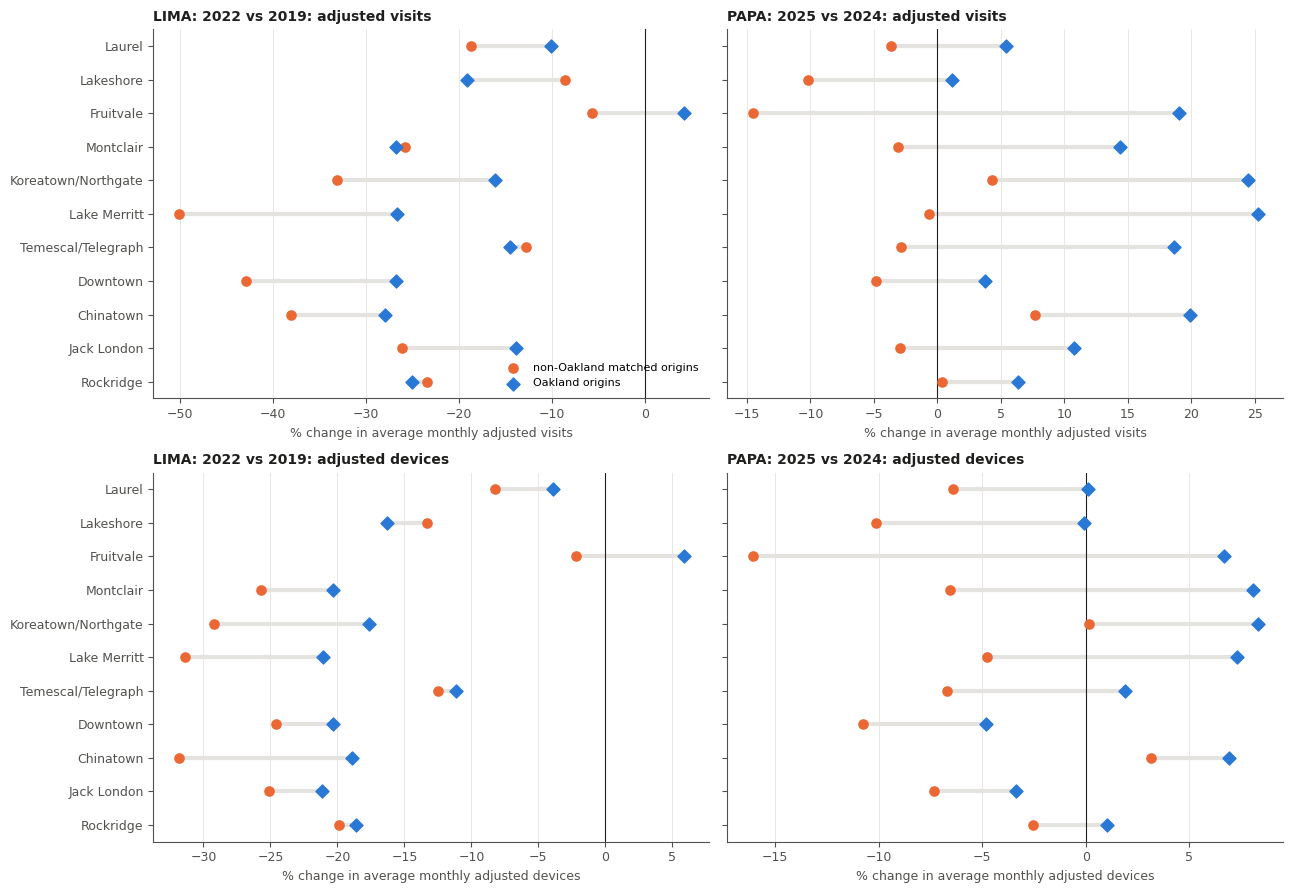

In [16]:
def origin_change(y0, y1, months=range(1, 13)):
    out = {}
    for m in ('visits', 'devices'):
        a0, a1 = origin_avg(y0, months, m), origin_avg(y1, months, m)
        n0, n1 = a0.drop(columns='Oakland').sum(axis=1), a1.drop(columns='Oakland').sum(axis=1)
        out[m] = pd.DataFrame({'Oakland share y0 (%)': 100 * a0.Oakland / a0.sum(axis=1), 'Oakland share y1 (%)': 100 * a1.Oakland / a1.sum(axis=1),
                               'Δ share (pp)': 100 * (a1.Oakland / a1.sum(axis=1) - a0.Oakland / a0.sum(axis=1)), 'Oakland Δ%': pct_change(a0.Oakland, a1.Oakland), 'non-Oakland Δ%': pct_change(n0, n1)})
    return out
def driver(go, gn):
    if go > 0 and gn <= 0: return 'Oakland up, elsewhere down/flat'
    if go > gn > 0: return 'both up, Oakland faster'
    if gn > go > 0: return 'both up, elsewhere faster'
    if go <= 0 and gn <= 0: return 'both down'
    return 'Oakland down, elsewhere up'
def lima_driver(go, gn):   # LIMA is mostly a decline from the 2020 collapse, so describe which side fell further relative to 2019
    return 'both below 2019, non-Oakland fell more' if go < 0 and gn < 0 and gn < go else 'both below 2019, Oakland fell more' if go < 0 and gn < 0 else driver(go, gn)
CH = {'LIMA': origin_change(2019, 2022), 'PAPA': origin_change(2024, 2025)}
for era, f in [('LIMA', lima_driver), ('PAPA', driver)]:
    d = CH[era]['visits'].copy()
    t = pd.concat({'adjusted visits': d.rename(columns={'Oakland share y0 (%)': 'Oakland share start (%)', 'Oakland share y1 (%)': 'Oakland share end (%)'}), 'adjusted devices': CH[era]['devices'][['Δ share (pp)', 'Oakland Δ%', 'non-Oakland Δ%']]}, axis=1)
    t[('driver (visits)', '')] = [f(d.loc[c, 'Oakland Δ%'], d.loc[c, 'non-Oakland Δ%']) for c in CORRIDORS]
    print(f'{era}: {"2019 → 2022" if era == "LIMA" else "2024 → 2025"}'); display(t.round(1))
jn = origin_change(2024, 2025, JAN_NOV)['visits']
print(f'Excluding December: Oakland share still rises in {int((jn["Δ share (pp)"] > 0).sum())} of 11 corridors (max difference from the full-year change {(jn["Δ share (pp)"] - CH["PAPA"]["visits"]["Δ share (pp)"]).abs().max():.1f} pp).')
cat_pp = pd.concat({'2019 → 2022 (LIMA)': shares(origin_avg(2022)) - shares(origin_avg(2019)), '2024 → 2025 (PAPA)': shares(origin_avg(2025)) - shares(origin_avg(2024))}, axis=1)
print('Change in share of adjusted visits by origin category (percentage points):'); display(cat_pp.round(1))

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
for j, (era, ttl) in enumerate([('LIMA', 'LIMA: 2022 vs 2019'), ('PAPA', 'PAPA: 2025 vs 2024')]):
    for i, m in enumerate(['visits', 'devices']):
        ax = axes[i, j]; d = CH[era][m].reindex(order_o); y = np.arange(len(d))[::-1]
        ax.hlines(y, d['non-Oakland Δ%'], d['Oakland Δ%'], color=GRID, lw=3, zorder=1)
        ax.scatter(d['non-Oakland Δ%'], y, s=44, color=C_ORANGE, zorder=3, label='non-Oakland matched origins'); ax.scatter(d['Oakland Δ%'], y, s=44, color=C_BLUE, marker='D', zorder=3, label='Oakland origins')
        ax.axvline(0, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(d.index); ax.grid(axis='y', visible=False); ax.set_title(f'{ttl}: adjusted {m}', loc='left'); ax.set_xlabel('% change in average monthly adjusted ' + m)
axes[0, 0].legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

**Takeaways: how catchments changed**
- **LIMA, 2019 → 2022: the corridors that lost the most lost non-Oakland activity.** In Lake Merritt, Downtown and Chinatown, Oakland-origin adjusted visits fell 27–28% while non-Oakland visits fell 50%, 43% and 38%; devices fell 21%, 20% and 19% (Oakland) against 31%, 25% and 32% (non-Oakland). The Oakland share therefore rose by 8.8, 5.5 and 3.6 points. The same shape, milder, holds in Koreatown/Northgate (−16% vs −33%), Jack London (−14% vs −26%) and Laurel (−10% vs −19%). In Temescal/Telegraph, Rockridge, Lakeshore and Montclair Oakland-origin visits fell as much as or more than non-Oakland ones (Oakland share −2.8 to −0.3 points), and Fruitvale's Oakland-origin visits grew (+4%) while non-Oakland fell (−6%). So a rising Oakland share in LIMA means **non-local visits did not come back**, not that local visits grew.
- **PAPA, 2024 → 2025: local activity grew and non-local activity stagnated or fell.** Oakland-origin adjusted visits rose in all 11 corridors (+1% Lakeshore to +25% Lake Merritt), while non-Oakland visits fell in eight (−0.6% Lake Merritt to −14.6% Fruitvale) and rose in Chinatown (+7.7%), Koreatown/Northgate (+4.3%) and Rockridge (+0.4%). Oakland's share rose by 1.4 (Rockridge) to 8.0 points (Fruitvale), with Rest East Bay (−0.6 to −4.8 points) and Rest Bay Area (−0.6 to −3.0) giving way and San Francisco within ±0.5. By devices, Oakland-origin devices rose in eight corridors (up to +8.3% Koreatown/Northgate) while non-Oakland devices fell in nine (up to −16.1% Fruitvale): the breadth of the local base held or grew modestly while elsewhere's shrank.
- Excluding December changes none of this materially: Oakland's share still rises in all 11 corridors, within a fraction of a point of the full-year change.

## 5. Distance and local versus regional reach
Distances run **from the HOME block group's representative (internal) point to the corridor's centroid**: straight-line kilometres, not travel distances, and not exact homes. Long corridors are measured less precisely from a single centroid. Shares use known-distance (matched) activity as the denominator; unknown distance is exactly the unmatched population and is shown separately. Bands are 0–2, 2–5, 5–10, 10–25, 25–50, 50–100 and 100+ km, so the summaries use only exact band edges: within 5 km, within 10 km, beyond 25 km. Visit-based and device-based catchments are both shown.

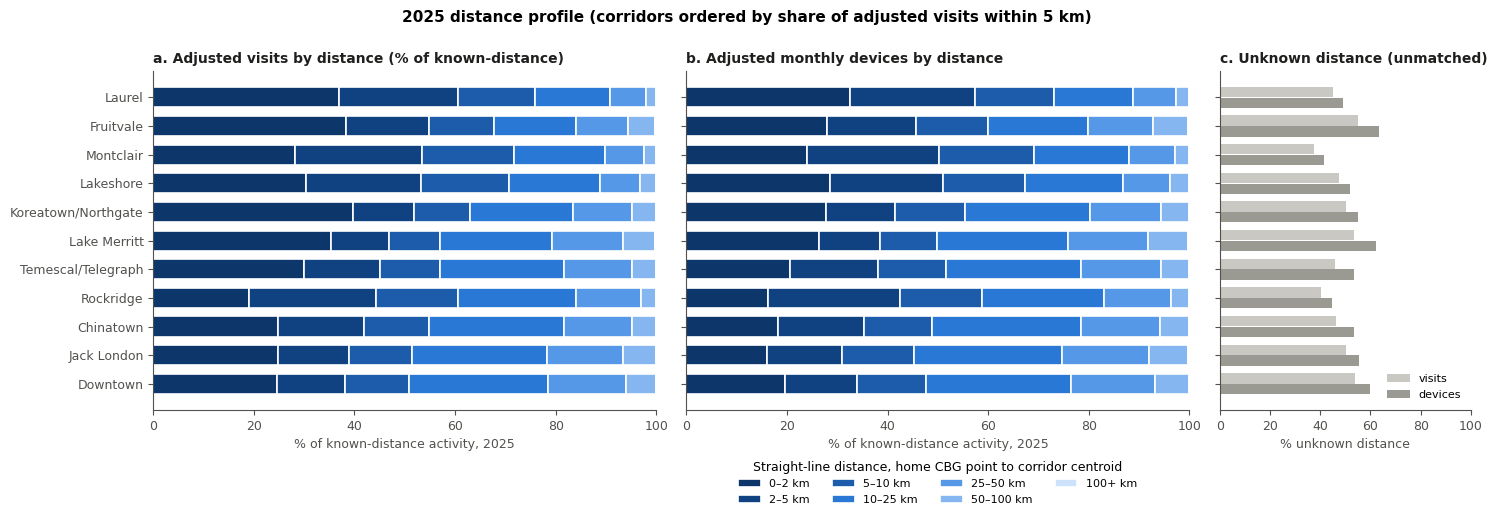

2019 visits                           2022 visits                           2024 visits                           2025 visits                            \
                    within 5 km within 10 km beyond 25 km within 5 km within 10 km beyond 25 km within 5 km within 10 km beyond 25 km within 5 km within 10 km beyond 25 km   
corridor_name                                                                                                                                                                 
Laurel                    67.40        81.70         6.40       67.80        83.20         6.30       58.20        74.40        10.00       60.50        76.00         9.10   
Fruitvale                 60.20        77.20         8.80       60.60        77.10         9.10       46.80        59.90        21.50       54.90        67.70        15.90   
Montclair                 64.10        80.00         7.40       59.50        76.30         8.30       49.00        68.40        11.30       53.50        71.70        10.10   
Lakeshore                 56.80        73.30         8.60       54.90        72.80         8.20       50.80        68.00        13.10       53.20        70.60        11.10   
Koreatown/Northgate       32.30        50.40        21.90       36.60        55.40        18.70       47.40        59.00        18.00       51.80        63.00        16.50   
Lake Merritt              26.10        41.40        27.20       33.00        50.20        23.40       40.20        51.20        23.90       46.90        57.10        20.80   
Temescal/Telegraph        35.50        50.70        20.90       35.00        51.90        19.90       40.00        52.90        20.70       45.00        57.00        18.40   
Rockridge                 48.00        67.70        12.80       48.40        67.30        12.00       43.30        59.40        16.10       44.30        60.50        15.90   
Chinatown                 34.10        49.50        18.90       37.40        54.60        17.70       39.60        53.20        19.40       41.90        54.90        18.30   
Jack London               24.00        43.20        27.40       26.40        43.50        26.40       35.50        48.60        23.90       38.90        51.40        21.80   
Downtown                  23.70        40.40        27.00       28.30        45.50        24.10       35.90        48.70        23.10       38.10        50.80        21.50   

                    Δ within 5 km (pp), 2019 → 2022         Δ within 5 km (pp), 2024 → 2025         Δ beyond 25 km (pp), 2024 → 2025  
                                             visits devices                          visits devices                           visits  
corridor_name                                                                                                                         
Laurel                                         0.40    0.70                            2.30    1.70                            -0.90  
Fruitvale                                      0.40    0.30                            8.10    5.60                            -5.60  
Montclair                                     -4.60   -1.80                            4.50    4.00                            -1.20  
Lakeshore                                     -2.00   -1.80                            2.40    2.40                            -2.00  
Koreatown/Northgate                            4.30    2.10                            4.40    1.10                            -1.60  
Lake Merritt                                   6.80    1.40                            6.70    3.30                            -3.10  
Temescal/Telegraph                            -0.50   -1.00                            5.00    1.80                            -2.30  
Rockridge                                      0.40   -0.10                            1.00    0.90                            -0.20  
Chinatown                                      3.30    2.80                         

Spearman (n=11): Oakland share vs within-5 km share, 2025 adjusted visits: 0.89; change in Oakland share vs change in within-5 km share, PAPA: 0.96, LIMA: 0.93
Excluding December, the within-5 km share of visits still rises in 11 of 11 corridors (PAPA).


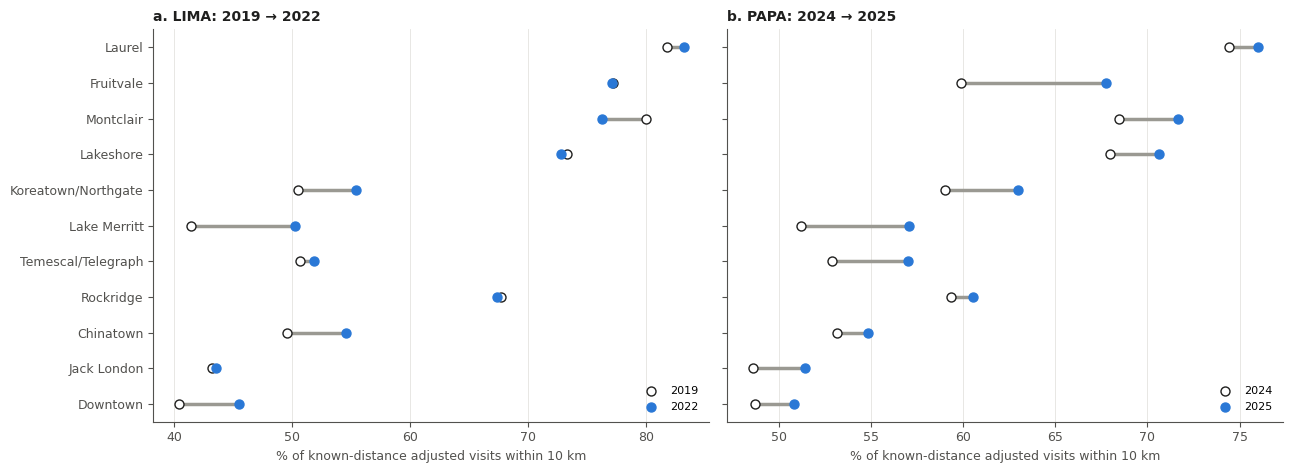

In [17]:
def dist_avg(year, months=range(1, 13), measure='visits'):
    d = dist[(dist.year == year) & dist.month.isin(list(months)) & (dist.time_period == 'all') & (dist.distance_band != UNKNOWN_DISTANCE)]
    return d.groupby(['corridor_name', 'distance_band'])[MEASURE_COL[measure]].sum().unstack().reindex(index=CORRIDORS, columns=DIST_BANDS).fillna(0) / len(list(months))
def dist_summary(year, months=range(1, 13), measure='visits'):
    w = dist_avg(year, months, measure); t = w.sum(axis=1)
    return pd.DataFrame({'within 5 km': 100 * w[WITHIN_5].sum(axis=1) / t, 'within 10 km': 100 * w[WITHIN_10].sum(axis=1) / t, 'beyond 25 km': 100 * w[BEYOND_25].sum(axis=1) / t})
DS = {(y, m): dist_summary(y, measure=m) for y in (2019, 2022, 2024, 2025) for m in ('visits', 'devices')}
dw = {m: dist_avg(2025, measure=m) for m in ('visits', 'devices')}; order_d = DS[(2025, 'visits')]['within 5 km'].sort_values(ascending=False).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True, gridspec_kw={'width_ratios': [1, 1, 0.5]}); y = np.arange(len(order_d))[::-1]
for ax, m, ttl in [(axes[0], 'visits', 'a. Adjusted visits by distance (% of known-distance)'), (axes[1], 'devices', 'b. Adjusted monthly devices by distance')]:
    s = 100 * dw[m].div(dw[m].sum(axis=1), axis=0).loc[order_d]; left = np.zeros(len(order_d))
    for band, col in zip(DIST_BANDS, BAND_COLORS):
        ax.barh(y, s[band], left=left, color=col, height=0.7, edgecolor='white', linewidth=1.2, label=band[4:]); left += s[band].to_numpy()
    ax.set_xlim(0, 100); ax.set_xlabel('% of known-distance activity, 2025'); ax.set_title(ttl, loc='left'); ax.grid(False)
axes[0].set_yticks(y); axes[0].set_yticklabels(order_d); axes[1].legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=8, title='Straight-line distance, home CBG point to corridor centroid')
axes[2].barh(y + 0.19, unm['visits'].loc[order_d], height=0.36, color='#c9c8c2', label='visits'); axes[2].barh(y - 0.19, unm['devices'].loc[order_d], height=0.36, color=C_GRAY, label='devices')
axes[2].set_xlim(0, 100); axes[2].set_xlabel('% unknown distance'); axes[2].set_title('c. Unknown distance (unmatched)', loc='left'); axes[2].grid(False); axes[2].legend(fontsize=8, loc='lower right')
fig.suptitle('2025 distance profile (corridors ordered by share of adjusted visits within 5 km)', fontsize=11, fontweight='bold', y=1.0); plt.tight_layout(); plt.show()

dt = pd.concat({f'{y} visits': DS[(y, 'visits')] for y in (2019, 2022, 2024, 2025)}, axis=1)
dd_ = pd.DataFrame({('Δ within 5 km (pp), 2019 → 2022', 'visits'): DS[(2022, 'visits')]['within 5 km'] - DS[(2019, 'visits')]['within 5 km'], ('Δ within 5 km (pp), 2019 → 2022', 'devices'): DS[(2022, 'devices')]['within 5 km'] - DS[(2019, 'devices')]['within 5 km'],
                    ('Δ within 5 km (pp), 2024 → 2025', 'visits'): DS[(2025, 'visits')]['within 5 km'] - DS[(2024, 'visits')]['within 5 km'], ('Δ within 5 km (pp), 2024 → 2025', 'devices'): DS[(2025, 'devices')]['within 5 km'] - DS[(2024, 'devices')]['within 5 km'],
                    ('Δ beyond 25 km (pp), 2024 → 2025', 'visits'): DS[(2025, 'visits')]['beyond 25 km'] - DS[(2024, 'visits')]['beyond 25 km']})
display(pd.concat([dt, dd_], axis=1).loc[order_d].round(1))
print('Spearman (n=11): Oakland share vs within-5 km share, 2025 adjusted visits: %.2f; change in Oakland share vs change in within-5 km share, PAPA: %.2f, LIMA: %.2f' % (
    spearmanr(sh['visits'].Oakland, DS[(2025, 'visits')]['within 5 km'])[0], spearmanr(CH['PAPA']['visits']['Δ share (pp)'], dd_[('Δ within 5 km (pp), 2024 → 2025', 'visits')])[0],
    spearmanr(CH['LIMA']['visits']['Δ share (pp)'], dd_[('Δ within 5 km (pp), 2019 → 2022', 'visits')])[0]))

dj = dist_summary(2025, JAN_NOV)['within 5 km'] - dist_summary(2024, JAN_NOV)['within 5 km']
print(f'Excluding December, the within-5 km share of visits still rises in {int((dj > 0).sum())} of 11 corridors (PAPA).')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (y0, y1, ttl) in zip(axes, [(2019, 2022, 'a. LIMA: 2019 → 2022'), (2024, 2025, 'b. PAPA: 2024 → 2025')]):
    a, b = DS[(y0, 'visits')]['within 10 km'].loc[order_d], DS[(y1, 'visits')]['within 10 km'].loc[order_d]; y = np.arange(len(order_d))[::-1]
    ax.hlines(y, a, b, color=C_GRAY, lw=2.5, zorder=1); ax.scatter(a, y, s=42, facecolor='white', edgecolor=INK, zorder=3, label=str(y0)); ax.scatter(b, y, s=42, color=C_BLUE, zorder=3, label=str(y1))
    ax.set_yticks(y); ax.set_yticklabels(order_d); ax.grid(axis='y', visible=False); ax.legend(loc='lower right', fontsize=8); ax.set_title(ttl, loc='left'); ax.set_xlabel('% of known-distance adjusted visits within 10 km')
plt.tight_layout(); plt.show()

**Takeaways: distance and reach (adjusted visits, 2025 unless stated)**
- **Most local:** Laurel (61% of known-distance visits within 5 km, 76% within 10 km, 9% beyond 25 km), then Fruitvale (55%), Montclair (54%), Lakeshore (53%) and Koreatown/Northgate (52%). **Most regional:** Downtown (38% within 5 km, 51% within 10 km), Jack London (39%, 51%) and Chinatown (42%, 55%); beyond-25 km shares are highest in Jack London (22%), Downtown (22%) and Lake Merritt (21%). By devices the within-5 km shares are lower and the changes smaller, as in section 4.
- **LIMA: the central corridors became more local because distant visitors did not return.** Within-5 km share of visits rose 6.8 points in Lake Merritt (26% → 33%), 4.5 in Downtown, 4.3 in Koreatown/Northgate and 3.3 in Chinatown, but fell in Montclair (−4.6) and Lakeshore (−2.0), which were already local.
- **PAPA: more local in every corridor.** The within-5 km share rose in all 11 (+1.0 Rockridge to +8.1 Fruitvale; Lake Merritt +6.7, Temescal/Telegraph +5.0, Montclair +4.5, Koreatown/Northgate +4.4), and the beyond-25 km share fell in all 11 (−0.2 to −5.6). By devices the within-5 km rise is smaller (+0.4 to +5.6) but also in all 11.
- **Same finding as the origin categories, not a new one:** Oakland share and within-5 km share are strongly related across corridors (ρ = 0.89) and so are their changes (ρ = 0.96 in PAPA, 0.93 in LIMA). The one thing distance adds is Rockridge, East-Bay-oriented (47% Rest East Bay) yet local (44% within 5 km) because its non-Oakland visitors live nearby.
- Bands are coarse and distances are to a single centroid, so differences of a point or two are not meaningful; the cross-corridor ordering and the direction of change are.

### 5.1 Selective use of `corridor_homes_monthly`
This table keeps the home-origin detail underlying the adjusted measures: one row per **corridor × month × time period × home CBG** (about 1 M rows for the `all` period alone, several times more across the five periods), which is why it is large. It is read **once**, partition by partition, with `usecols`, filtered to the `all` period, and **aggregated before anything is retained**: (i) corridor-month totals for verifying the adjusted measures and for the weight diagnostics in section 7, and (ii) corridor × month × origin-place totals (Oakland city, rest of Alameda County, Contra Costa and other counties from the county code in the CBG identifier) for a few contrasting corridors. No CBG-by-month matrix is built, and no municipality is inferred.

corridor_homes_monthly:   0%|          | 0/84 [00:00<?, ?it/s]

corridor_homes_monthly:  18%|█▊        | 15/84 [00:02<00:09,  7.26it/s]

corridor_homes_monthly:  43%|████▎     | 36/84 [00:04<00:05,  9.03it/s]

corridor_homes_monthly:  68%|██████▊   | 57/84 [00:06<00:02,  9.40it/s]

corridor_homes_monthly:  90%|█████████ | 76/84 [00:09<00:01,  7.69it/s]

corridor_homes_monthly: 100%|██████████| 84/84 [00:10<00:00,  7.84it/s]

1,071,812 corridor × month × CBG rows read ("all" period, matched CBGs); retained only 924 corridor-month and 9,033 corridor-month-place rows.
Max |adjusted visits: corridor_homes_monthly − corridor_stops| = 3.6e-12; adjusted devices = 1.8e-12
Selected corridors: {'most Oakland-oriented': 'Laurel', 'largest Rest East Bay share': 'Rockridge', 'widest reach (SF + Rest Bay Area)': 'Jack London', 'largest LIMA rise in Oakland share': 'Lake Merritt'}
Average monthly adjusted visits by origin place (counts):


place               Oakland (city)  Alameda Co., outside Oakland  Contra Costa Co.  San Francisco Co.  Other Bay counties
corridor_name year                                                                                                       
Laurel        2019        2,119.00                        369.00            157.00              44.00               73.00
              2022        1,904.00                        293.00            134.00              32.00               64.00
              2024        1,419.00                        322.00            146.00              55.00              103.00
              2025        1,496.00                        316.00            141.00              53.00               93.00
Rockridge     2019        2,140.00                      1,512.00            918.00             117.00              287.00
              2022        1,604.00                      1,203.00            642.00             101.00              222.00
              2024        1,136.00                        752.00            524.00              90.00              204.00
              2025        1,208.00                        759.00            535.00              87.00              194.00
Jack London   2019        2,496.00                      2,328.00          1,496.00             328.00              920.00
              2022        2,151.00                      1,718.00          1,063.00             284.00              682.00
              2024        2,962.00                      1,789.00          1,145.00             402.00              842.00
              2025        3,281.00                      1,768.00          1,070.00             434.00              783.00
Lake Merritt  2019        4,219.00                      3,978.00          3,011.00             801.00            1,412.00
              2022        3,094.00                      1,954.00          1,499.00             291.00              847.00
              2024        5,608.00                      2,262.00          1,858.00             687.00            1,489.00
              2025        7,024.00                      2,337.00          1,759.00             748.00            1,412.00

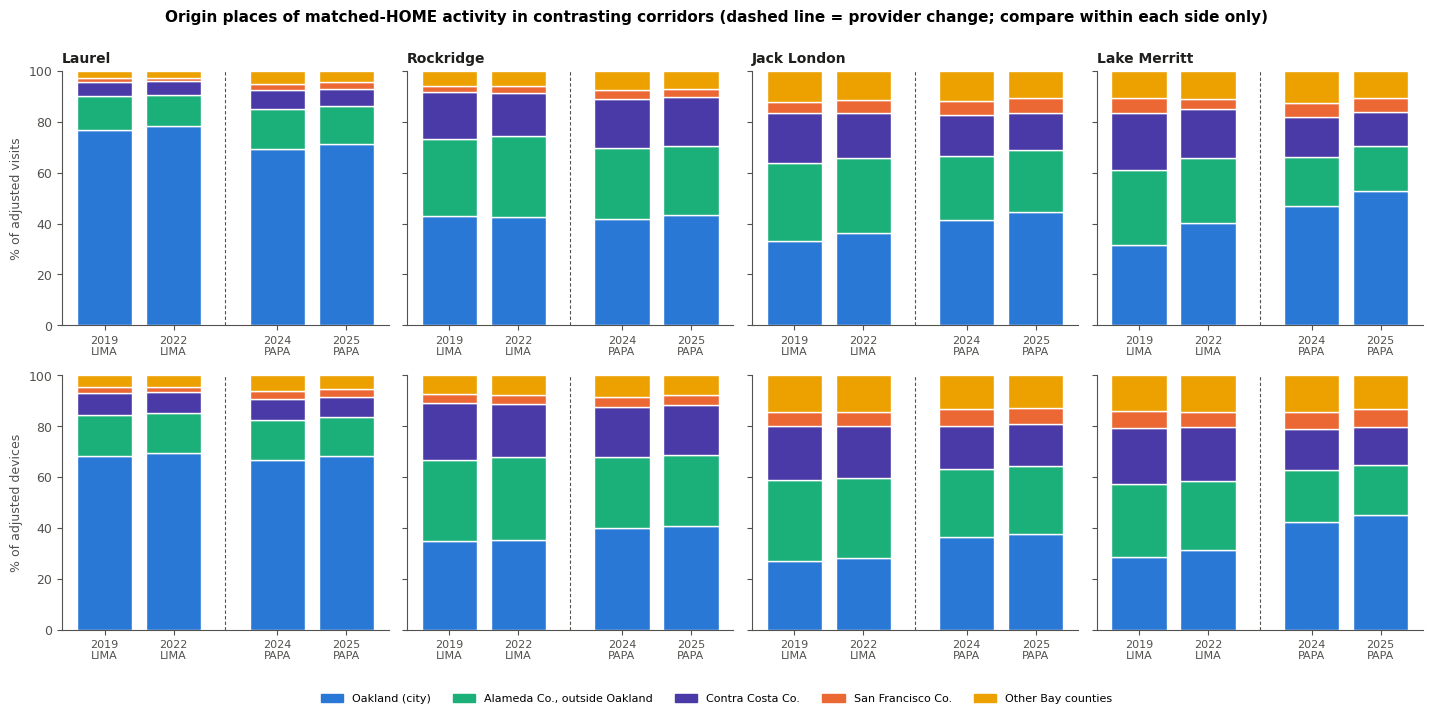

In [18]:
tot_parts, place_parts, wrange = [], [], []
for f in tqdm(sorted((DATA_DIR / 'corridor_homes_monthly').glob('*.csv.gz')), desc='corridor_homes_monthly', mininterval=2):
    d = pd.read_csv(f, usecols=HM_COLS)
    d = d[(d.time_period == 'all') & (d.block_group_id != 'UNKNOWN')].copy()
    w = d.applied_sample_ratio; extreme = (w > EXTREME_WEIGHT_HIGH) | (w < EXTREME_WEIGHT_LOW)
    d['adj_capped'] = d.visit_count * w.clip(EXTREME_WEIGHT_LOW, EXTREME_WEIGHT_HIGH)
    d['adj_dropped'] = np.where(extreme, 0.0, d.normalized_visit_count); d['adj_extreme'] = np.where(extreme, d.normalized_visit_count, 0.0)
    d['adj_fallback'] = np.where(d.normalization_method.eq('bay_fallback'), d.normalized_visit_count, 0.0); d['matched_extreme'] = np.where(extreme, d.visit_count, 0)
    county = d.block_group_id.str.slice(6, 9)
    d['place'] = np.where(d.home_geography == 'Oakland', 'Oakland (city)', np.where(county == '001', 'Alameda Co., outside Oakland', county.map(COUNTY_NAME).fillna('Other')))
    tot_parts.append(d.groupby(['corridor_name', 'year_month'])[SUM_COLS].sum().reset_index())
    place_parts.append(d.groupby(['corridor_name', 'year_month', 'place'])[['normalized_visit_count', 'normalized_unique_devices']].sum().reset_index())
    wrange.append({'year_month': int(d.year_month.iloc[0]), 'min_weight': w.min(), 'max_weight': w.max(), 'cells': len(d)})
    del d
HM_TOT, HM_PLACE, HM_W = pd.concat(tot_parts, ignore_index=True), pd.concat(place_parts, ignore_index=True), pd.DataFrame(wrange)
for df in (HM_TOT, HM_PLACE, HM_W): df['year'] = df.year_month // 100
HM_TOT['provider_id'] = HM_TOT.year_month.map(PROV_OF)

rec = HM_TOT.merge(act[['corridor_name', 'year_month', 'adj_visits', 'adj_devices']], on=['corridor_name', 'year_month'])
print(f'{HM_W.cells.sum():,} corridor × month × CBG rows read ("all" period, matched CBGs); retained only {len(HM_TOT):,} corridor-month and {len(HM_PLACE):,} corridor-month-place rows.')
print('Max |adjusted visits: corridor_homes_monthly − corridor_stops| = %.1e; adjusted devices = %.1e' % ((rec.normalized_visit_count - rec.adj_visits).abs().max(), (rec.normalized_unique_devices - rec.adj_devices).abs().max()))

# contrasting corridors, chosen from the catchment results above
sh25 = sh['visits']; sel = {'most Oakland-oriented': sh25.Oakland.idxmax(), 'largest Rest East Bay share': sh25['Rest East Bay'].idxmax(),
                            'widest reach (SF + Rest Bay Area)': (sh25['San Francisco'] + sh25['Rest Bay Area']).idxmax(), 'largest LIMA rise in Oakland share': CH['LIMA']['visits']['Δ share (pp)'].idxmax()}
SELECTED = list(dict.fromkeys(sel.values())); print('Selected corridors:', sel)
pl = HM_PLACE[HM_PLACE.corridor_name.isin(SELECTED) & HM_PLACE.year.isin([2019, 2022, 2024, 2025])].copy()
pl['place'] = np.where(pl.place.isin(PLACE_ORDER[:4]), pl.place, 'Other Bay counties')
py = pl.groupby(['corridor_name', 'year', 'place'])[['normalized_visit_count', 'normalized_unique_devices']].sum().reset_index()
py[['normalized_visit_count', 'normalized_unique_devices']] /= 12
lv = py.pivot_table(index=['corridor_name', 'year'], columns='place', values='normalized_visit_count').reindex(columns=PLACE_ORDER).fillna(0)
ld = py.pivot_table(index=['corridor_name', 'year'], columns='place', values='normalized_unique_devices').reindex(columns=PLACE_ORDER).fillna(0)
print('Average monthly adjusted visits by origin place (counts):'); display(lv.reindex(SELECTED, level=0).round(0))

fig, axes = plt.subplots(2, len(SELECTED), figsize=(3.6 * len(SELECTED), 7), sharey='row')
for j, c in enumerate(SELECTED):
    for i, (tab, lab) in enumerate([(lv, 'visits'), (ld, 'devices')]):
        ax = axes[i, j]; t = tab.loc[c]; s = 100 * t.div(t.sum(axis=1), axis=0); xs = np.arange(len(s)) + (np.array(s.index) > 2022) * 0.5; bottom = np.zeros(len(s))
        for place, col in zip(PLACE_ORDER, PLACE_COLORS):
            ax.bar(xs, s[place], bottom=bottom, color=col, width=0.8, edgecolor='white', linewidth=1, label=place); bottom += s[place].to_numpy()
        ax.set_xticks(xs); ax.set_xticklabels([f'{y}\n{"LIMA" if y < 2023 else "PAPA"}' for y in s.index], fontsize=8); ax.axvline(1.75, color=INK_2, lw=0.8, ls=(0, (3, 2))); ax.grid(False); ax.set_ylim(0, 100)
        if i == 0: ax.set_title(c, loc='left')
        if j == 0: ax.set_ylabel(f'% of adjusted {lab}')
fig.legend(handles=[Patch(color=c, label=p) for p, c in zip(PLACE_ORDER, PLACE_COLORS)], loc='lower center', ncol=5, fontsize=8)
fig.suptitle('Origin places of matched-HOME activity in contrasting corridors (dashed line = provider change; compare within each side only)', fontsize=11, fontweight='bold', y=1.0); plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

**Takeaways: contrasting corridors in `corridor_homes_monthly`.** The monthly CBG table reproduces the adjusted visits and devices of the summary tables exactly (differences below 1e-11) and is used here only for origin-place detail, with no municipality inferred.
- **Lake Merritt (LIMA loss).** From 2019 to 2022 the loss was concentrated outside Oakland: Alameda County outside Oakland fell from 3,978 to 1,954 adjusted visits a month (−51%), Contra Costa from 3,011 to 1,499 (−50%) and San Francisco from 801 to 291 (−64%), against −27% for Oakland city (4,219 → 3,094). In PAPA the gain is almost entirely Oakland: Oakland city 5,608 → 7,024 (+1,416 visits a month) against a net −40 from every other place together.
- **Jack London (widest reach).** Declines in LIMA were broad (Oakland −14%, rest of Alameda −26%, Contra Costa −29%, San Francisco −13%); in PAPA Oakland city rose +11% (2,962 → 3,281) and the other origins were flat or slightly lower (rest of Alameda 1,789 → 1,768, Contra Costa 1,145 → 1,070).
- **Rockridge (largest Rest East Bay share) and Laurel (most Oakland-oriented).** Rockridge lost similar proportions from every origin in LIMA (Oakland −25%, rest of Alameda −20%, Contra Costa −30%) and gained slightly from Oakland in PAPA (+6%); Laurel lost less in LIMA (Oakland city −10%, rest of Alameda −21%, Contra Costa −15%) and its PAPA origins are flat except for a small Oakland gain (+5%). Rockridge's and Jack London's catchments stay far more East Bay-wide than Laurel's throughout.

## 6. Timing, seasonality and repeat use
### 6.1 Timing
Timing uses **adjusted visits**, which are additive across periods. Three separate 100% breakdowns are shown: weekday vs weekend; weekday daytime (09:00–16:59) vs all other visits; evening (17:00–22:59, every day) vs all other visits. The daytime and evening windows overlap with each other and with the weekday/weekend split and cover different hours (8 weekday hours vs 6 daily hours), so they are **never combined into one stacked bar and their intersection is not inferred**. A device-day counts in a window if any stop starts in it. Adjusted unique devices appear in several periods at once and are therefore not used for period shares.

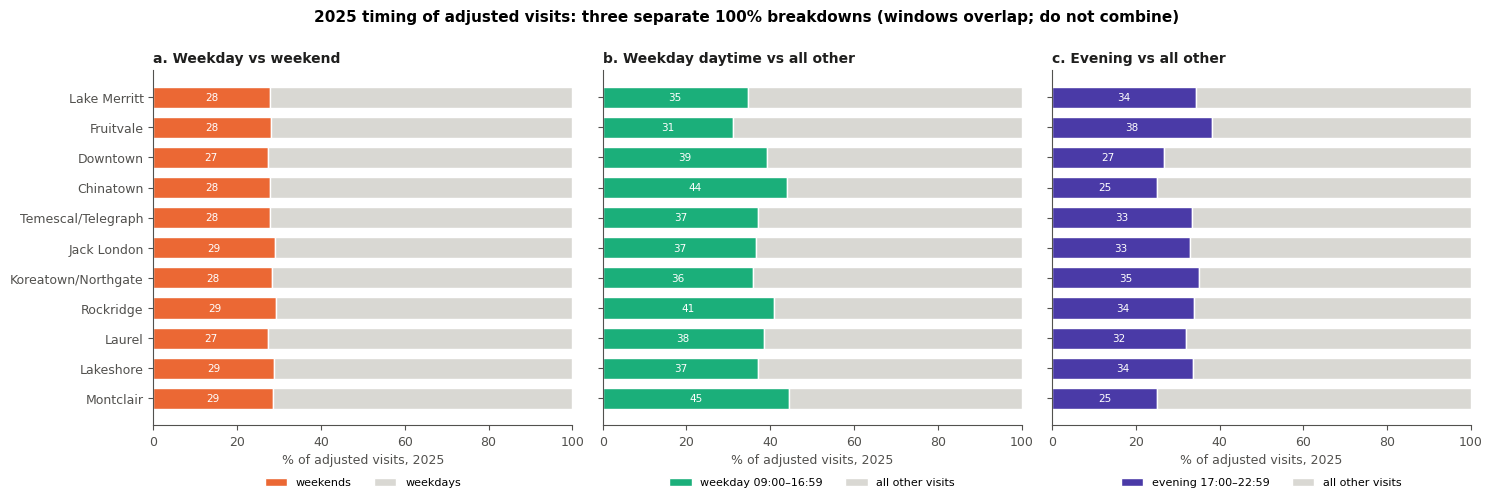

weekend % of visits                           weekday daytime %                           evening %                          
                                   2025 Δ pp 2019→22 Δ pp 2024→25              2025 Δ pp 2019→22 Δ pp 2024→25      2025 Δ pp 2019→22 Δ pp 2024→25
corridor_name                                                                                                                                    
Lake Merritt                      27.90         7.20         0.60             34.60       -10.30        -1.30     34.20         7.10         3.90
Fruitvale                         28.10         0.50        -0.30             31.00        -0.30         1.40     38.30        -0.10         2.40
Downtown                          27.40         7.20        -0.20             39.10       -13.10         1.10     26.70         7.20         0.60
Chinatown                         27.80         2.50        -0.30             43.90         0.10        -0.60     25.00        -3.70         1.80
Temescal/Telegraph                27.80         1.20         0.20             37.20        -0.60        -0.00     33.40         1.90         0.10
Jack London                       29.10        -0.40        -0.90             36.60         1.00         1.60     33.00         0.10        -0.20
Koreatown/Northgate               28.30         2.20        -0.00             36.00        -3.00         2.10     35.00         2.00         1.40
Rockridge                         29.40         2.40        -0.20             40.80         1.00         0.90     33.90        -2.30        -0.90
Laurel                            27.50        -0.70        -0.40             38.40        -0.20         0.80     32.00         1.90        -0.50
Lakeshore                         28.90        -3.50         0.00             37.10         1.70         0.40     33.70        -2.60         0.00
Montclair                         28.60        -1.90        -0.50             44.50         2.90        -0.20     25.00        -4.00         0.00

Levels in 2019 and 2022 (LIMA) for reference:


2019                    2022                
                    weekend daytime evening weekend daytime evening
corridor_name                                                      
Lake Merritt          16.60   56.30   23.40   23.80   46.10   30.50
Fruitvale             28.00   46.00   27.20   28.40   45.70   27.10
Downtown              15.20   60.10   18.30   22.50   47.00   25.50
Chinatown             25.30   50.90   21.90   27.90   51.10   18.20
Temescal/Telegraph    25.40   43.80   30.00   26.70   43.20   31.80
Jack London           29.80   40.70   31.00   29.40   41.80   31.10
Koreatown/Northgate   25.90   44.70   30.30   28.10   41.70   32.30
Rockridge             28.20   41.20   34.50   30.60   42.10   32.10
Laurel                25.90   41.40   29.40   25.20   41.20   31.40
Lakeshore             31.90   40.30   29.70   28.40   42.00   27.10
Montclair             28.90   44.80   25.30   27.00   47.70   21.30

In [19]:
def period_visits(year, months=range(1, 13)):
    d = stops[(stops.year == year) & stops.month.isin(list(months))]
    return d.pivot_table(index='corridor_name', columns='time_period', values='adjusted_known_home_visits', aggfunc='sum').reindex(CORRIDORS)
def timing_shares(year, months=range(1, 13)):
    p = period_visits(year, months)
    return pd.DataFrame({'weekend': 100 * p.weekends / p['all'], 'daytime': 100 * p['nine-five'] / p['all'], 'evening': 100 * p.evening / p['all']})
TS = {y: timing_shares(y) for y in (2019, 2022, 2024, 2025)}
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True); y = np.arange(len(CORRIDORS))[::-1]
for ax, (key, c1, l1, l2, ttl) in zip(axes, [('weekend', C_ORANGE, 'weekends', 'weekdays', 'a. Weekday vs weekend'), ('daytime', C_AQUA, 'weekday 09:00–16:59', 'all other visits', 'b. Weekday daytime vs all other'),
                                            ('evening', C_VIOLET, 'evening 17:00–22:59', 'all other visits', 'c. Evening vs all other')]):
    v = TS[2025][key].reindex(CORRIDORS); ax.barh(y, v, color=c1, height=0.7, edgecolor='white', label=l1); ax.barh(y, 100 - v, left=v, color='#d9d8d3', height=0.7, edgecolor='white', label=l2)
    for yi, vi in zip(y, v): ax.text(vi / 2, yi, f'{vi:.0f}', ha='center', va='center', fontsize=7.5, color='white')
    ax.set_xlim(0, 100); ax.set_xlabel('% of adjusted visits, 2025'); ax.set_title(ttl, loc='left'); ax.grid(False); ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
axes[0].set_yticks(y); axes[0].set_yticklabels(CORRIDORS); fig.suptitle('2025 timing of adjusted visits: three separate 100% breakdowns (windows overlap; do not combine)', fontsize=11, fontweight='bold', y=1.0); plt.tight_layout(); plt.show()
tt = pd.concat({'weekend % of visits': pd.DataFrame({'2025': TS[2025].weekend, 'Δ pp 2019→22': TS[2022].weekend - TS[2019].weekend, 'Δ pp 2024→25': TS[2025].weekend - TS[2024].weekend}),
                'weekday daytime %': pd.DataFrame({'2025': TS[2025].daytime, 'Δ pp 2019→22': TS[2022].daytime - TS[2019].daytime, 'Δ pp 2024→25': TS[2025].daytime - TS[2024].daytime}),
                'evening %': pd.DataFrame({'2025': TS[2025].evening, 'Δ pp 2019→22': TS[2022].evening - TS[2019].evening, 'Δ pp 2024→25': TS[2025].evening - TS[2024].evening})}, axis=1)
display(tt.round(1)); print('Levels in 2019 and 2022 (LIMA) for reference:'); display(pd.concat({y: TS[y] for y in (2019, 2022)}, axis=1).round(1))

**Takeaways: timing of adjusted visits**
- **2025 (PAPA).** The weekend share of visits is 27–29% in every corridor (Downtown 27.4% to Rockridge 29.4%), close to what an even week would give (2/7 ≈ 28.6%); no corridor is weekday-dominated. Weekday daytime (09:00–16:59) accounts for 44–45% of visits in Montclair and Chinatown but only 31% in Fruitvale and 35% in Lake Merritt; evening visits (17:00–22:59) are 38% in Fruitvale, 35% in Koreatown/Northgate and 34% in Lake Merritt, against 25% in Chinatown and Montclair and 27% in Downtown.
- **LIMA 2019 → 2022.** The central corridors changed most: **Downtown's weekend share rose from 15.2% to 22.5% and its daytime share fell from 60.1% to 47.0%; Lake Merritt's weekend share rose from 16.6% to 23.8% and its daytime share fell from 56.3% to 46.1%**; evening shares rose by about 7 points in both. Chinatown moved less (weekend +2.5 points, daytime +0.1, evening −3.7). The other corridors changed by 4 points or less. These were weekday- and daytime-oriented corridors in 2019 that lost that profile.
- **PAPA 2024 → 2025.** Weekend shares moved by at most 0.9 points and daytime shares by at most 2.1. Evening share rose in Lake Merritt (+3.9), Fruitvale (+2.4), Chinatown (+1.8) and Koreatown/Northgate (+1.4), and was within ±1 elsewhere.
- Shares are of **visits**, which are additive; the three breakdowns use overlapping windows and cannot be combined.

### 6.2 Recovery and change by timing window
The same adjusted measures by window: LIMA 2022 ÷ 2019 annual level and PAPA 2025 vs 2024 (full year). Windows overlap, so they are compared side by side, not added.

LIMA: adjusted visits 2022 ÷ 2019 by window


,Weekdays,Weekends,Weekday daytime (09:00–16:59),"Evening, every day (17:00–22:59)"
corridor_name,,,,
Lake Merritt,0.52,0.82,0.47,0.75
Downtown,0.57,0.92,0.48,0.87
Chinatown,0.63,0.72,0.66,0.55
Montclair,0.75,0.69,0.78,0.62
Koreatown/Northgate,0.72,0.80,0.69,0.79
Rockridge,0.73,0.82,0.78,0.71
Jack London,0.78,0.77,0.80,0.78
Lakeshore,0.89,0.75,0.88,0.77
Temescal/Telegraph,0.85,0.91,0.85,0.92


PAPA: % change in adjusted visits, 2025 vs 2024, full year (left) and Jan–Nov (right)


full year                                                                          Jan–Nov                                                                        
                     Weekdays Weekends Weekday daytime (09:00–16:59) Evening, every day (17:00–22:59) Weekdays Weekends Weekday daytime (09:00–16:59) Evening, every day (17:00–22:59)
corridor_name                                                                                                                                                                         
Lake Merritt            10.70    14.00                          7.50                            26.10    11.50    18.20                          7.70                            27.30
Fruitvale                4.60     3.00                          9.10                            11.10     5.80     5.50                          9.60                            12.50
Downtown                -0.80    -1.70                          1.70                             1.20     0.70     3.50                          3.30                             2.80
Chinatown               13.30    11.90                         11.30                            21.70    16.10    17.40                         13.70                            24.40
Temescal/Telegraph       6.60     7.50                          6.80                             7.30     8.10    11.50                          7.70                             9.40
Jack London              4.10    -0.40                          7.30                             2.10     4.10     1.40                          7.00                             2.00
Koreatown/Northgate     15.40    15.20                         22.60                            20.20    16.50    18.50                         22.80                            21.90
Rockridge                3.20     2.10                          5.10                             0.20     4.70     6.10                          6.80                             2.00
Laurel                   3.20     1.00                          4.70                             1.10     4.20     5.50                          5.50                             3.00
Lakeshore               -3.20    -3.20                         -2.20                            -3.10    -2.10     1.20                         -1.00                            -1.20
Montclair                7.80     5.00                          6.50                             7.20    10.70    10.10                          9.10                             9.90

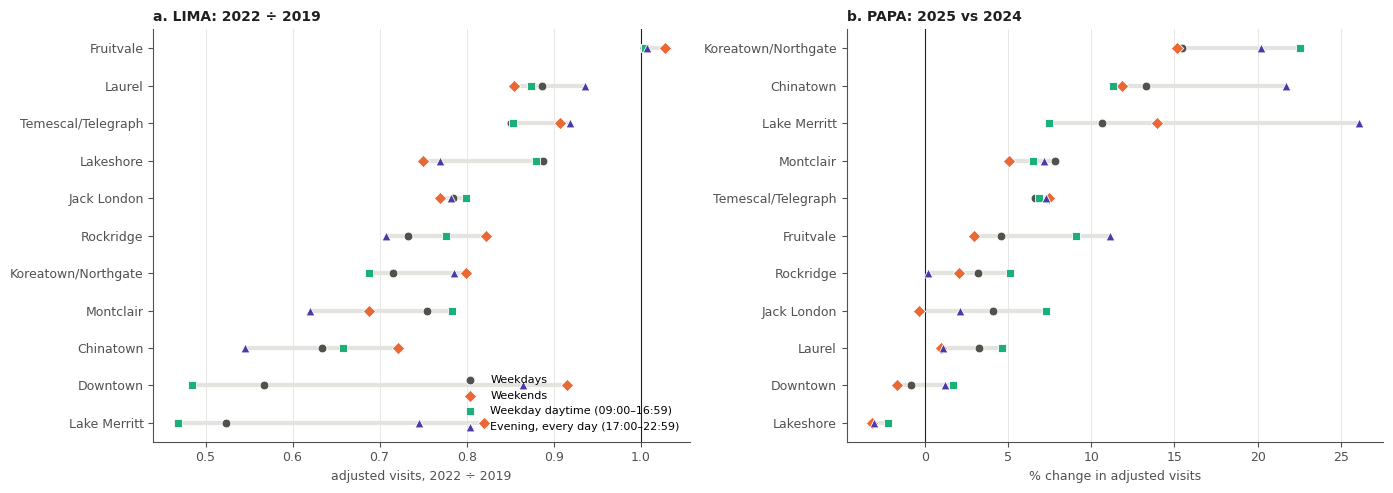

In [20]:
def window_ratio(period, y0, y1, months=range(1, 13)):
    s = stops[(stops.time_period == period) & stops.year.isin([y0, y1]) & stops.month.isin(list(months))].groupby(['corridor_name', 'year']).adjusted_known_home_visits.sum().unstack()
    return (s[y1] / s[y0]).reindex(CORRIDORS)
LIMA_W = pd.DataFrame({PERIOD_LABEL[p]: window_ratio(p, 2019, 2022) for p in WIN}); PAPA_W = pd.DataFrame({PERIOD_LABEL[p]: pct_change(1, window_ratio(p, 2024, 2025)) for p in WIN})
PAPA_WJN = pd.DataFrame({PERIOD_LABEL[p]: pct_change(1, window_ratio(p, 2024, 2025, JAN_NOV)) for p in WIN})
print('LIMA: adjusted visits 2022 ÷ 2019 by window'); display(LIMA_W.round(2).loc[L['visits'][1][2022].sort_values().index])
print('PAPA: % change in adjusted visits, 2025 vs 2024, full year (left) and Jan–Nov (right)'); display(pd.concat({'full year': PAPA_W, 'Jan–Nov': PAPA_WJN}, axis=1).round(1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (tab, order, ttl, ref, xl) in zip(axes, [(LIMA_W, L['visits'][1][2022].sort_values().index.tolist(), 'a. LIMA: 2022 ÷ 2019', 1, 'adjusted visits, 2022 ÷ 2019'), (PAPA_W, papa_tbl['visits Δ%, full year'].sort_values().index.tolist(), 'b. PAPA: 2025 vs 2024', 0, '% change in adjusted visits')]):
    y = np.arange(len(order)); ax.hlines(y, tab.loc[order].min(axis=1), tab.loc[order].max(axis=1), color=GRID, lw=3, zorder=1)
    for p, (col, mk) in WIN_STYLE.items(): ax.scatter(tab.loc[order, PERIOD_LABEL[p]], y, s=40, color=col, marker=mk, zorder=3, label=PERIOD_LABEL[p], edgecolor='white', lw=0.6)
    ax.axvline(ref, color=INK, lw=0.8); ax.set_yticks(y); ax.set_yticklabels(order); ax.grid(axis='y', visible=False); ax.set_title(ttl, loc='left'); ax.set_xlabel(xl)
axes[0].legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

**Takeaways: recovery and change by timing window (adjusted visits)**
- **LIMA.** Weekday daytime visits recovered least in the lagging central corridors: 2022 ÷ 2019 of 0.47 in Lake Merritt, 0.48 in Downtown and 0.66 in Chinatown (weekday totals 0.52, 0.57, 0.63), while their weekend visits stood at 0.82, 0.92 and 0.72 and their evening visits at 0.75, 0.87 and 0.55. The weakness is therefore specific to weekday daytime in Lake Merritt and Downtown, and to evenings and weekends in Chinatown. Fruitvale was back at about 1.0 in every window; Temescal/Telegraph and Laurel at 0.85–0.94.
- **PAPA, full year.** Growth was strongest in evenings: Lake Merritt +26.1% (weekday daytime +7.5%), Chinatown +21.7% (daytime +11.3%), Koreatown/Northgate +20.2% (daytime +22.6%) and Fruitvale +11.1%. Weekday and weekend changes are similar (Koreatown/Northgate +15.4% and +15.2%; Chinatown +13.3% and +11.9%), except Jack London (+4.1% and −0.4%). Excluding December makes evening growth larger (Lake Merritt +27.3%, Chinatown +24.4%).
- **Together with section 4:** the corridors that struggled to recover in LIMA lost weekday daytime and non-Oakland visits; the 2025 gains in the same corridors are concentrated in evenings and in Oakland-origin visits. Both are associations from separate eras and panels.

### 6.3 Seasonality
Sum of the 11 corridors (overlaps not removed), adjusted measures, indexed to each year's own mean so only within-year shape shows. **Visits are normalized per calendar day** (adjusted visits ÷ days in the month) so that February is not penalized for its length; this is *per-day intensity*, distinct from the *monthly totals* used in sections 2–3. **Monthly unique devices are not day-normalized**: they count distinct devices over the whole month and so rise mechanically a little with month length. 2020–2021 are omitted (pandemic disruption), SIERRA is too small, and PAPA has only two complete years, so these are comparisons of individual years, not an established seasonal cycle.

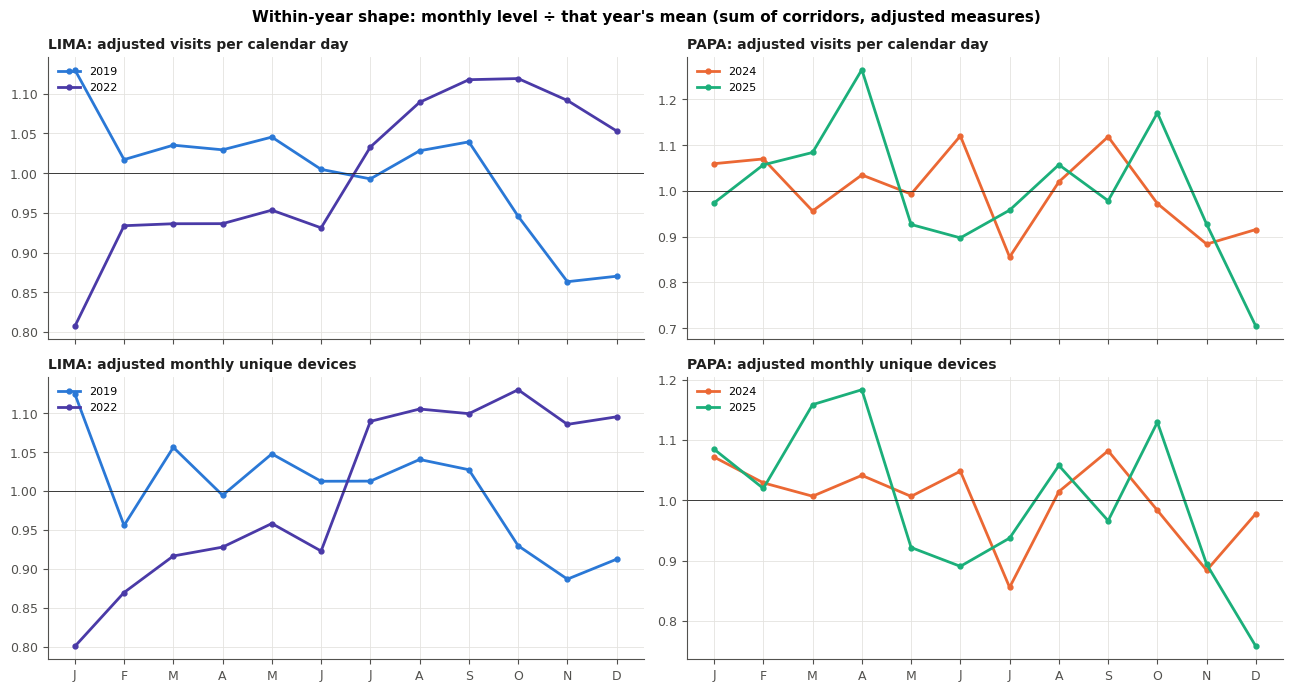

,provider,visits/day: peak month,trough month,peak ÷ trough,devices: peak month,trough month,peak ÷ trough
year,,,,,,,
2019,LIMA,1,11,1.31,1,11,1.27
2022,LIMA,10,1,1.39,10,1,1.41
2024,PAPA,6,7,1.31,9,7,1.26
2025,PAPA,4,12,1.80,4,12,1.56


In [21]:
cal = pd.DataFrame({'date': pd.date_range('2019-01-01', '2025-12-31')}); cal['year_month'] = cal.date.dt.year * 100 + cal.date.dt.month
cal = cal.groupby('year_month').size().rename('days')
sea = city.merge(cal, left_on='year_month', right_index=True); sea['visits_per_day'] = sea.adj_visits / sea.days
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for j, (prov, years) in enumerate([('LIMA', [2019, 2022]), ('PAPA', [2024, 2025])]):
    for i, (col, lab) in enumerate([('visits_per_day', 'adjusted visits per calendar day'), ('adj_devices', 'adjusted monthly unique devices')]):
        ax = axes[i, j]
        for yr in years:
            g = sea[sea.year == yr].sort_values('month'); ax.plot(g.month, g[col] / g[col].mean(), color=YEAR_COLOR[yr], lw=2, marker='o', ms=3.5, label=str(yr))
        ax.axhline(1, color=INK, lw=0.6); ax.set_title(f'{prov}: {lab}', loc='left'); ax.set_xticks(range(1, 13)); ax.set_xticklabels(list('JFMAMJJASOND')); ax.legend(fontsize=8, loc='upper left')
fig.suptitle("Within-year shape: monthly level ÷ that year's mean (sum of corridors, adjusted measures)", fontsize=11, fontweight='bold'); plt.tight_layout(); plt.show()
rows = []
for yr in (2019, 2022, 2024, 2025):
    g = sea[sea.year == yr]
    rows.append({'year': yr, 'provider': g.provider_id.iloc[0], 'visits/day: peak month': int(g.loc[g.visits_per_day.idxmax(), 'month']), 'trough month': int(g.loc[g.visits_per_day.idxmin(), 'month']), 'peak ÷ trough': g.visits_per_day.max() / g.visits_per_day.min(),
                 'devices: peak month': int(g.loc[g.adj_devices.idxmax(), 'month']), 'trough month ': int(g.loc[g.adj_devices.idxmin(), 'month']), 'peak ÷ trough ': g.adj_devices.max() / g.adj_devices.min()})
display(pd.DataFrame(rows).set_index('year').round(2))

**Takeaways: seasonality.** There is no consistent seasonal shape across years. The month with the most visits per day is January in 2019, October in 2022, June in 2024 and April in 2025, and the weakest month is November, January, July and December respectively. 2019 is partly shaped by the weights (the Bay HOME sample grew from 159 k in January to 235 k in December of the reference year, so January's weight is 1.32). The peak-to-trough range is 1.3–1.4× for visits per day in 2019, 2022 and 2024 and **1.8× in 2025**, driven by the April rise and the December fall; for monthly devices it is 1.3–1.4× and 1.6×. A single-year peak is not seasonality: only 2019 and 2024 are clean candidate years and they do not share a pattern, so none is claimed.

### 6.4 Repeat use
A *repeat device* has **at least two distinct visit dates in the corridor within a half-year**. The share is unweighted by construction; a common sample multiplier cancels in this percentage, so no sample-adjusted repeat share is invented. Identifiers reset at every half-year boundary: each point describes that half-year's devices only, and the lines do **not** follow the same people over time. Provider segments are drawn separately; SIERRA's single half is a lone, low-confidence point. Repeat visits are *recorded return visits*, not customer loyalty or business retention.

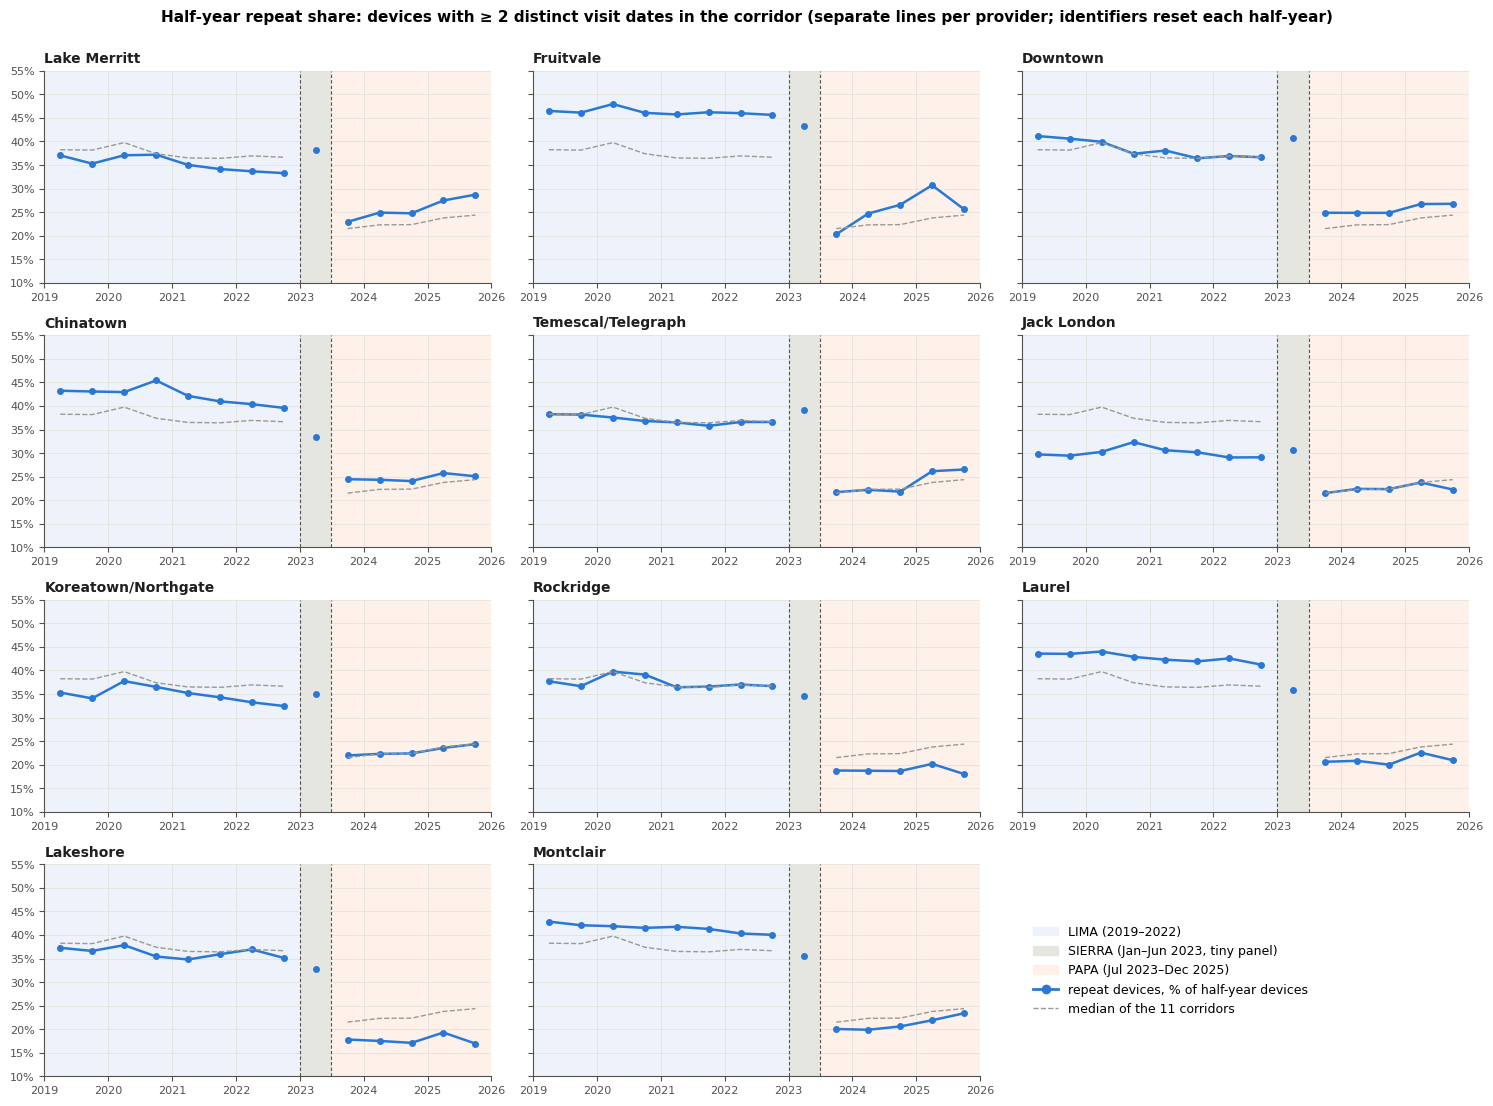

,H1 2019,H1 2022,Δ pp H1 2019→22,Δ pp H2 2019→22,H1 2024,H1 2025,Δ pp H1 2024→25,Δ pp H2 2024→25
corridor_name,,,,,,,,
Lake Merritt,37.00,33.70,-3.40,-2.00,24.90,27.50,2.60,4.00
Fruitvale,46.50,46.00,-0.50,-0.50,24.70,30.70,6.00,-1.00
Downtown,41.20,36.90,-4.20,-3.90,24.90,26.70,1.90,1.90
Chinatown,43.20,40.40,-2.80,-3.50,24.30,25.80,1.40,1.00
Temescal/Telegraph,38.20,36.60,-1.70,-1.60,22.20,26.10,3.90,4.70
Jack London,29.70,29.10,-0.60,-0.30,22.40,23.80,1.40,-0.10
Koreatown/Northgate,35.30,33.30,-2.10,-1.60,22.30,23.60,1.30,2.00
Rockridge,37.70,37.00,-0.70,0.00,18.70,20.20,1.50,-0.60
Laurel,43.60,42.60,-1.00,-2.30,20.80,22.60,1.70,0.90


Median change across corridors (pp): {'Δ pp H1 2019→22': -1.66, 'Δ pp H2 2019→22': -1.62, 'Δ pp H1 2024→25': 1.78, 'Δ pp H2 2024→25': 1.01}


In [22]:
rr = repeat[repeat.time_period == 'all'].copy()
rr['repeat_share'] = 100 * rr.repeat_device_prop; rr['multi_month_share'] = 100 * rr.devices_active_multiple_months / rr.unique_devices
rr['date'] = pd.to_datetime(rr.half_year.str[:4] + np.where(rr.half_year.str[-1] == '1', '-04-01', '-10-01'))
def rep_draw(ax, c):
    g = rr[rr.corridor_name == c].sort_values('date')
    segment_lines(ax, g, 'repeat_share', color=C_BLUE, lw=1.8, marker='o', ms=4)
    ax.set_ylim(10, 55)
fig, axes = plt.subplots(4, 3, figsize=(15, 11), sharey=True)
med = rr.groupby('date').repeat_share.median()
for ax, c in zip(axes.flat, CORRIDORS):
    shade_segments(ax); rep_draw(ax, c); ax.set_title(c, loc='left'); year_axis(ax); ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    for _, g in rr[rr.corridor_name == CORRIDORS[0]].groupby('provider_segment', sort=False): ax.plot(g.date, med.reindex(g.date).values, color=C_GRAY, lw=1, ls='--')
axes.flat[11].axis('off'); axes.flat[11].legend(handles=seg_legend + [Line2D([], [], color=C_BLUE, lw=2, marker='o', label='repeat devices, % of half-year devices'), Line2D([], [], color=C_GRAY, lw=1, ls='--', label='median of the 11 corridors')], loc='center left', fontsize=9)
fig.suptitle('Half-year repeat share: devices with ≥ 2 distinct visit dates in the corridor (separate lines per provider; identifiers reset each half-year)', fontsize=11, fontweight='bold', y=1.0); plt.tight_layout(); plt.show()

rs = rr.pivot_table(index='corridor_name', columns='half_year', values='repeat_share').reindex(CORRIDORS)
rep_tbl = pd.DataFrame({'H1 2019': rs['2019H1'], 'H1 2022': rs['2022H1'], 'Δ pp H1 2019→22': rs['2022H1'] - rs['2019H1'], 'Δ pp H2 2019→22': rs['2022H2'] - rs['2019H2'],
                        'H1 2024': rs['2024H1'], 'H1 2025': rs['2025H1'], 'Δ pp H1 2024→25': rs['2025H1'] - rs['2024H1'], 'Δ pp H2 2024→25': rs['2025H2'] - rs['2024H2']})
display(rep_tbl.round(1)); print('Median change across corridors (pp):', rep_tbl.filter(like='Δ').median().round(2).to_dict())

Repeat shares are most useful here where they help explain the trajectories. The like-for-like half-year changes are therefore related to the adjusted change in **visits per device** (frequency) and in visits within each provider; n = 11, so these are descriptive correlations.

In [23]:
def half_vpd(year, half):
    m = range(1, 7) if half == 1 else range(7, 13); d = act[(act.year == year) & act.month.isin(list(m))].groupby('corridor_name')[['adj_visits', 'adj_devices']].sum().reindex(CORRIDORS)
    return d.adj_visits / d.adj_devices, d.adj_visits
v0, a0 = half_vpd(2019, 1); v1, a1 = half_vpd(2022, 1); w0, b0 = half_vpd(2024, 1); w1, b1 = half_vpd(2025, 1)
link = pd.DataFrame({'LIMA: Δ repeat (pp) vs Δ% visits per device (H1 2019→22)': [spearmanr(rep_tbl['Δ pp H1 2019→22'], pct_change(v0, v1))[0]],
                     'LIMA: Δ repeat vs adjusted visits 2022÷2019 (H1)': [spearmanr(rep_tbl['Δ pp H1 2019→22'], a1 / a0)[0]],
                     'PAPA: Δ repeat (pp) vs Δ% visits per device (H1 2024→25)': [spearmanr(rep_tbl['Δ pp H1 2024→25'], pct_change(w0, w1))[0]],
                     'PAPA: Δ repeat vs Δ% adjusted visits (H1)': [spearmanr(rep_tbl['Δ pp H1 2024→25'], pct_change(b0, b1))[0]]}, index=['Spearman ρ'])
display(link.round(2).T)

,Spearman ρ
LIMA: Δ repeat (pp) vs Δ% visits per device (H1 2019→22),0.80
LIMA: Δ repeat vs adjusted visits 2022÷2019 (H1),0.78
PAPA: Δ repeat (pp) vs Δ% visits per device (H1 2024→25),0.49
PAPA: Δ repeat vs Δ% adjusted visits (H1),0.22


**Takeaways: repeat use**
- **LIMA: repeat use fell in every corridor, most where recovery was weakest.** H1 repeat shares were 30–47% in 2019 and 29–46% in 2022; the change from H1 2019 to H1 2022 was negative in all 11 corridors (median −1.7 points), largest in Downtown (−4.2), Lake Merritt (−3.4) and Chinatown (−2.8), and near zero in Fruitvale (−0.5), Jack London (−0.6), Rockridge (−0.7) and Lakeshore (−0.3). Across corridors the change in repeat share tracks both the change in visits per device (ρ = 0.80) and the recovery of adjusted visits (ρ = 0.78).
- **PAPA: repeat use rose in every corridor** (H1 2024 → H1 2025: +1.3 to +6.0 points, median +1.8; H2: −1.0 to +4.7, median +1.0). Fruitvale (+6.0, 24.7% → 30.7%), Temescal/Telegraph (+3.9) and Lake Merritt (+2.6) rose most. The relation with the change in visits per device is moderate (ρ = 0.49) and with adjusted visits weak (ρ = 0.22), and the rise coincides with the panel-wide 2025 frequency step (section 7.2).
- **Levels are not comparable across providers** (LIMA 29–47% vs PAPA 17–31%): identifiers, device recording frequency and panel differ. All of this is recorded return visits within a half-year, not customer loyalty or business retention.

## 7. Focused robustness
This section tests the main findings against the concerns most likely to change them and sorts what it finds into four kinds: **confirmed errors**, **methodological limitations**, **unverified coverage**, and **unusual but potentially real patterns**. Raw measures appear here only as diagnostics. The adjusted measures stay primary even though some CBG weights use the Bay-wide fallback: the fallback is a documented design choice, not an error, and the comparison with the common-scale measure B below shows how much it matters.

### 7.1 December 2025 and the choice of window

,"adjusted visits, Dec 2025 ÷ Dec 2024","adjusted devices, Dec 2025 ÷ Dec 2024","adjusted visits, Dec ÷ Nov 2025","adjusted visits, Dec ÷ Nov 2024","adjusted visits, Dec ÷ Nov 2023","raw visits (diagnostic), Dec 2025 ÷ Dec 2024"
corridor_name,,,,,,
Lake Merritt,0.89,0.87,0.82,1.04,0.95,0.95
Fruitvale,0.81,0.67,0.74,0.81,1.00,0.65
Downtown,0.70,0.66,0.69,1.15,0.92,0.63
Chinatown,0.74,0.71,0.69,1.18,0.97,0.70
Temescal/Telegraph,0.82,0.76,0.83,1.17,1.00,0.85
Jack London,0.96,0.85,0.96,1.09,0.90,0.98
Koreatown/Northgate,0.96,0.83,0.82,1.16,0.97,1.03
Rockridge,0.77,0.76,0.77,1.16,0.92,0.75
Laurel,0.82,0.80,0.89,1.25,0.95,0.77


Bay HOME sample: Dec 2025 ÷ Dec 2024 = 1.14; Dec ÷ Nov 2025 = 0.90. Adjusted visits below December 2024 in 11 of 11 corridors, adjusted devices in 11 of 11.
Excluding December moves adjusted visits changes by +0.6 to +3.6 points and devices changes by +0.8 to +3.2; signs flip in 1 corridor(s) for visits (Downtown) and 1 for devices.


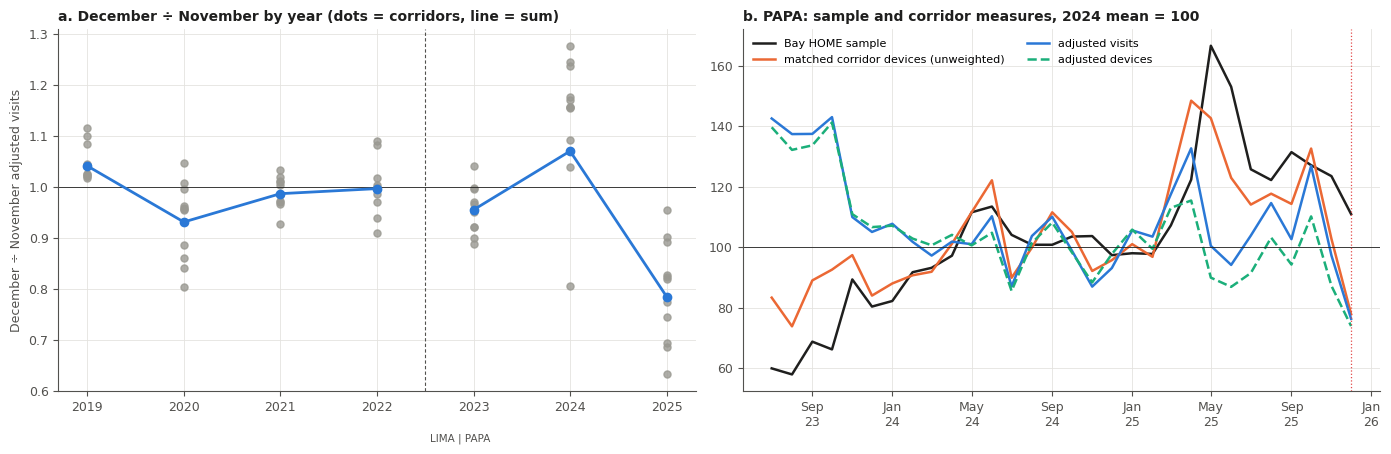

In [24]:
def ratio_between(col, y1, m1, y0, m0):
    p = act.pivot_table(index='corridor_name', columns='year_month', values=col)
    return (p[y1 * 100 + m1] / p[y0 * 100 + m0]).reindex(CORRIDORS)
dec = pd.DataFrame({'adjusted visits, Dec 2025 ÷ Dec 2024': ratio_between('adj_visits', 2025, 12, 2024, 12), 'adjusted devices, Dec 2025 ÷ Dec 2024': ratio_between('adj_devices', 2025, 12, 2024, 12),
                    'adjusted visits, Dec ÷ Nov 2025': ratio_between('adj_visits', 2025, 12, 2025, 11), 'adjusted visits, Dec ÷ Nov 2024': ratio_between('adj_visits', 2024, 12, 2024, 11),
                    'adjusted visits, Dec ÷ Nov 2023': ratio_between('adj_visits', 2023, 12, 2023, 11), 'raw visits (diagnostic), Dec 2025 ÷ Dec 2024': ratio_between('visit_count', 2025, 12, 2024, 12)})
cm = city.set_index('year_month'); bs = denoms.set_index('year_month').bay_home_sample
dec.loc['Sum of 11 corridors'] = [cm.adj_visits[202512] / cm.adj_visits[202412], cm.adj_devices[202512] / cm.adj_devices[202412], cm.adj_visits[202512] / cm.adj_visits[202511],
                                  cm.adj_visits[202412] / cm.adj_visits[202411], cm.adj_visits[202312] / cm.adj_visits[202311], cm.visits[202512] / cm.visits[202412]]
display(dec.round(2))
print(f'Bay HOME sample: Dec 2025 ÷ Dec 2024 = {bs[202512] / bs[202412]:.2f}; Dec ÷ Nov 2025 = {bs[202512] / bs[202511]:.2f}. Adjusted visits below December 2024 in {int((dec.iloc[:-1, 0] < 1).sum())} of 11 corridors, adjusted devices in {int((dec.iloc[:-1, 1] < 1).sum())} of 11.')
fl = pd.DataFrame({'full-year Δ% visits': papa_tbl['visits Δ%, full year'], 'Jan–Nov Δ% visits': papa_tbl['visits Δ%, Jan–Nov'], 'full-year Δ% devices': papa_tbl['devices Δ%, full year'], 'Jan–Nov Δ% devices': papa_tbl['devices Δ%, Jan–Nov']})
print(f'Excluding December moves adjusted visits changes by +{(fl.iloc[:, 1] - fl.iloc[:, 0]).min():.1f} to +{(fl.iloc[:, 1] - fl.iloc[:, 0]).max():.1f} points and devices changes by +{(fl.iloc[:, 3] - fl.iloc[:, 2]).min():.1f} to +{(fl.iloc[:, 3] - fl.iloc[:, 2]).max():.1f}; '
      f'signs flip in {int(((fl.iloc[:, 0] > 0) != (fl.iloc[:, 1] > 0)).sum())} corridor(s) for visits ({", ".join(fl.index[(fl.iloc[:, 0] > 0) != (fl.iloc[:, 1] > 0)]) or "none"}) and {int(((fl.iloc[:, 2] > 0) != (fl.iloc[:, 3] > 0)).sum())} for devices.')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]; dn = act.pivot_table(index=['corridor_name', 'year'], columns='month', values='adj_visits'); r_dn = (dn[12] / dn[11]).unstack().reindex(CORRIDORS)
for yr in r_dn.columns: ax.scatter([yr] * len(r_dn), r_dn[yr], s=26, color=C_GRAY, alpha=0.8, zorder=2)
cy = city.pivot_table(index='year', columns='month', values='adj_visits'); dn_c = cy[12] / cy[11]
for yrs in ([2019, 2020, 2021, 2022], [2023, 2024, 2025]): ax.plot(yrs, dn_c.loc[yrs], color=C_BLUE, lw=2, marker='o', zorder=3)
ax.axvline(2022.5, color=INK_2, lw=0.8, ls=(0, (3, 2))); ax.text(2022.55, 0.5, 'LIMA | PAPA', fontsize=7.5, color=INK_2); ax.axhline(1, color=INK, lw=0.6)
ax.set_xticks(range(2019, 2026)); ax.set_ylabel('December ÷ November adjusted visits'); ax.set_title('a. December ÷ November by year (dots = corridors, line = sum)', loc='left')
ax = axes[1]; g = city[city.provider_id == 'PAPA']; b24 = city[city.year == 2024]
for col, lab, color, ls in [('bay_home_sample', 'Bay HOME sample', INK, '-'), ('matched_devices', 'matched corridor devices (unweighted)', C_ORANGE, '-'), ('adj_visits', 'adjusted visits', C_BLUE, '-'), ('adj_devices', 'adjusted devices', C_AQUA, '--')]:
    ax.plot(g.date, 100 * g[col] / b24[col].mean(), color=color, lw=1.8, ls=ls, label=lab)
ax.axhline(100, color=INK, lw=0.6); ax.axvline(pd.Timestamp('2025-12-01'), color=C_RED, lw=0.9, ls=':'); ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.set_title('b. PAPA: sample and corridor measures, 2024 mean = 100', loc='left'); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
plt.tight_layout(); plt.show()

### 7.2 The April–November 2025 visits-per-device shift
Raw visits per device-month rose across most corridors from April 2025. Whether the shift survives adjustment tells us whether it is a feature of the panel (and so also of the adjusted frequency measure) or of the weights.

raw visits per device (diagnostic)                                                           adjusted visits per adjusted device                                            \
                                                  2024 Apr–Nov 2025 Dec 2025 Apr–Nov vs 2024 (%) Dec vs 2024 (%)                                2024 Apr–Nov 2025 Dec 2025 Apr–Nov vs 2024 (%)   
corridor_name                                                                                                                                                                                    
Lake Merritt                                      1.42         1.64     1.39               15.51           -2.19                                1.63         1.90     1.59               16.31   
Fruitvale                                         1.38         1.51     1.39                9.09            0.76                                1.56         1.76     1.64               12.46   
Downtown                                          1.40         1.52     1.44                8.32            2.56                                1.60         1.75     1.64                9.62   
Chinatown                                         1.45         1.56     1.48                7.89            2.57                                1.64         1.82     1.68               10.79   
Temescal/Telegraph                                1.36         1.66     1.44               21.50            5.81                                1.52         1.74     1.61               14.33   
Jack London                                       1.37         1.49     1.44                8.67            5.20                                1.52         1.70     1.65               12.21   
Koreatown/Northgate                               1.36         1.51     1.46               11.03            7.76                                1.49         1.72     1.64               15.33   
Rockridge                                         1.28         1.34     1.29                4.05            0.28                                1.39         1.46     1.37                5.04   
Laurel                                            1.31         1.37     1.33                4.63            1.59                                1.42         1.48     1.44                4.78   
Lakeshore                                         1.26         1.29     1.25                2.57           -0.54                                1.37         1.39     1.33                1.21   
Montclair                                         1.31         1.43     1.30                8.64           -1.28                                1.41         1.50     1.36                6.43   

                                     
                    Dec vs 2024 (%)  
corridor_name                        
Lake Merritt                  -2.35  
Fruitvale                      5.01  
Downtown                       2.80  
Chinatown                      2.40  
Temescal/Telegraph             5.83  
Jack London                    8.92  
Koreatown/Northgate           10.46  
Rockridge                     -0.82  
Laurel                         1.43  
Lakeshore                     -3.29  
Montclair                     -3.48

Sum of corridors: raw visits per device 1.39 → 1.54 (Apr–Nov 2025); adjusted 1.55 → 1.74. Corridors up by more than 5% (Apr–Nov 2025 vs 2024): raw 8 of 11, adjusted 9 of 11.


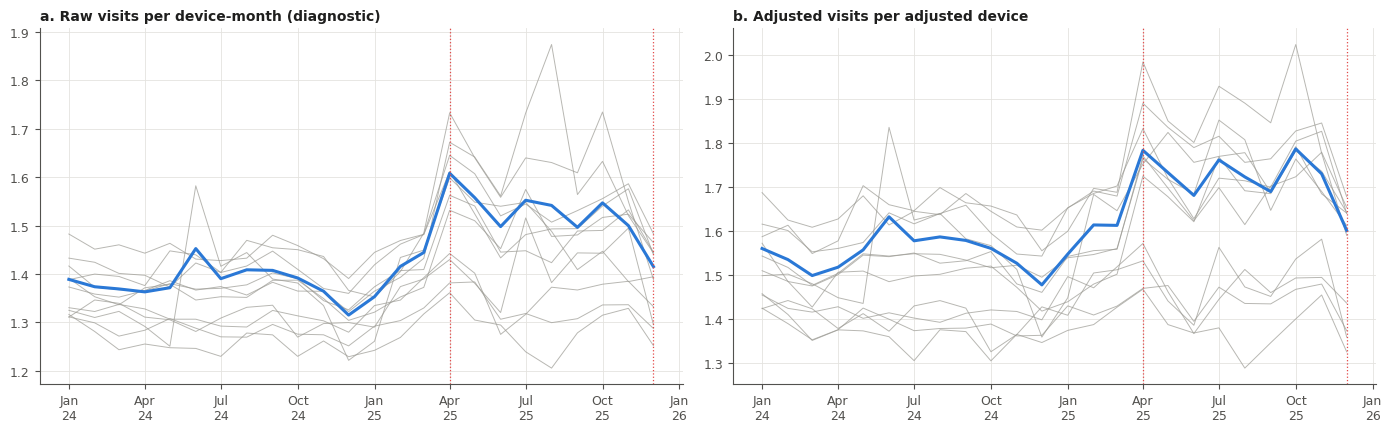

In [25]:
pm = act[(act.provider_id == 'PAPA') & (act.year >= 2024)]
def vpd_period(d, kind):
    return d.groupby('corridor_name').apply(lambda x: x.visit_count.sum() / x.unique_devices.sum() if kind == 'raw' else x.adj_visits.sum() / x.adj_devices.sum())
rows = {}
for kind in ('raw', 'adj'):
    a = vpd_period(pm[pm.year == 2024], kind); b = vpd_period(pm[(pm.year == 2025) & pm.month.between(4, 11)], kind); c = vpd_period(pm[(pm.year == 2025) & (pm.month == 12)], kind)
    rows[kind] = pd.DataFrame({'2024': a, 'Apr–Nov 2025': b, 'Dec 2025': c, 'Apr–Nov vs 2024 (%)': pct_change(a, b), 'Dec vs 2024 (%)': pct_change(a, c)}).reindex(CORRIDORS)
vs = pd.concat({'raw visits per device (diagnostic)': rows['raw'], 'adjusted visits per adjusted device': rows['adj']}, axis=1)
display(vs.round(2))
cityv = {k: (pm[pm.year == 2024].pipe(lambda d: d.visit_count.sum() / d.unique_devices.sum() if k == 'raw' else d.adj_visits.sum() / d.adj_devices.sum()),
             pm[(pm.year == 2025) & pm.month.between(4, 11)].pipe(lambda d: d.visit_count.sum() / d.unique_devices.sum() if k == 'raw' else d.adj_visits.sum() / d.adj_devices.sum())) for k in ('raw', 'adj')}
print(f'Sum of corridors: raw visits per device {cityv["raw"][0]:.2f} → {cityv["raw"][1]:.2f} (Apr–Nov 2025); adjusted {cityv["adj"][0]:.2f} → {cityv["adj"][1]:.2f}. '
      f'Corridors up by more than 5% (Apr–Nov 2025 vs 2024): raw {int((rows["raw"]["Apr–Nov vs 2024 (%)"] > 5).sum())} of 11, adjusted {int((rows["adj"]["Apr–Nov vs 2024 (%)"] > 5).sum())} of 11.')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=False)
for ax, (kind, col, ttl) in zip(axes, [('raw', 'visits_per_unique_device', 'a. Raw visits per device-month (diagnostic)'), ('adj', 'adj_visits_per_device', 'b. Adjusted visits per adjusted device')]):
    for c in CORRIDORS: ax.plot(pm[pm.corridor_name == c].date, pm[pm.corridor_name == c][col], color=C_GRAY, lw=0.7, alpha=0.7)
    cc = pm.groupby('date').apply(lambda x: x.visit_count.sum() / x.unique_devices.sum() if kind == 'raw' else x.adj_visits.sum() / x.adj_devices.sum()); ax.plot(cc.index, cc.values, color=C_BLUE, lw=2.2)
    for d in ('2025-04-01', '2025-12-01'): ax.axvline(pd.Timestamp(d), color=C_RED, lw=0.9, ls=':')
    ax.set_title(ttl, loc='left'); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))
plt.tight_layout(); plt.show()

### 7.3 Early-2023 SIERRA sample and the common-scale factor

In [26]:
sierra = act[act.provider_id == 'SIERRA']
sr = sierra.groupby('corridor_name').agg(median_devices=('unique_devices', 'median'), median_matched_devices=('home_matched_devices', 'median'), min_matched_devices=('home_matched_devices', 'min'),
         thin_months=('home_matched_devices', lambda s: int((s < MIN_TREND_DEVICES).sum()))).reindex(CORRIDORS)
display(sr)
print(f'SIERRA Bay HOME sample: {denoms[denoms.provider_id == "SIERRA"].bay_home_sample.max():,.0f} (Jan 2023) → {denoms[denoms.provider_id == "SIERRA"].bay_home_sample.min():,.0f} (Jun 2023), against {mean_2019_sample:,.0f} in the 2019 reference. '
      f'The common factor therefore runs {denoms[denoms.provider_id == "SIERRA"].common_scale_factor.min():.1f}× to {denoms[denoms.provider_id == "SIERRA"].common_scale_factor.max():.1f}×, multiplying a few dozen matched devices per corridor-month by 10–16: standardized SIERRA values are visible in the figures but are noise-dominated, '
      f'and {int((sierra.home_matched_devices < MIN_TREND_DEVICES).sum())} of 66 corridor-months have under {MIN_TREND_DEVICES} matched devices. SIERRA is excluded from every statistic in this notebook.')

,median_devices,median_matched_devices,min_matched_devices,thin_months
corridor_name,,,,
Lake Merritt,275.50,217.50,182,0
Fruitvale,156.00,130.50,121,0
Downtown,249.50,169.00,143,0
Chinatown,175.50,130.00,113,0
Temescal/Telegraph,247.00,193.50,164,0
Jack London,226.50,152.50,136,0
Koreatown/Northgate,143.00,110.50,97,1
Rockridge,117.00,91.50,82,6
Laurel,68.50,59.00,40,6


SIERRA Bay HOME sample: 20,217 (Jan 2023) → 12,947 (Jun 2023), against 211,000 in the 2019 reference. The common factor therefore runs 10.4× to 16.3×, multiplying a few dozen matched devices per corridor-month by 10–16: standardized SIERRA values are visible in the figures but are noise-dominated, and 25 of 66 corridor-months have under 100 matched devices. SIERRA is excluded from every statistic in this notebook.


### 7.4 Spikes (Fruitvale and others)
Months whose raw visits are at least 1.4× (or at most 1/1.4×) the median of the four nearest months in the same provider segment are flagged, excluding the expected Mar–Jun 2020 collapse. Raw counts are used only to *detect* spikes; the adjusted ratio and the matched/unmatched split show whether the adjusted measure inherits them.

In [27]:
def nb_ratio_series(g, col):
    g = g.sort_values('year_month'); v = g[col].to_numpy(dtype=float); out = np.full(len(v), np.nan)
    for i in range(len(v)):
        nb = [v[j] for j in (i - 2, i - 1, i + 1, i + 2) if 0 <= j < len(v)]
        if len(nb) >= 2: out[i] = v[i] / np.median(nb)
    return pd.Series(out, index=g.index)
for col, name in [('visit_count', 'nb_raw'), ('adj_visits', 'nb_adj'), ('home_matched_visits', 'nb_matched'), ('unmatched_visits', 'nb_unmatched')]:
    act[name] = np.nan
    for _, g in act.groupby(['corridor_name', 'provider_segment']): act.loc[g.index, name] = nb_ratio_series(g, col)
sp = act[((act.nb_raw >= SPIKE_RATIO) | (act.nb_raw <= 1 / SPIKE_RATIO)) & ~act.year_month.isin([202003, 202004, 202005, 202006])]
spike_tbl = sp[['corridor_name', 'year_month', 'provider_id', 'nb_raw', 'nb_adj', 'nb_matched', 'nb_unmatched', 'home_match_rate']].sort_values(['provider_id', 'year_month', 'corridor_name'])
spike_tbl.columns = ['corridor', 'month', 'provider', 'raw ÷ neighbours', 'adjusted ÷ neighbours', 'matched (unweighted) ÷ neighbours', 'unmatched ÷ neighbours', 'HOME-match rate']
non_dec = spike_tbl[spike_tbl.month != 202512]
print(f'{len(spike_tbl)} flagged corridor-months; {int((spike_tbl.month == 202512).sum())} are December 2025 (see 7.1). Others:'); display(non_dec.round(2).reset_index(drop=True))
fv = act[(act.corridor_name == 'Fruitvale') & (act.provider_id == 'PAPA')]
print(f'Fruitvale adjusted visits: H2 2023 mean (Jul–Dec) {fv[fv.year == 2023].adj_visits.mean():,.0f}; 2024 {fv[fv.year == 2024].adj_visits.mean():,.0f}; 2025 {fv[fv.year == 2025].adj_visits.mean():,.0f}. Median Fruitvale adjusted ÷ raw-neighbour ratio in flagged months: {non_dec[non_dec.corridor == "Fruitvale"]["adjusted ÷ neighbours"].median():.2f} (raw {non_dec[non_dec.corridor == "Fruitvale"]["raw ÷ neighbours"].median():.2f}).')

18 flagged corridor-months; 10 are December 2025 (see 7.1). Others:


,corridor,month,provider,raw ÷ neighbours,adjusted ÷ neighbours,matched (unweighted) ÷ neighbours,unmatched ÷ neighbours,HOME-match rate
0,Fruitvale,202406,PAPA,2.12,1.90,2.24,2.02,0.38
1,Fruitvale,202410,PAPA,1.53,1.41,1.49,1.56,0.35
2,Fruitvale,202412,PAPA,0.56,0.73,0.70,0.49,0.41
3,Fruitvale,202501,PAPA,0.62,0.76,0.61,0.64,0.37
4,Fruitvale,202502,PAPA,1.60,1.27,1.19,1.91,0.28
5,Laurel,202506,PAPA,0.70,0.66,0.71,0.71,0.52
6,Fruitvale,202507,PAPA,1.46,1.24,1.40,1.51,0.35
7,Lakeshore,202510,PAPA,1.74,1.35,1.40,2.16,0.41


Fruitvale adjusted visits: H2 2023 mean (Jul–Dec) 10,757; 2024 12,711; 2025 13,236. Median Fruitvale adjusted ÷ raw-neighbour ratio in flagged months: 1.25 (raw 1.49).


**SIERRA and spikes.** SIERRA's Bay HOME sample falls from 20 k to 13 k within Jan–Jun 2023, so the common factor runs 10–16×, and 25 of 66 corridor-months (all six months in Rockridge, Laurel, Lakeshore and Montclair, one in Koreatown/Northgate) have under 100 matched devices: standardized SIERRA values are noise-dominated. **Spikes:** 18 corridor-months are flagged, 10 of them December 2025 (section 7.1). Of the other eight, six are Fruitvale (Jun 2024 raw 2.1× its neighbouring months, adjusted 1.9×; Oct 2024 1.5×/1.4×; Dec 2024 and Jan 2025 low; Feb 2025 1.6×/1.3× with the HOME-match rate down to 0.28 and unmatched visits 1.9× against 1.2× matched; Jul 2025 1.5×/1.2×), plus Lakeshore Oct 2025 (1.74×/1.35×) and Laurel Jun 2025 (0.70×/0.66×). **The adjusted measure inherits between about half and four-fifths of each spike's excess**, and Fruitvale's spikes are carried largely by unmatched devices. Fruitvale's adjusted level shows no large step-up in mid-2024 (10.8 k a month in H2 2023, 12.7 k in 2024, 13.2 k in 2025); the large raw step-up is a panel effect, so it is not a Fruitvale finding. Whether the spikes are events or a few very active devices needs device-month data (7.7).

### 7.5 Extreme weights, the Bay-wide fallback, and measure A versus measure B
`corridor_homes_monthly` (loaded once in section 5.1) carries each CBG-month weight. Extreme weights are those the extraction flags (above 5 or below 0.2). As sensitivities the extreme weights are capped at those thresholds, or the extreme cells dropped. **Measure B** (matched visits × the common Bay-wide factor, no CBG detail and no fallback) is compared with **measure A** within each provider as a check on how much the CBG-level weighting and its fallback matter; the two are alternative views of the same matched population, not bounds.

In [28]:
HM_TOT['provider_id'] = HM_TOT.year_month.map(PROV_OF)
wd = HM_TOT.groupby('provider_id').apply(lambda d: pd.Series({'% of matched visits in extreme-weight cells': 100 * d.matched_extreme.sum() / d.visit_count.sum(),
        '% of adjusted visits in extreme-weight cells': 100 * d.adj_extreme.sum() / d.normalized_visit_count.sum(), '% of adjusted visits using the Bay-wide fallback': 100 * d.adj_fallback.sum() / d.normalized_visit_count.sum()}))
wd['min CBG weight'] = HM_W.assign(provider_id=HM_W.year_month.map(PROV_OF)).groupby('provider_id').min_weight.min(); wd['max CBG weight'] = HM_W.assign(provider_id=HM_W.year_month.map(PROV_OF)).groupby('provider_id').max_weight.max()
display(wd.reindex(PROVIDER_ORDER).round(2))
HM_TOT['year'] = HM_TOT.year_month // 100; HM_TOT['month'] = HM_TOT.year_month % 100
def hm_yoy(col, y0=2024, y1=2025):
    s = HM_TOT.groupby(['corridor_name', 'year'])[col].sum().unstack(); return pct_change(s[y0], s[y1]).reindex(CORRIDORS)
def hm_ratio(col):
    s = HM_TOT[HM_TOT.provider_id == 'LIMA'].groupby(['corridor_name', 'year'])[col].sum().unstack(); return (s[2022] / s[2019]).reindex(CORRIDORS)
s_common = act.groupby(['corridor_name', 'year']).common_visits.sum().unstack()
sens = pd.DataFrame({'PAPA visits Δ%: A (headline)': hm_yoy('normalized_visit_count'), 'A, extreme weights capped': hm_yoy('adj_capped'), 'A, extreme cells dropped': hm_yoy('adj_dropped'),
                     'B (common scale)': pct_change(s_common[2024], s_common[2025]).reindex(CORRIDORS),
                     'LIMA visits 2022 ÷ 2019: A': hm_ratio('normalized_visit_count'), 'A, capped': hm_ratio('adj_capped'), 'B': (s_common[2022] / s_common[2019]).reindex(CORRIDORS)})
display(sens.round(2))
r = lambda a, b: spearmanr(sens[a], sens[b])[0]
print('Spearman, corridor order: PAPA A vs capped %.2f, vs dropped %.2f, vs B %.2f; LIMA A vs B %.2f. Max shift in PAPA Δ%% from capping %.1f pp, from dropping extreme cells %.1f pp (Fruitvale %+.1f → %+.1f, Temescal/Telegraph %+.1f → %+.1f).' % (
    r(sens.columns[0], sens.columns[1]), r(sens.columns[0], sens.columns[2]), r(sens.columns[0], sens.columns[3]), r(sens.columns[4], sens.columns[6]),
    (sens.iloc[:, 1] - sens.iloc[:, 0]).abs().max(), (sens.iloc[:, 2] - sens.iloc[:, 0]).abs().max(), sens.loc['Fruitvale'].iloc[0], sens.loc['Fruitvale'].iloc[2], sens.loc['Temescal/Telegraph'].iloc[0], sens.loc['Temescal/Telegraph'].iloc[2]))
agree = (sens.iloc[:, 0] > 0) == (sens.iloc[:, 3] > 0)
print(f'Direction of the PAPA change agrees between A and B in {int(agree.sum())} of 11 corridors; it differs in: {", ".join(agree.index[~agree]) or "none"}.')

,% of matched visits in extreme-weight cells,% of adjusted visits in extreme-weight cells,% of adjusted visits using the Bay-wide fallback,min CBG weight,max CBG weight
provider_id,,,,,
LIMA,0.00,0.00,46.32,0.25,5.92
SIERRA,0.00,0.00,99.87,0.83,1.29
PAPA,2.81,0.51,0.00,0.02,10.71


,PAPA visits Δ%: A (headline),"A, extreme weights capped","A, extreme cells dropped",B (common scale),LIMA visits 2022 ÷ 2019: A,"A, capped",B
corridor_name,,,,,,,
Lake Merritt,11.56,11.74,11.09,18.38,0.57,0.57,0.57
Fruitvale,4.13,5.13,0.98,6.29,1.01,1.01,1.03
Downtown,-1.05,-0.91,-1.38,-6.46,0.62,0.62,0.63
Chinatown,12.89,13.07,12.47,6.26,0.66,0.66,0.65
Temescal/Telegraph,6.83,8.02,3.54,16.07,0.86,0.86,0.87
Jack London,2.76,2.91,2.44,-6.81,0.78,0.78,0.78
Koreatown/Northgate,15.35,15.55,14.86,5.88,0.74,0.74,0.74
Rockridge,2.88,3.26,2.40,-3.83,0.76,0.76,0.75
Laurel,2.62,2.84,1.88,-6.94,0.88,0.88,0.87


Spearman, corridor order: PAPA A vs capped 0.99, vs dropped 0.94, vs B 0.71; LIMA A vs B 1.00. Max shift in PAPA Δ% from capping 1.2 pp, from dropping extreme cells 3.3 pp (Fruitvale +4.1 → +1.0, Temescal/Telegraph +6.8 → +3.5).
Direction of the PAPA change agrees between A and B in 7 of 11 corridors; it differs in: Jack London, Rockridge, Laurel, Montclair.


**Takeaways: weights and measure B.**
- **Extreme weights do not drive the findings, with two exceptions.** In PAPA, extreme-weight cells (all *down*-weights below 0.2: CBGs whose sample grew more than five-fold; weights range 0.02–10.7) hold 2.8% of matched visits but 0.5% of adjusted visits. Capping them moves PAPA changes by at most 1.2 points; dropping them by at most 3.3: **Fruitvale falls from +4.1% to +1.0% and Temescal/Telegraph from +6.8% to +3.5%**; every other corridor moves by less than 1 point and the order is unchanged (ρ = 0.99 capped, 0.94 dropped).
- **The Bay-wide fallback does not change LIMA.** LIMA uses it for 46% of adjusted visits (SIERRA 99.9%, PAPA none), yet the LIMA 2022 ÷ 2019 ratios under A (CBG weights with fallback) and B (Bay-wide factor only) are almost identical (ρ = 1.00; e.g. Lake Merritt 0.57 vs 0.57, Fruitvale 1.01 vs 1.03, Montclair 0.74 vs 0.69). The fallback is a documented design choice and A remains primary.
- **PAPA is more sensitive to the choice of scaling.** A and B agree in order only moderately (ρ = 0.71) and in direction in 7 of 11 corridors. Both give gains in Lake Merritt (A +11.6%, B +18.4%), Temescal/Telegraph (+6.8%, +16.1%), Fruitvale (+4.1%, +6.3%), Chinatown (+12.9%, +6.3%) and Koreatown/Northgate (+15.4%, +5.9%), and declines in Downtown (−1.1%, −6.5%) and Lakeshore (−3.2%, −5.6%). They differ in direction for Jack London, Rockridge, Laurel and Montclair, where A's small gains (+2.6% to +7.0%) become small declines under B. The magnitudes in Chinatown and Koreatown/Northgate depend on the CBG-level weighting. A and B are alternative scalings of the same matched population, not bounds on the truth, and **PAPA growth magnitudes remain provisional**.
- The PAPA reference window (Jul 2023–Jun 2024) spans a near-doubling of the Bay HOME sample (1.6 M to 3.1 M), so mean weights are far above 1 in Jul–Oct 2023 (about 1.35) and about 0.83 in 2024; comparisons therefore use 2024 vs 2025, not the first PAPA months.

### 7.6 HOME-match coverage and the single monthly snapshot

In [29]:
g = act.groupby('provider_id')[['unique_devices', 'home_matched_devices', 'visit_count', 'home_matched_visits', 'unmatched_visits']].sum().reindex(PROVIDER_ORDER)
hmtab = pd.DataFrame({'HOME-match rate (devices)': g.home_matched_devices / g.unique_devices, 'matched share of visits': g.home_matched_visits / g.visit_count,
                      'visits per matched device-month': g.home_matched_visits / g.home_matched_devices, 'visits per unmatched device-month': g.unmatched_visits / (g.unique_devices - g.home_matched_devices)})
display(hmtab.round(3))
print('Pilot 4 (extraction reference): on 10 Jan 2024, 3,002 of 4,286 corridor devices seen that day (70%) had a confident HOME code of any location, against 43% of January 2024 device-months here.')

,HOME-match rate (devices),matched share of visits,visits per matched device-month,visits per unmatched device-month
provider_id,,,,
LIMA,0.80,0.86,2.18,1.48
SIERRA,0.75,0.82,2.40,1.58
PAPA,0.43,0.49,1.65,1.28


Pilot 4 (extraction reference): on 10 Jan 2024, 3,002 of 4,286 corridor devices seen that day (70%) had a confident HOME code of any location, against 43% of January 2024 device-months here.


**HOME matching and the single snapshot (methodological limitation).** Only 43% of PAPA device-months (49% of visits) have a matched Bay HOME, against 80% in LIMA, and matched devices are the more active ones (1.65 vs 1.28 visits per device-month in PAPA; 2.18 vs 1.48 in LIMA). The pilot found that 70% of corridor devices seen on a single day had a confident HOME code, so much of the monthly gap is plausibly devices not present in the 10th-of-month snapshot (for example devices first seen later in the month). Adjusted measures and every origin and distance result therefore describe the **matched, more persistent part of the panel**; the unmatched ~57% in PAPA has unknown origin. This does not make the matched results wrong, but it limits what they say about all visitors.

### 7.7 What the extraction notebook retains (read as text; nothing executed)
Suggested follow-ups below must rely on tables that the extraction code still creates and keeps. The extraction notebook is read as text only to see which intermediates its code drops.

In [30]:
nbx = json.load(open(EXTRACTION_NOTEBOOK, encoding='utf-8'))
src = '\n'.join(''.join(c['source']) for c in nbx['cells'] if c['cell_type'] == 'code')
drop_lines = [l.strip() for l in src.splitlines() if 'DROP TABLE' in l]
built = sorted(set(re.findall(r"build\((\w+),", src)))
exported = re.findall(r"(?:monthly|small|halfyear)=\[([^\]]*)\]", src)
exported_names = sorted({n.strip().strip("'") for blk in exported for n in blk.replace('\n', ' ').split(',') if n.strip().startswith("'")})
print('DROP statements in the extraction code:'); [print('  ', l[:150]) for l in drop_lines]
print('Tables built with build(...):', built)
print('Final tables exported to CSV by the extraction code:', exported_names)
dropped_chunk = bool(re.search(r'for table in raw_tables\+daily\+pqa\+cqa:\s*\n\s*run\([^\n]*DROP TABLE', src)); dropped_snap = any('{snap}' in l for l in drop_lines)
retention = pd.DataFrame([
    ['Chunk-level raw stops and device-day tables (R_, D_, PQ_, CQ_)', 'dropped by the extraction code' if dropped_chunk else 'not found dropped', 'no day-level device data to inspect'],
    ['Monthly Bay HOME snapshot (SNAP_)', 'dropped by the extraction code' if dropped_snap else 'not found dropped', 'cannot re-derive a second snapshot day without a source scan'],
    ['Device-month stop tables (DM_) and enriched device-month tables (ENRICHED_, device IDs, per-device visits and stops, HOME match)', 'built and not dropped in the code', 'could give per-device visit concentration and stops per active device by month (aggregate only)'],
    ['Monthly provider-day, coverage and HOME-sample tables (PROVIDER_DAY_, COVERAGE_, SAMPLE_, DEN_, HOME_, HOME_PROVIDER_)', 'built and not dropped in the code', 'day-level stop assignments for December 2025; extraction coverage; weights inputs'],
    ['Final tables provider_activity_daily, extraction_coverage, provider_coverage_screen, home_sample_index, provider_home_sample',
     'published and listed for export, but not in this export folder' if all(n in exported_names for n in EXTRACTION_TABLES_NOT_EXPORTED[:5]) else 'see code', 'the smallest follow-up for most open questions: copy these to the local export folder']],
    columns=['intermediate', 'status per the extraction code', 'what it could answer'])
display(retention)
print('Whether these Snowflake tables still exist today (working-schema cleanup, retention) cannot be verified from the notebook and must be confirmed in the warehouse before relying on them.')

DROP statements in the extraction code:
   run('Release completed chunk',f'DROP TABLE IF EXISTS {table}',quiet=True)
   run('Release monthly Bay snapshot',f'DROP TABLE IF EXISTS {snap}',quiet=True)
Tables built with build(...): ['cm', 'cq', 'day', 'den', 'dest', 'dm', 'hm', 'hp', 'pm', 'pq', 'probe', 'raw', 'sm', 'snap', 'table']
Final tables exported to CSV by the extraction code: ['bay_month_denoms', 'corridor_geography', 'corridor_home_distance_monthly', 'corridor_homes', 'corridor_homes_monthly', 'corridor_origin_categories_monthly', 'corridor_repeat_visitors', 'corridor_stops', 'corridors_geohash9_diagnostics', 'extraction_coverage', 'home_geography', 'home_month_qa', 'home_sample_index', 'provider_activity_daily', 'provider_coverage_screen', 'provider_home_sample', 'provider_schedule', 'run_config']


,intermediate,status per the extraction code,what it could answer
0,"Chunk-level raw stops and device-day tables (R_, D_, PQ_, CQ_)",dropped by the extraction code,no day-level device data to inspect
1,Monthly Bay HOME snapshot (SNAP_),dropped by the extraction code,cannot re-derive a second snapshot day without a source scan
2,"Device-month stop tables (DM_) and enriched device-month tables (ENRICHED_, device IDs, per-device visits and stops, HOME match)",built and not dropped in the code,could give per-device visit concentration and stops per active device by month (aggregate only)
3,"Monthly provider-day, coverage and HOME-sample tables (PROVIDER_DAY_, COVERAGE_, SAMPLE_, DEN_, HOME_, HOME_PROVIDER_)",built and not dropped in the code,day-level stop assignments for December 2025; extraction coverage; weights inputs
4,"Final tables provider_activity_daily, extraction_coverage, provider_coverage_screen, home_sample_index, provider_home_sample","published and listed for export, but not in this export folder",the smallest follow-up for most open questions: copy these to the local export folder


Whether these Snowflake tables still exist today (working-schema cleanup, retention) cannot be verified from the notebook and must be confirmed in the warehouse before relying on them.


### 7.8 Issues sorted by kind, with the smallest useful follow-up

| Kind | Issue | Evidence | Findings affected | Smallest useful follow-up |
|---|---|---|---|---|
| **Confirmed error** | None identified in the reviewed logic (provider selection, local-date filtering, de-duplication, period assignment, geography, weights) or in the exported fields | All reconciliation checks pass; recomputed Bay ratios, CBG weights and adjusted totals match the exports to ~1e-12; geography rules verified | — | None |
| **Methodological limitation** | Providers are different panels (Bay HOME sample 0.23 M / 18 k / 2.8 M; visits per device 2.0 / 2.2 / 1.4; match rate 0.80 / 0.75 / 0.43) | Section 1; B falls ~90% at the LIMA → PAPA boundary | Any 2019 vs 2024–25 comparison; the 2023 transition | Restrict comparisons to within LIMA and within PAPA (done). No rerun can create cross-provider calibration |
| **Methodological limitation** | Weights assume corridor visitors scale with the Bay HOME sample of their CBG; PAPA reference spans a doubling of the sample; LIMA uses the Bay-wide fallback for 46% of visits | A vs B agree in LIMA (ρ = 1.00) but only ρ = 0.71 and 7 of 11 directions in PAPA; extreme cells shift Fruitvale (+4.1% → +1.0%) and Temescal/Telegraph (+6.8% → +3.5%) | PAPA growth magnitudes and ranking, especially Chinatown, Koreatown/Northgate, Jack London, Rockridge, Laurel, Montclair | Recalculate from existing exports with an alternative reference (e.g. calendar 2024) using `bay_month_denoms` and `corridor_homes_monthly`; no new extraction |
| **Methodological limitation** | One HOME snapshot (10th of the month); 57% of PAPA device-months unmatched; matched devices are more active | 43% monthly match vs 70% of devices seen on one pilot date; 1.65 vs 1.28 visits per device-month | Origin, distance and all adjusted results describe matched devices only | Proceed with the caveat. If origin shares will be published, a narrowly defined rerun of the HOME-assignment step (second snapshot day, e.g. `SNAPSHOT_DAYS=[10,24]`, PAPA months only) could be considered; it would reuse the device-month stop tables if they still exist, and would rebuild HOME assignments, weights and all adjusted/origin/distance/repeat-by-origin outputs, not raw stops |
| **Unverified coverage** | December 2025 is weak in all 11 corridors under adjusted measures while the HOME sample is not | Adjusted visits 0.82×, devices 0.76× Dec 2024; Dec ÷ Nov 0.78 vs 1.07; sample 1.14× | Full-year 2025 vs 2024, H2 2025 repeat shares, late-period trends | Copy `provider_activity_daily` and `extraction_coverage` (Dec 2025 rows) to the export folder. Only if specific days are thin would re-extracting December 2025 be justified (one month, PAPA; the Bay HOME sample and weights do not depend on stops) |
| **Unverified coverage** | Why Jan–Jun 2023 relied on SIERRA (~1.8 k devices a month) | `provider_coverage_screen` not exported | The 2023 transition; nothing in the main statistics | Copy `provider_coverage_screen`; a narrow H1-2023 rerun only if it shows a larger usable provider |
| **Unusual, possibly real or panel-related** | Visits-per-device step up Apr–Nov 2025, reversing in December, also in the adjusted measure | Adjusted 1.55 → 1.74 (9 of 11 corridors > +5%); simultaneous across corridors | Frequency half of the visits-vs-breadth result; repeat-share rise | Aggregate stops and visits per active device by month from the retained device-month tables (if still present); no stop re-extraction unless a source artefact is shown |
| **Unusual, possibly real or panel-related** | Fruitvale spikes (Jun 2024, Feb and Jul 2025) | Raw 1.5–2.1× neighbouring months; adjusted 1.2–1.9×; mostly unmatched devices | Fruitvale's PAPA classification ("unclear") | Concentration of Fruitvale device-month visits among the most active devices (retained device-month tables) |
| **Unusual, possibly real** | October 2025 surge (adjusted +27% to +67% in ten corridors) | Same-month heatmap | Fits the 'gains arrive in bursts' reading of 2025 | Same device-month diagnostic as above |

## 8. Synthesis
All numbers below are **sample-adjusted activity among devices with matched Bay Area homes** (measure A) unless marked otherwise; changes are within one provider (LIMA 2019 → 2022, PAPA 2024 → 2025). Associations between catchment, timing and recovery are descriptive, not causal, and repeated device observations are recorded return visits, not loyalty or business survival.

In [31]:
QUAL = {
 'Lake Merritt': 'Lowest LIMA recovery. PAPA gain comes from Oakland-origin visits and higher frequency (devices +0.3%); positive in both A and B.',
 'Fruitvale': 'Only corridor back at its 2019 level in LIMA. PAPA change is spike-dependent (leave-one-out −2.0% to +9.9%; +1.0% without extreme-weight cells); provisional.',
 'Downtown': 'Weekday-daytime visits fell to 0.48 of 2019 in LIMA; flat in PAPA with devices −8.4%.',
 'Chinatown': 'PAPA gain depends on CBG weights (A +12.9% vs B +6.3%); weakest LIMA evening recovery (0.55).',
 'Temescal/Telegraph': 'A +6.8% but +3.5% without extreme-weight cells; B +16.1%.',
 'Jack London': 'Broadest catchment; visits roughly flat with devices −5.9%; direction differs under B (−6.8%).',
 'Koreatown/Northgate': 'Larger gain under A (+15.4%) than B (+5.9%); frequency rose more than breadth.',
 'Rockridge': 'Stable; non-Oakland East Bay neighbours are close; direction differs under B (−3.8%).',
 'Laurel': 'Most Oakland-oriented; small gain under A (+2.6%), negative under B (−6.9%).',
 'Lakeshore': 'Only corridor down under both A (−3.2%) and B (−5.6%).',
 'Montclair': 'Smallest panel (~830 adjusted devices a month); A +7.0%, B −0.5%.'}
final_tbl = pd.DataFrame({
    'LIMA: visits (devices) 2022 ÷ 2019': [f"{traj.loc[c, 'LIMA: visits 2022 ÷ 2019']:.2f} ({traj.loc[c, 'LIMA: devices 2022 ÷ 2019']:.2f})" for c in CORRIDORS],
    'PAPA: visits (devices) Δ% 2025 v 2024': [f"{traj.loc[c, 'PAPA: visits Δ%']:+.1f}% ({traj.loc[c, 'PAPA: devices Δ%']:+.1f}%)" for c in CORRIDORS],
    'trajectory': [f"{traj.loc[c, 'LIMA type']}; PAPA {traj.loc[c, 'PAPA type (visits)']}" for c in CORRIDORS],
    'Oakland share of adjusted visits 2025 (Δ pp: LIMA | PAPA)': [f"{sh['visits'].Oakland[c]:.0f}% ({CH['LIMA']['visits'].loc[c, 'Δ share (pp)']:+.1f} | {CH['PAPA']['visits'].loc[c, 'Δ share (pp)']:+.1f})" for c in CORRIDORS],
    'within 5 km 2025 (Δ pp PAPA)': [f"{DS[(2025, 'visits')].loc[c, 'within 5 km']:.0f}% ({DS[(2025, 'visits')].loc[c, 'within 5 km'] - DS[(2024, 'visits')].loc[c, 'within 5 km']:+.1f})" for c in CORRIDORS],
    'repeat share H1 2025 (Δ pp)': [f"{rep_tbl.loc[c, 'H1 2025']:.1f}% ({rep_tbl.loc[c, 'Δ pp H1 2024→25']:+.1f})" for c in CORRIDORS],
    'essential qualification': [QUAL[c] for c in CORRIDORS]}, index=CORRIDORS)
display(final_tbl)

,LIMA: visits (devices) 2022 ÷ 2019,PAPA: visits (devices) Δ% 2025 v 2024,trajectory,Oakland share of adjusted visits 2025 (Δ pp: LIMA | PAPA),within 5 km 2025 (Δ pp PAPA),repeat share H1 2025 (Δ pp),essential qualification
Lake Merritt,0.57 (0.72),+11.6% (+0.3%),well below 2019 (< 75%); PAPA gained,53% (+8.8 | +5.8),47% (+6.7),27.5% (+2.6),Lowest LIMA recovery. PAPA gain comes from Oakland-origin visits and higher frequency (devices +0.3%); positive in both A and B.
Fruitvale,1.01 (1.02),+4.1% (-4.9%),recovered (≥ 95% of 2019); PAPA unclear (depends on one or two months),64% (+2.1 | +8.0),55% (+8.1),30.7% (+6.0),Only corridor back at its 2019 level in LIMA. PAPA change is spike-dependent (leave-one-out −2.0% to +9.9%; +1.0% without extreme-weight cells); provisional.
Downtown,0.62 (0.77),-1.1% (-8.4%),well below 2019 (< 75%); PAPA stable,46% (+5.5 | +2.1),38% (+2.2),26.7% (+1.9),Weekday-daytime visits fell to 0.48 of 2019 in LIMA; flat in PAPA with devices −8.4%.
Chinatown,0.66 (0.72),+12.9% (+4.6%),well below 2019 (< 75%); PAPA gained,45% (+3.6 | +2.6),42% (+2.2),25.8% (+1.4),PAPA gain depends on CBG weights (A +12.9% vs B +6.3%); weakest LIMA evening recovery (0.55).
Temescal/Telegraph,0.86 (0.88),+6.8% (-3.2%),mostly recovered (75–95%); PAPA modest gain,50% (-0.5 | +5.0),45% (+5.0),26.1% (+3.9),A +6.8% but +3.5% without extreme-weight cells; B +16.1%.
Jack London,0.78 (0.76),+2.8% (-5.9%),mostly recovered (75–95%); PAPA stable,45% (+3.5 | +3.2),39% (+3.4),23.8% (+1.4),Broadest catchment; visits roughly flat with devices −5.9%; direction differs under B (−6.8%).
Koreatown/Northgate,0.74 (0.75),+15.4% (+4.0%),well below 2019 (< 75%); PAPA gained,59% (+5.6 | +4.3),52% (+4.4),23.6% (+1.3),Larger gain under A (+15.4%) than B (+5.9%); frequency rose more than breadth.
Rockridge,0.76 (0.81),+2.9% (-1.1%),mostly recovered (75–95%); PAPA stable,43% (-0.5 | +1.4),44% (+1.0),20.2% (+1.5),Stable; non-Oakland East Bay neighbours are close; direction differs under B (−3.8%).
Laurel,0.88 (0.95),+2.6% (-2.1%),mostly recovered (75–95%); PAPA stable,71% (+1.7 | +1.9),61% (+2.3),22.6% (+1.7),"Most Oakland-oriented; small gain under A (+2.6%), negative under B (−6.9%)."
Lakeshore,0.84 (0.85),-3.2% (-4.3%),mostly recovered (75–95%); PAPA weakened slightly,64% (-2.8 | +2.8),53% (+2.4),19.3% (+1.8),Only corridor down under both A (−3.2%) and B (−5.6%).


### Findings

**1. Relative recovery and recent growth**
- *LIMA (adjusted, 2022 ÷ 2019).* Only Fruitvale had returned to its 2019 level (visits 1.01, devices 1.02); Laurel (0.88), Temescal/Telegraph (0.86) and Lakeshore (0.84) were close; Lake Merritt (0.57), Downtown (0.62) and Chinatown (0.66) lagged most and had not reached 90% of 2019 visits by December 2022 (nor had Montclair). The order is identical under the common-scale measure B (ρ = 1.00).
- *PAPA (adjusted, 2025 vs 2024).* **Gained:** Koreatown/Northgate +15.4%, Chinatown +12.9%, Lake Merritt +11.6% (January–November +17.1%, +16.5%, +13.3%; positive in every leave-one-month-out test). **Modest gain:** Montclair +7.0%, Temescal/Telegraph +6.8%. **Stable:** Jack London +2.8%, Rockridge +2.9%, Laurel +2.6%, Downtown −1.1%. **Weaker:** Lakeshore −3.2%. **Unclear:** Fruitvale +4.1% (+1.0% without extreme-weight cells). Gains arrived in bursts (Mar–Apr, Jul, Oct–Nov) rather than steadily.

**2. Visits versus visitor breadth**
- *LIMA:* the central corridors lost both breadth and frequency (Lake Merritt devices 0.72, visits per device 0.80; Downtown 0.77 and 0.81); elsewhere devices and visits moved together.
- *PAPA:* summed over corridors adjusted visits +6.3% but adjusted devices −2.4%; frequency rose in all 11 corridors (+1% to +11%), devices fell in seven. Gains were mostly **more visits per device** (Lake Merritt visits +11.6%, devices +0.3%); only Chinatown (+12.9% visits, +4.6% devices) and Koreatown/Northgate gained breadth. Because frequency rose across the board from April 2025, the breadth result is the firmer half.

**3. Local versus regional catchments and their evolution**
- *2025 (matched devices).* Oakland-oriented by visits: Laurel 71%, Lakeshore 64%, Fruitvale 64%, Montclair 62%, Koreatown/Northgate 59%. East Bay-wide: Rockridge 47% Rest East Bay, Chinatown 43%, Downtown 39%, Jack London 39%. Widest Bay reach (San Francisco + Rest Bay Area): Jack London 17%, Lake Merritt 16%, Downtown 15%. By devices the catchments are wider (Oakland share 2.7–9.5 points lower).
- *LIMA:* the slow corridors lost non-Oakland activity (Lake Merritt Oakland-origin visits −27%, non-Oakland −50%; within-5 km share +6.8 points).
- *PAPA:* Oakland-origin visits rose in all 11 corridors (+1% to +25%), non-Oakland visits fell in eight (−0.6% to −14.6%); Oakland share +1.4 to +8.0 points; share within 5 km +1.0 to +8.1 points. In Lake Merritt the entire 2025 gain came from Oakland city.

**4. Timing and repeat use**
- *LIMA:* Downtown and Lake Merritt were weekday-daytime corridors in 2019 (weekend share 15–17%, daytime share 56–60%) and their weekday daytime visits recovered to only 0.47–0.48 of 2019 (weekend 0.82–0.92); their weekend shares rose to 22–24% and daytime shares fell to 46–47%. Repeat share fell in all corridors (median −1.7 points; Downtown −4.2, Lake Merritt −3.4, Chinatown −2.8) and tracks recovery (ρ = 0.78).
- *PAPA:* weekend and daytime shares barely moved (≤ 0.9 and ≤ 2.1 points); evening visits grew most (Lake Merritt +26.1%, Chinatown +21.7%, Koreatown/Northgate +20.2%). Repeat share rose in every corridor (median +1.8 points; Fruitvale +6.0, Temescal/Telegraph +3.9), partly with the 2025 frequency shift.

### Which conclusions are stable and which provisional
- **Stable within provider:** the LIMA recovery order and its link to catchment and timing (slow recoverers = weekday-daytime corridors that lost non-Oakland visitors); the catchment classes; the direction of the shift toward Oakland-origin and nearer visits (all 11 corridors, also excluding December); device breadth flat to down in 2025; repeat shares falling in LIMA and rising in PAPA.
- **Provisional:** PAPA growth *magnitudes* and ranking (A vs B ρ = 0.71; direction differs in Jack London, Rockridge, Laurel, Montclair); the 2025 frequency increase and repeat-share rise (panel-wide step from April 2025); anything about December 2025 (coverage unverified); Fruitvale (spikes; +1.0% without extreme-weight cells); and every statement about all visitors rather than matched devices (57% of PAPA device-months unmatched).
- **Not claimed:** any cross-provider trend (2019 → 2025), any statement about the 2023 transition, population visits, customer loyalty, or business revenue or survival.

#### Strongest supported findings by corridor